In [ ]:
# @title 1) Initialization and Imports

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Step 1 Complete — All libraries imported")
print("   Dataset  : Sri Lanka District Forest, Fire & Health Data")
print("   Districts : 25 Sri Lanka Districts")
print("   Period    : 2014 — 2024")
print("   Focus     : District-wise forest degradation & respiratory health")

✅ Step 1 Complete — All libraries imported
   Dataset  : Sri Lanka District Forest, Fire & Health Data
   Districts : 25 Sri Lanka Districts
   Period    : 2014 — 2024
   Focus     : District-wise forest degradation & respiratory health


In [ ]:
# @title 2) Download the CSV Dataset
#!wget https://github.com/izzathnisfer/ds-research/blob/main/dataset/Master/V_3_sri_lanka_master_monthly_dataset_not_cleaned.csv

Load the Dataset

In [20]:
df = pd.read_csv('sri_lanka_master_monthly_dataset_not_cleaned.csv')

print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print(f"\nColumn Names:")

for col in df.columns:
    print(f"   • {col}")

print(f"\nDistricts in Dataset:")
print(sorted(df['district'].unique()))

print(f"\nYears in Dataset : {sorted(df['year'].unique())}")

print(f"\nFirst 5 Rows of Dataset:")
print(df.head())

Total Rows    : 3300
Total Columns : 33

Column Names:
   • district
   • province
   • year
   • month_name
   • vim
   • vim_avg
   • forest statust
   • viq
   • brightness
   • bright_t31
   • Fire Radiative Power
   • population
   • no2_ug_m3_avg
   • so2_ug_m3_avg
   • respiratory_cases
   • deaths
   • respiratory_cases_per_100k
   • deaths_per_100k
   • Petrol_Liters
   • Diesel_Liters
   • Kerosene_Liters
   • CO2_Petrol_Tons
   • CO2_Diesel_Tons
   • CO2_Kerosene_Tons
   • CO2_Total_Tons
   • Estimated_Vehicles
   • national_total_vehicles
   • national_buses
   • national_dpv
   • national_lorries
   • national_motor_cars
   • national_motorcycles
   • national_tricycles

Districts in Dataset:
['Ampara', 'Anuradhapura', 'Badulla', 'Batticaloa', 'Colombo', 'Galle', 'Gampaha', 'Hambantota', 'Jaffna', 'Kalutara', 'Kandy', 'Kegalle', 'Kilinochchi', 'Kurunegala', 'Mannar', 'Matale', 'Matara', 'Monaragala', 'Mullaitivu', 'Nuwara Eliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Tr

Dataset verification

In [21]:
print(f"\nNumber of Districts : {df['district'].nunique()}")
print(f"Number of Years     : {df['year'].nunique()}")
print(f"Number of Months    : {df['month_name'].nunique()}")

expected_rows = 25 * 12 * 11
print(f"\nExpected Rows : {expected_rows}")
print(f"Actual Rows   : {df.shape[0]}")
print(f"Match         : {df.shape[0] == expected_rows}")

print(f"\nTotal Columns : {df.shape[1]}")
print(f"\nAll Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

print(f"\nRows per District (should all be 132):")
rows_per_district = df.groupby('district').size()
print(rows_per_district)

print(f"\nAny district with wrong row count:")
wrong = rows_per_district[rows_per_district != 132]
print(wrong if len(wrong) > 0 else "None — All districts have correct 132 rows")

print(f"\nMissing Values Summary:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\nProvince Breakdown:")
print(df.groupby('province')['district'].nunique())

print("\n✅ Step 3 Complete — Dataset verification done")


Number of Districts : 25
Number of Years     : 11
Number of Months    : 12

Expected Rows : 3300
Actual Rows   : 3300
Match         : True

Total Columns : 33

All Columns:
    1. district
    2. province
    3. year
    4. month_name
    5. vim
    6. vim_avg
    7. forest statust
    8. viq
    9. brightness
   10. bright_t31
   11. Fire Radiative Power
   12. population
   13. no2_ug_m3_avg
   14. so2_ug_m3_avg
   15. respiratory_cases
   16. deaths
   17. respiratory_cases_per_100k
   18. deaths_per_100k
   19. Petrol_Liters
   20. Diesel_Liters
   21. Kerosene_Liters
   22. CO2_Petrol_Tons
   23. CO2_Diesel_Tons
   24. CO2_Kerosene_Tons
   25. CO2_Total_Tons
   26. Estimated_Vehicles
   27. national_total_vehicles
   28. national_buses
   29. national_dpv
   30. national_lorries
   31. national_motor_cars
   32. national_motorcycles
   33. national_tricycles

Rows per District (should all be 132):
district
Ampara          132
Anuradhapura    132
Badulla         132
Batticaloa    

Data Cleaning

In [22]:
print(f"Missing values BEFORE cleaning:")
print(df.isnull().sum())

Missing values BEFORE cleaning:
district                         0
province                         0
year                             0
month_name                       0
vim                              0
vim_avg                          0
forest statust                   0
viq                              0
brightness                    1873
bright_t31                    1873
Fire Radiative Power          1873
population                       0
no2_ug_m3_avg                    0
so2_ug_m3_avg                    0
respiratory_cases                0
deaths                           0
respiratory_cases_per_100k       0
deaths_per_100k                  0
Petrol_Liters                 1800
Diesel_Liters                 1800
Kerosene_Liters               1800
CO2_Petrol_Tons               1800
CO2_Diesel_Tons               1800
CO2_Kerosene_Tons             1800
CO2_Total_Tons                1800
Estimated_Vehicles            2508
national_total_vehicles          0
national_buses         

In [23]:
# ── Fire columns — fill with 0 (no fire = 0) ──────────────
fire_cols = ['brightness', 'bright_t31', 'Fire Radiative Power']
df[fire_cols] = df[fire_cols].fillna(0)
print("\n✅ Fire columns filled with 0 — no fire detected = 0")

# ── Fuel and CO2 columns — linear interpolation ────────────
fuel_cols = ['Petrol_Liters', 'Diesel_Liters', 'Kerosene_Liters',
             'CO2_Petrol_Tons', 'CO2_Diesel_Tons', 'CO2_Kerosene_Tons',
             'CO2_Total_Tons']

for col in fuel_cols:
    df[col] = df.groupby('district')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
print("✅ Fuel and CO2 columns filled using linear interpolation per district")

# ── Estimated Vehicles — district mean then national avg ───
df['Estimated_Vehicles'] = df.groupby('district')['Estimated_Vehicles'].transform(
    lambda x: x.fillna(x.mean())
)
national_avg_vehicles = df['Estimated_Vehicles'].mean()
df['Estimated_Vehicles'] = df['Estimated_Vehicles'].fillna(national_avg_vehicles)
print("✅ Estimated Vehicles filled with district mean — national avg for missing districts")

# ── Fix column name typo ───────────────────────────────────
df.rename(columns={'forest statust': 'forest_status'}, inplace=True)
print("✅ Renamed 'forest statust' → 'forest_status'")

# ── Add month number column ────────────────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['month_num'] = df['month_name'].map({m: i+1 for i, m in enumerate(month_order)})
print("✅ Added month_num column (January=1 to December=12)")

# ── Add binary fire column ─────────────────────────────────
df['fire_occurred'] = (df['Fire Radiative Power'] > 0).astype(int)
print("✅ Added fire_occurred column (1=fire, 0=no fire)")

# ── Add binary forest column ───────────────────────────────
df['forest_degraded'] = (df['forest_status'] == 'Degraded').astype(int)
print("✅ Added forest_degraded column (1=Degraded, 0=Healthy)")

# ── Sort dataset ───────────────────────────────────────────
df = df.sort_values(['district', 'year', 'month_num']).reset_index(drop=True)
print("✅ Dataset sorted by district → year → month")

print("\nMissing values AFTER cleaning:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — All columns clean")

print(f"\nFinal Dataset Shape : {df.shape}")

print("\n✅ Step 4 Complete — Data cleaning done")


✅ Fire columns filled with 0 — no fire detected = 0
✅ Fuel and CO2 columns filled using linear interpolation per district
✅ Estimated Vehicles filled with district mean — national avg for missing districts
✅ Renamed 'forest statust' → 'forest_status'
✅ Added month_num column (January=1 to December=12)
✅ Added fire_occurred column (1=fire, 0=no fire)
✅ Added forest_degraded column (1=Degraded, 0=Healthy)
✅ Dataset sorted by district → year → month

Missing values AFTER cleaning:
None — All columns clean

Final Dataset Shape : (3300, 36)

✅ Step 4 Complete — Data cleaning done


In [25]:
print(df.isnull().sum())

district                      0
province                      0
year                          0
month_name                    0
vim                           0
vim_avg                       0
forest_status                 0
viq                           0
brightness                    0
bright_t31                    0
Fire Radiative Power          0
population                    0
no2_ug_m3_avg                 0
so2_ug_m3_avg                 0
respiratory_cases             0
deaths                        0
respiratory_cases_per_100k    0
deaths_per_100k               0
Petrol_Liters                 0
Diesel_Liters                 0
Kerosene_Liters               0
CO2_Petrol_Tons               0
CO2_Diesel_Tons               0
CO2_Kerosene_Tons             0
CO2_Total_Tons                0
Estimated_Vehicles            0
national_total_vehicles       0
national_buses                0
national_dpv                  0
national_lorries              0
national_motor_cars           0
national

Basic Statistical Summary Per District

In [30]:
# Create one summary row per district with all key metrics
district_summary = df.groupby('district').agg(
    Province=('province', 'first'),           # which province
    Avg_VIM=('vim', 'mean'),                  # avg forest health score
    Degraded_Months=('forest_degraded', 'sum'), # how many months degraded
    Fire_Months=('fire_occurred', 'sum'),      # how many months had fire
    Avg_FRP=('Fire Radiative Power', 'mean'),  # avg fire intensity
    Avg_NO2=('no2_ug_m3_avg', 'mean'),        # avg nitrogen dioxide
    Avg_SO2=('so2_ug_m3_avg', 'mean'),        # avg sulphur dioxide
    Avg_Resp_per_100k=('respiratory_cases_per_100k', 'mean'), # avg respiratory cases
    Avg_Deaths_per_100k=('deaths_per_100k', 'mean'),          # avg deaths
    Avg_CO2_Tons=('CO2_Total_Tons', 'mean')   # avg CO2 emissions
).round(2)

# % of months degraded out of total 132 months (12 months x 11 years)
district_summary['Degraded_%'] = (
    district_summary['Degraded_Months'] / 132 * 100
).round(1)

# % of months that had fire events
district_summary['Fire_%'] = (
    district_summary['Fire_Months'] / 132 * 100
).round(1)

# Full summary table sorted by highest respiratory burden first
print("\n📊 Full District Summary (sorted by Respiratory Burden):")
print(district_summary.sort_values('Avg_Resp_per_100k', ascending=False).to_string())

# Top 5 districts with most forest degradation
print("\n📊 Top 5 Most Degraded Districts:")
print(district_summary.sort_values('Degraded_%', ascending=False).head(5)[
    ['Province', 'Avg_VIM', 'Degraded_Months', 'Degraded_%']
])

# Top 5 districts with most fire events
print("\n📊 Top 5 Most Fire-Prone Districts:")
print(district_summary.sort_values('Fire_%', ascending=False).head(5)[
    ['Province', 'Fire_Months', 'Fire_%', 'Avg_FRP']
])

# Top 5 districts with highest respiratory cases
print("\n📊 Top 5 Highest Respiratory Burden Districts:")
print(district_summary.sort_values('Avg_Resp_per_100k', ascending=False).head(5)[
    ['Province', 'Avg_Resp_per_100k', 'Avg_Deaths_per_100k']
])

# Top 5 districts with highest air pollution
print("\n📊 Top 5 Highest Pollution Districts (NO2):")
print(district_summary.sort_values('Avg_NO2', ascending=False).head(5)[
    ['Province', 'Avg_NO2', 'Avg_SO2', 'Avg_CO2_Tons']
])

# How key metrics changed each year across all districts
print("\n📊 Yearly Trend Summary:")
yearly = df.groupby('year').agg(
    Avg_VIM=('vim', 'mean'),                          # avg forest health per year
    Fire_Events=('fire_occurred', 'sum'),              # total fires per year
    Avg_Resp_per_100k=('respiratory_cases_per_100k', 'mean'), # avg health per year
    Avg_NO2=('no2_ug_m3_avg', 'mean')                # avg pollution per year
).round(3)
print(yearly)

# How key metrics change month by month (seasonal pattern)
print("\n📊 Seasonal Pattern Summary:")
seasonal = df.groupby('month_num').agg(
    Avg_VIM=('vim', 'mean'),                          # forest health by month
    Fire_Events=('fire_occurred', 'sum'),              # fires by month
    Avg_Resp_per_100k=('respiratory_cases_per_100k', 'mean') # health by month
).round(3)
seasonal.index = month_order  # replace numbers with month names
print(seasonal)

print("\n✅ Step 5 Complete — District-wise statistical summary done")


📊 Full District Summary (sorted by Respiratory Burden):
                   Province  Avg_VIM  Degraded_Months  Fire_Months  Avg_FRP  Avg_NO2  Avg_SO2  Avg_Resp_per_100k  Avg_Deaths_per_100k  Avg_CO2_Tons  Degraded_%  Fire_%
district                                                                                                                                                               
Hambantota         Southern     0.71               22           96    14.43    18.27    28.42             130.31                 0.60         11.74        16.7    72.7
Jaffna             Northern     0.55              132           45     5.81    23.40    31.59             116.87                 0.58         10.34       100.0    34.1
Mullaitivu         Northern     0.73                0           80    10.75    15.61    20.31             110.18                 0.34          2.37         0.0    60.6
Monaragala              Uva     0.76                0           88    10.93    19.91    25.03          

District-Wise Forest Health Analysis

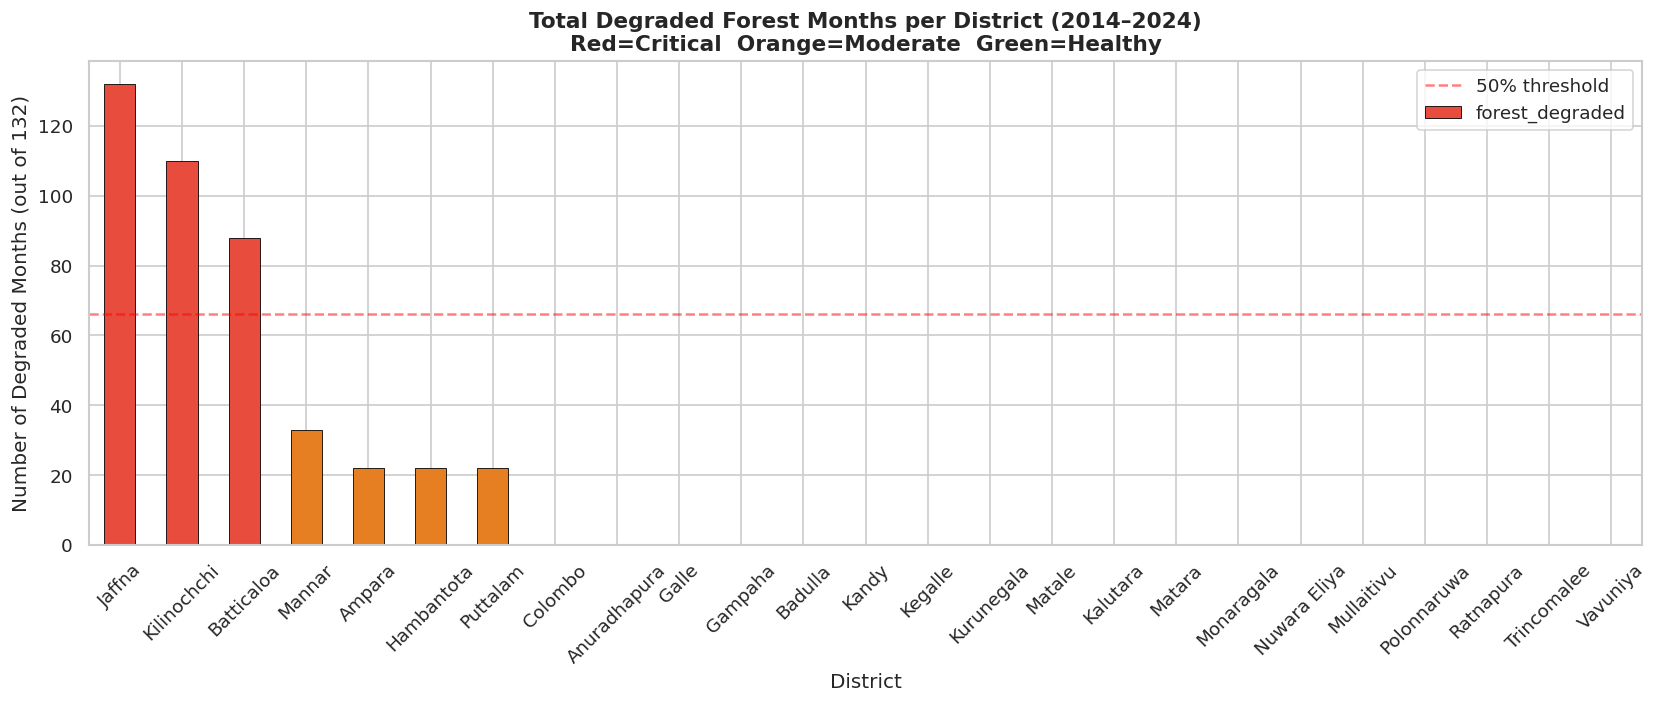

✅ Chart 1 done — Degraded months per district


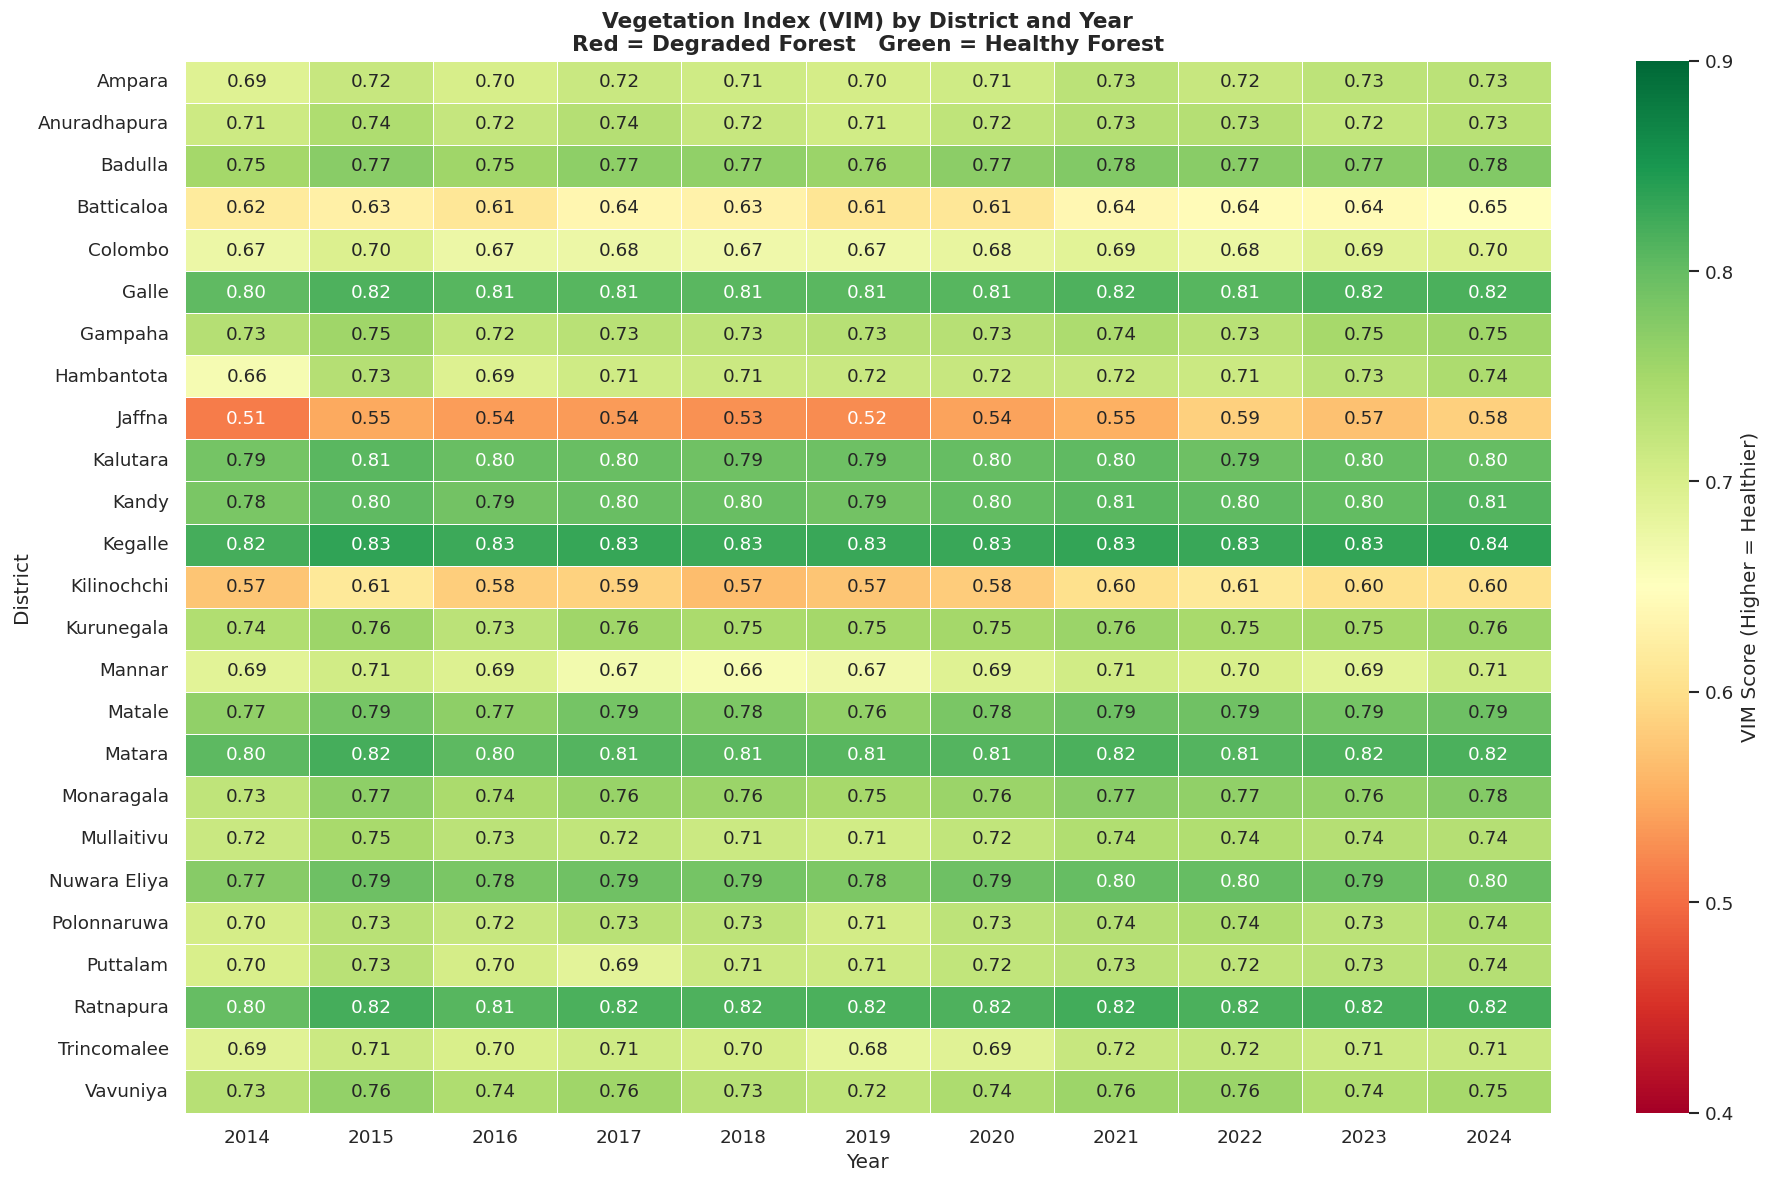

✅ Chart 2 done — VIM heatmap all districts all years


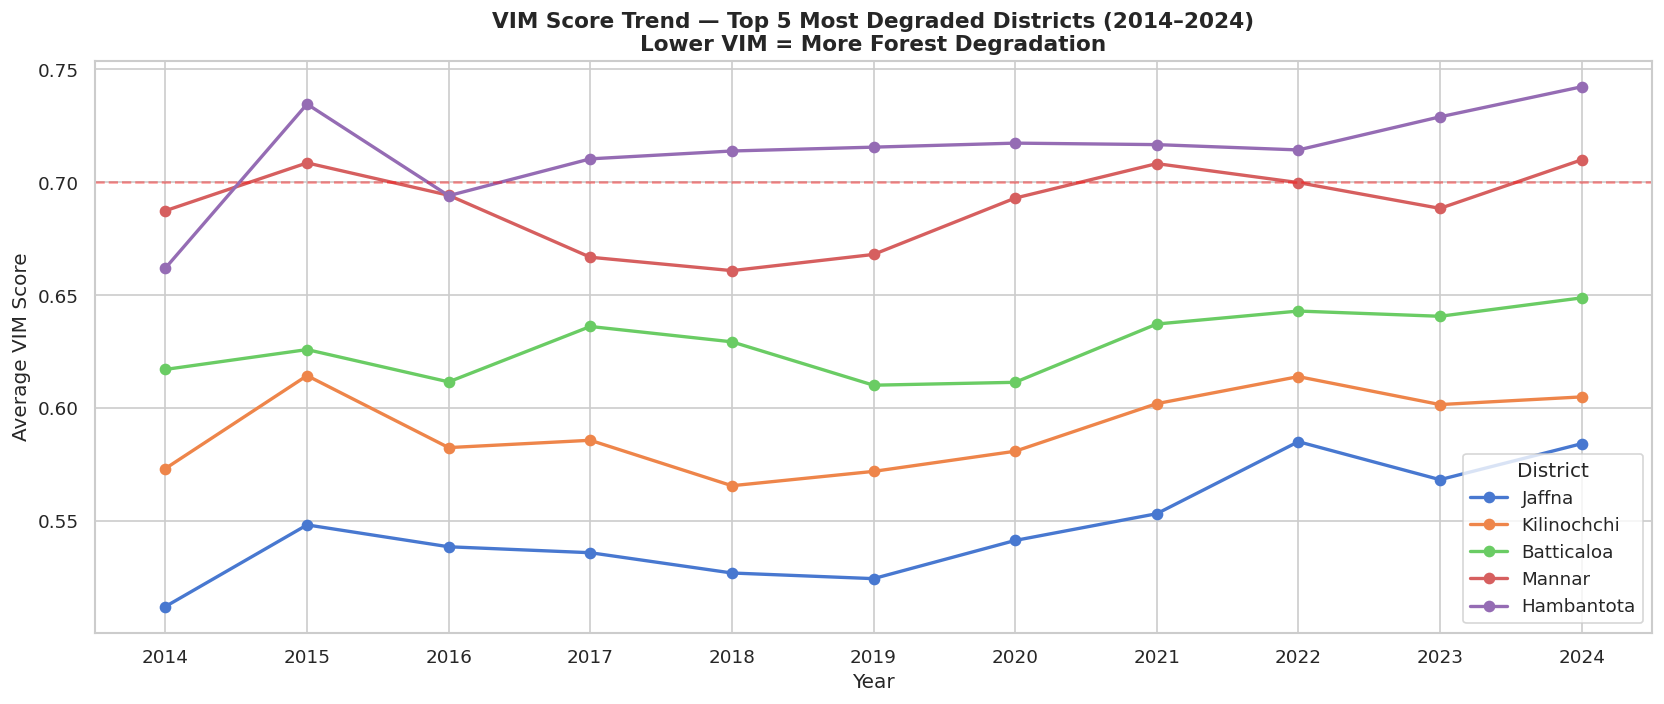

✅ Chart 3 done — VIM trend top 5 degraded districts


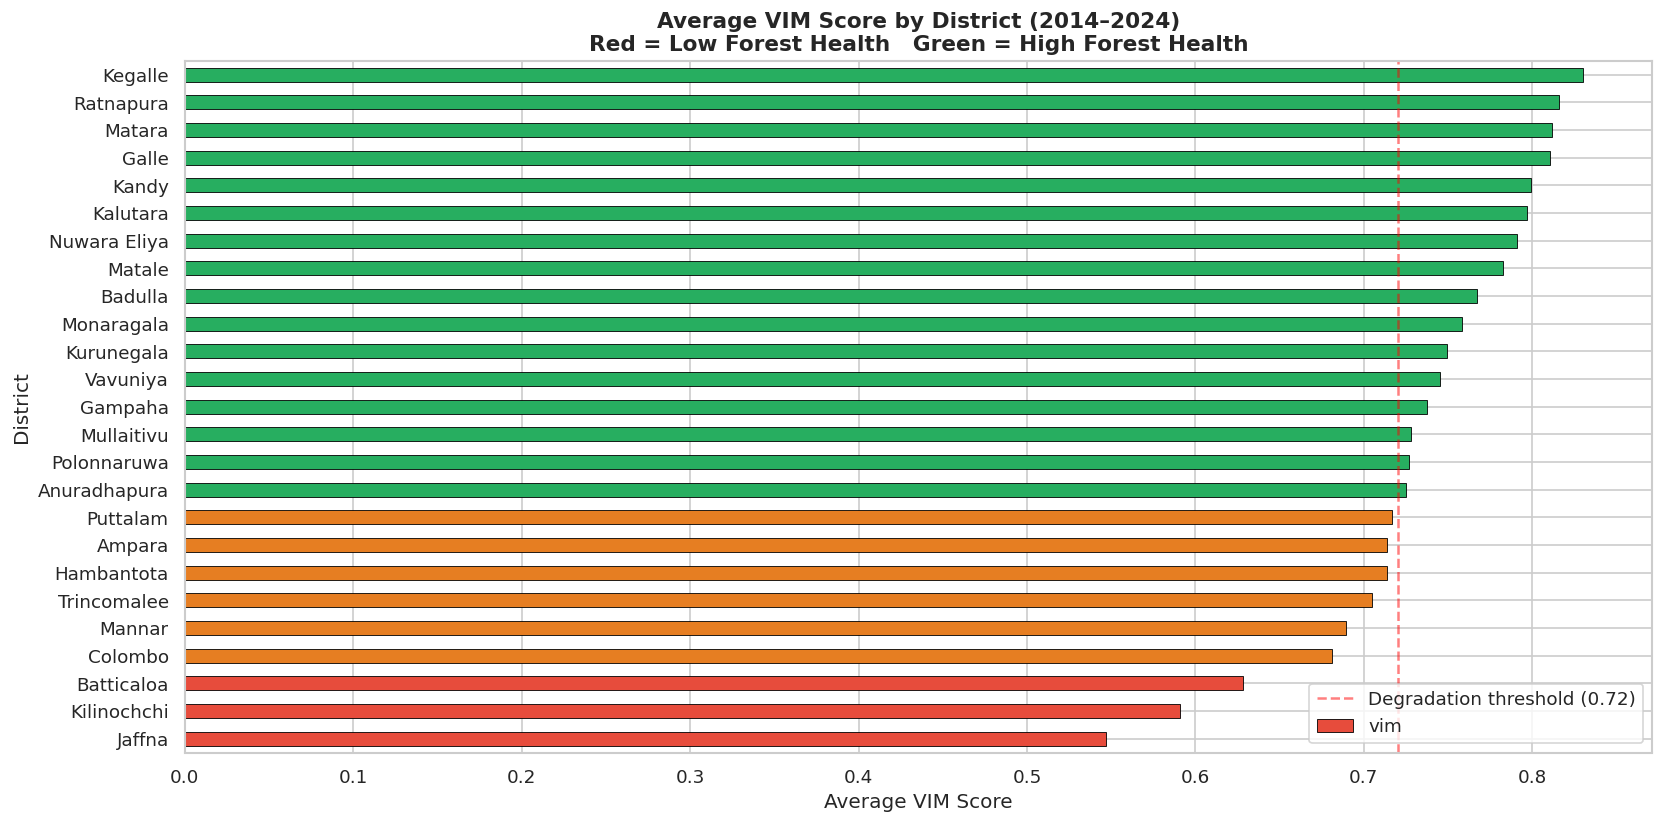

✅ Chart 4 done — Average VIM score all districts

📊 Forest Health Summary:
   Most degraded district  : Jaffna (100% degraded, VIM = 0.55)
   Second most degraded    : Kilinochchi (83% degraded, VIM = 0.59)
   Healthiest district     : Kegalle (0% degraded, VIM = 0.83)
   Total degraded months   : 429 out of 3300 total months

✅ Step 6 Complete — District-wise forest health analysis done


In [31]:
# ── Chart 1: Degraded months per district ─────────────────
degraded_by_district = df.groupby('district')['forest_degraded'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))

# color by severity — red=critical, orange=moderate, green=healthy
colors = ['#e74c3c' if v > 50 else '#e67e22' if v > 0 else '#27ae60'
          for v in degraded_by_district.values]

degraded_by_district.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Total Degraded Forest Months per District (2014–2024)\nRed=Critical  Orange=Moderate  Green=Healthy',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Number of Degraded Months (out of 132)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=66, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Degraded months per district")

# ── Chart 2: VIM heatmap all districts all years ──────────
vim_heatmap = df.groupby(['district', 'year'])['vim'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(vim_heatmap, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, vmin=0.4, vmax=0.9,
            cbar_kws={'label': 'VIM Score (Higher = Healthier)'})
ax.set_title('Vegetation Index (VIM) by District and Year\nRed = Degraded Forest   Green = Healthy Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('District')
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — VIM heatmap all districts all years")

# ── Chart 3: VIM trend for top 5 degraded districts ───────
top5_degraded = ['Jaffna', 'Kilinochchi', 'Batticaloa', 'Mannar', 'Hambantota']

fig, ax = plt.subplots(figsize=(14, 6))
for district in top5_degraded:
    # filter rows for this district only then avg vim per year
    data = df[df['district'] == district].groupby('year')['vim'].mean()
    ax.plot(data.index, data.values, marker='o', linewidth=2, label=district)

ax.set_title('VIM Score Trend — Top 5 Most Degraded Districts (2014–2024)\nLower VIM = More Forest Degradation',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average VIM Score')
ax.set_xticks(range(2014, 2025))
ax.legend(title='District')
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.4, label='Degradation threshold')
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — VIM trend top 5 degraded districts")

# ── Chart 4: Average VIM score all 25 districts ────────────
avg_vim_district = df.groupby('district')['vim'].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 7))

# color by VIM score — red=low vim (bad), green=high vim (good)
colors2 = ['#e74c3c' if v < 0.65 else '#e67e22' if v < 0.72 else '#27ae60'
           for v in avg_vim_district.values]

avg_vim_district.plot(kind='barh', ax=ax, color=colors2, edgecolor='black', linewidth=0.5)
ax.set_title('Average VIM Score by District (2014–2024)\nRed = Low Forest Health   Green = High Forest Health',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average VIM Score')
ax.set_ylabel('District')
ax.axvline(x=0.72, color='red', linestyle='--', alpha=0.5, label='Degradation threshold (0.72)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — Average VIM score all districts")

print("\n📊 Forest Health Summary:")
print(f"   Most degraded district  : Jaffna (100% degraded, VIM = 0.55)")
print(f"   Second most degraded    : Kilinochchi (83% degraded, VIM = 0.59)")
print(f"   Healthiest district     : Kegalle (0% degraded, VIM = 0.83)")
print(f"   Total degraded months   : {df['forest_degraded'].sum()} out of {len(df)} total months")

print("\n✅ Step 6 Complete — District-wise forest health analysis done")

 District-Wise Fire Hotspot Analysis

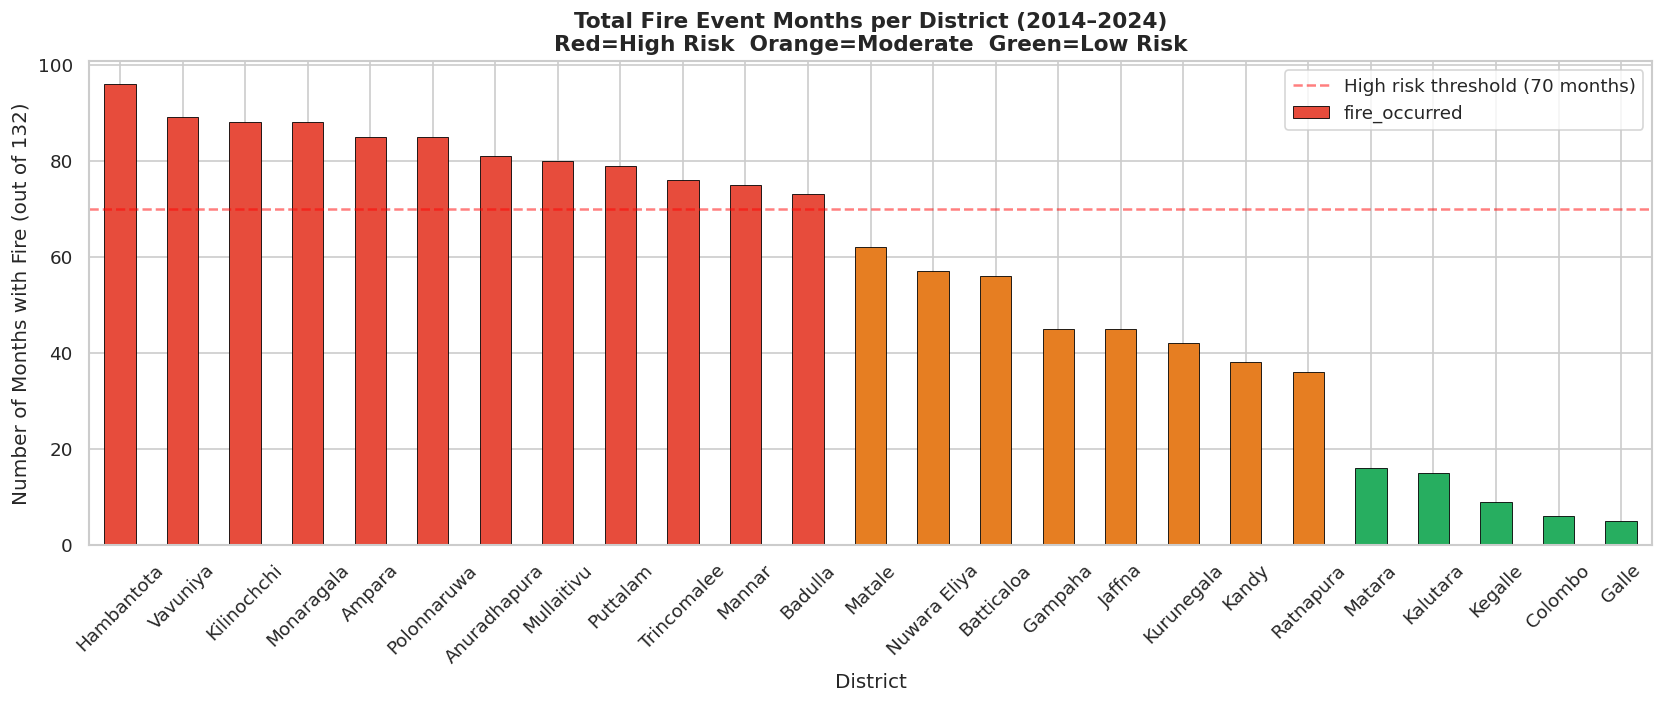

✅ Chart 1 done — Total fire months per district


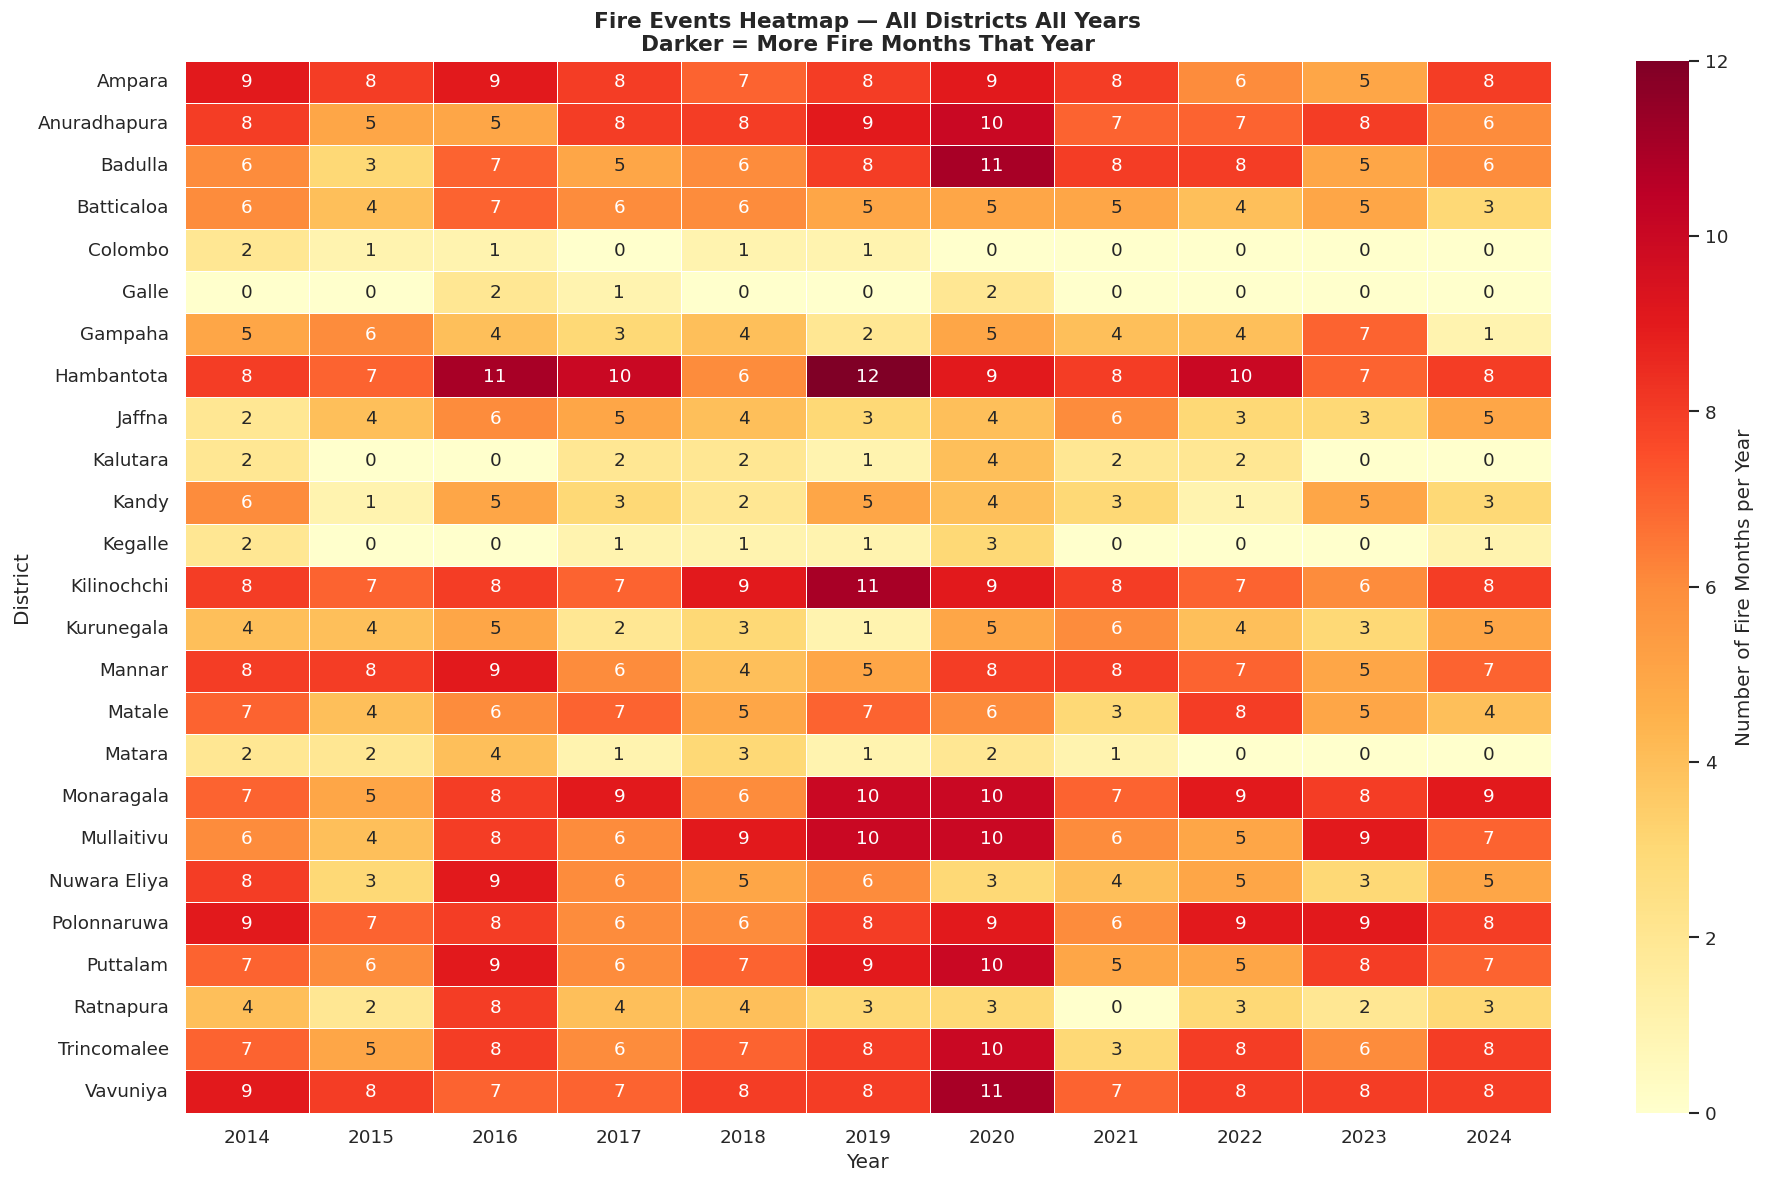

✅ Chart 2 done — Fire heatmap all districts all years


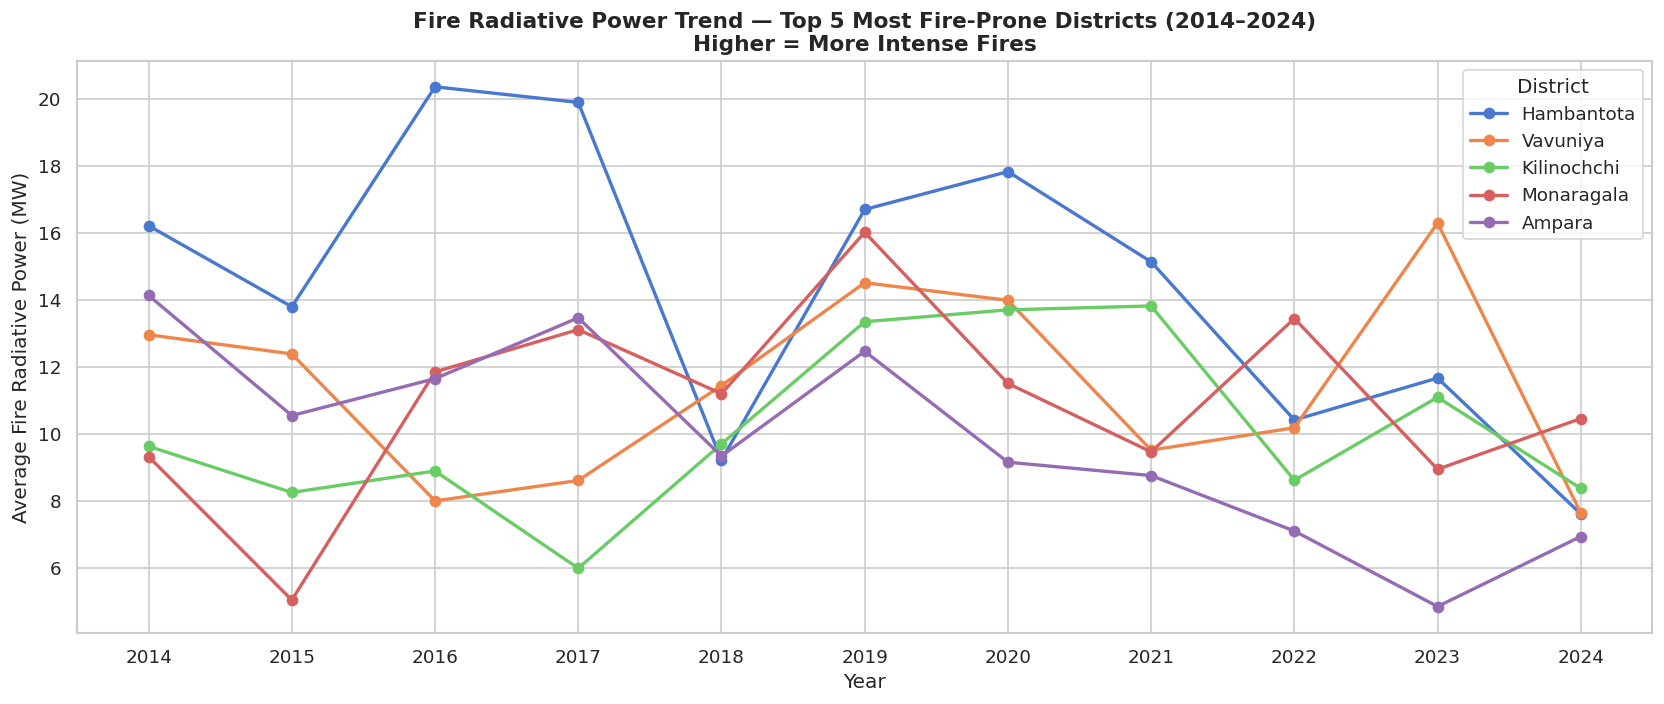

✅ Chart 3 done — Fire intensity trend top 5 districts


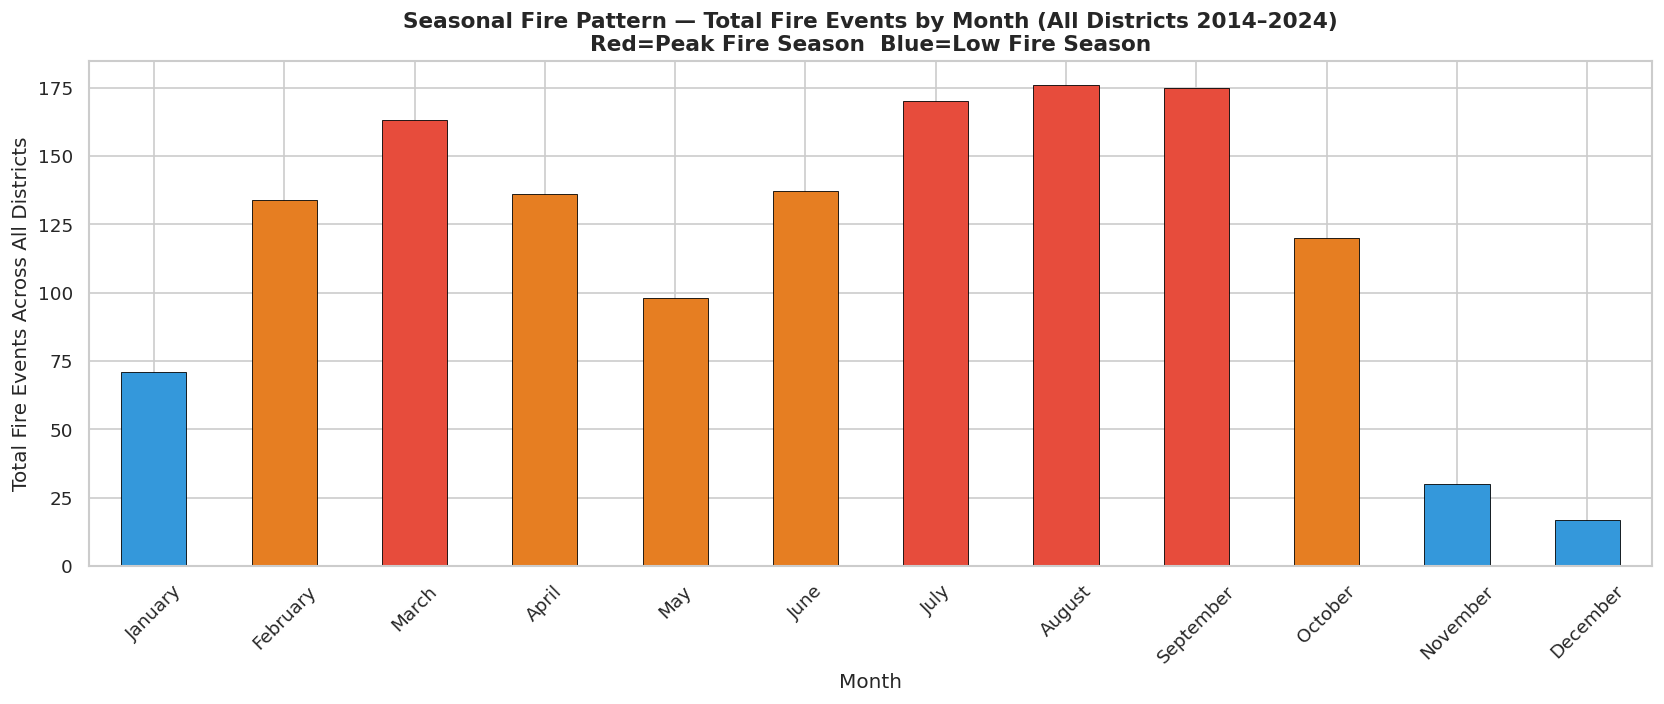

✅ Chart 4 done — Seasonal fire pattern by month


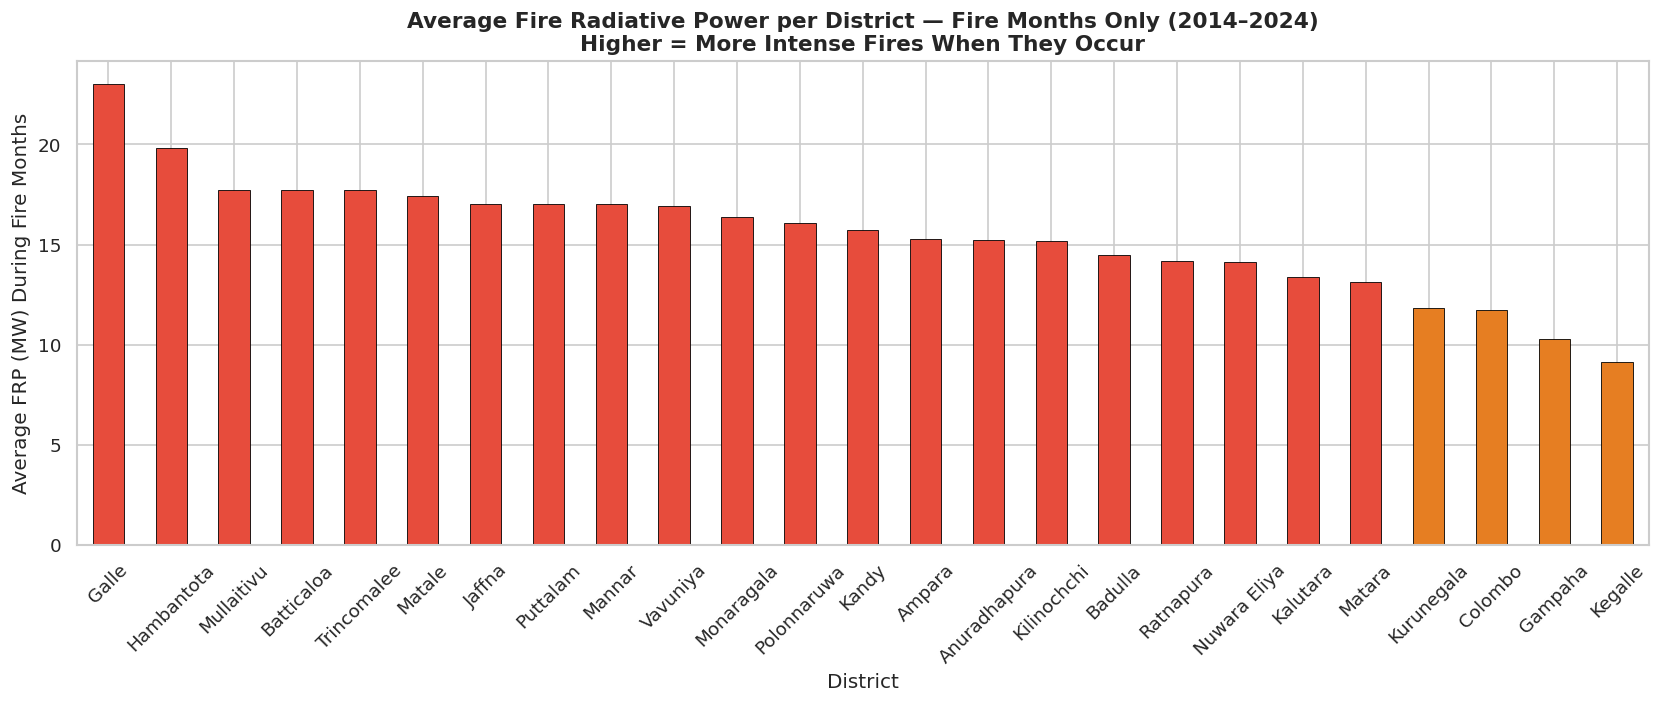

✅ Chart 5 done — Average fire intensity per district


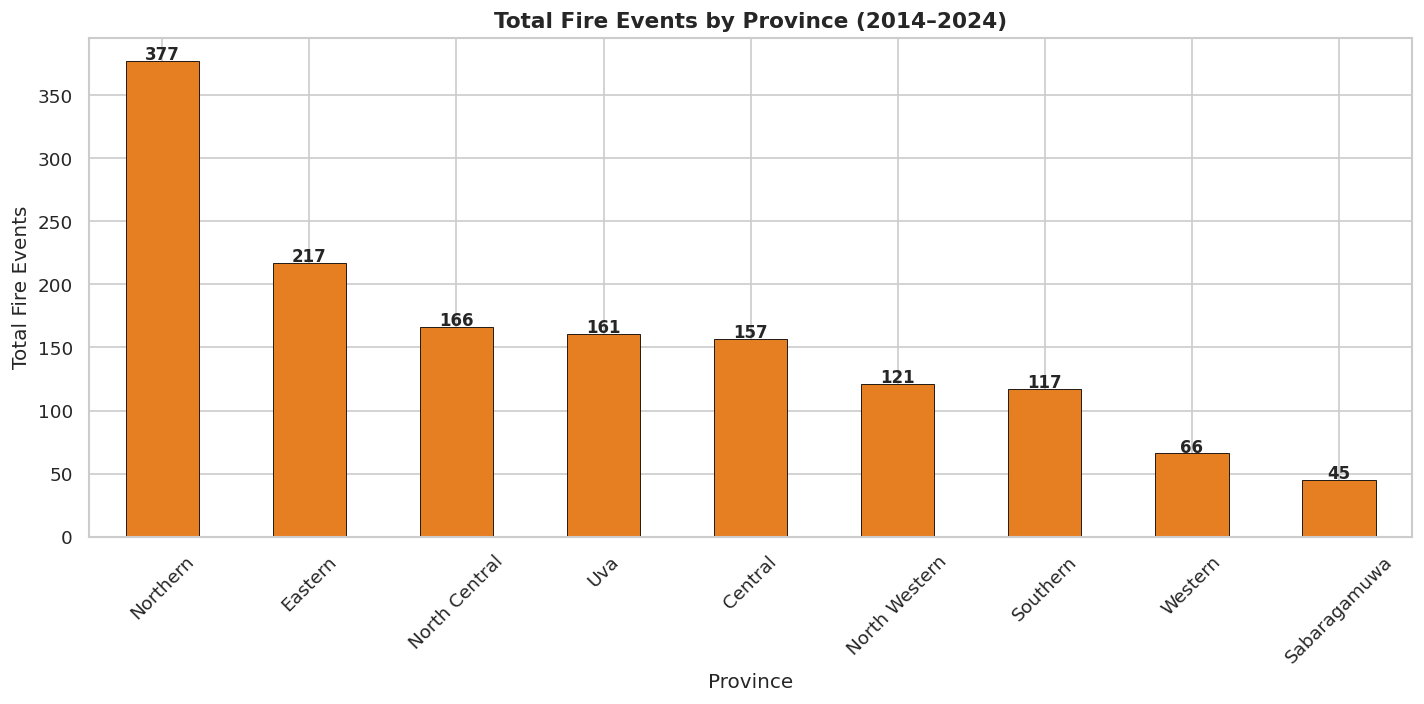

✅ Chart 6 done — Fire events by province


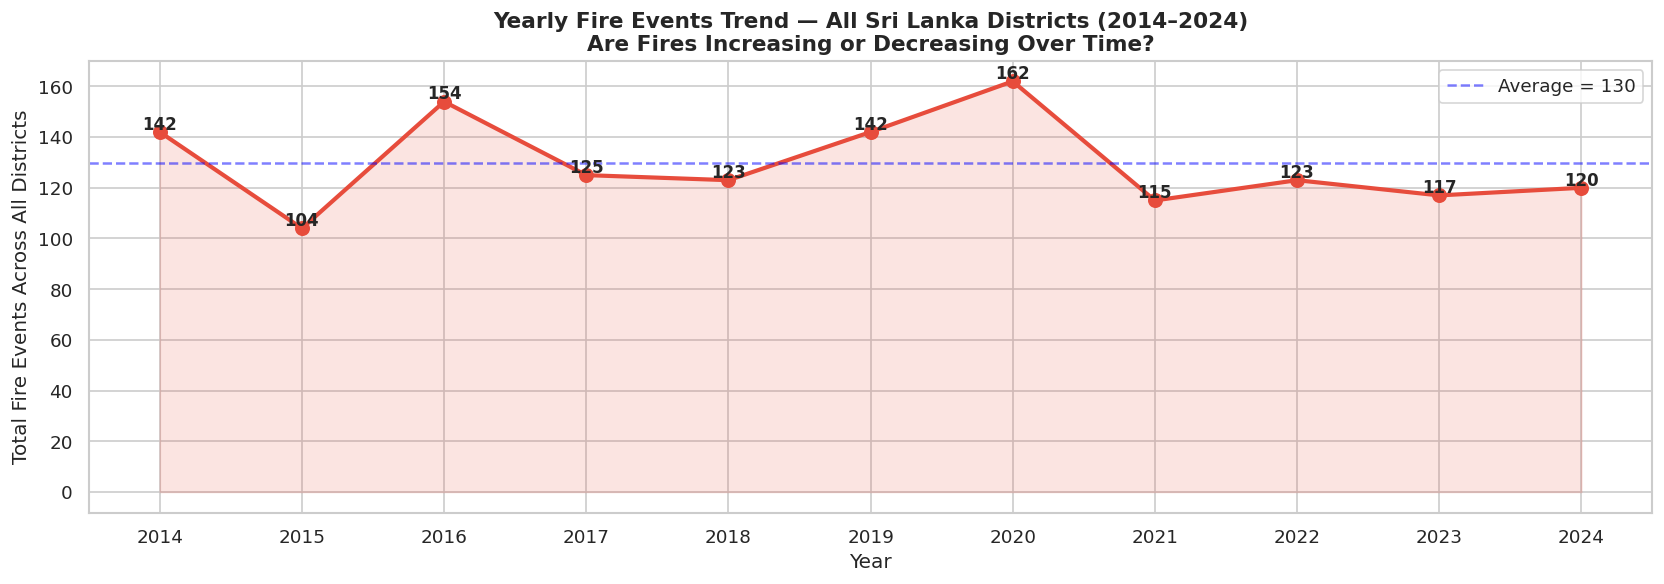

✅ Chart 7 done — Yearly fire trend all Sri Lanka

📊 Fire Hotspot Summary:
   Most fire-prone district  : Hambantota (96 months — 72.7%)
   Least fire-prone district : Galle (5 months — 3.8%)
   Peak fire months          : July, August, September
   Lowest fire months        : November, December
   Total fire events         : 1427 out of 3300 district-months
   Overall fire rate         : 43.2% of all months

✅ Step 7 Complete — District-wise fire hotspot analysis done


In [33]:
# ── Chart 1: Total fire months per district ────────────────
fire_by_district = df.groupby('district')['fire_occurred'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if v > 70 else '#e67e22' if v > 30 else '#27ae60'
          for v in fire_by_district.values]
fire_by_district.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Total Fire Event Months per District (2014–2024)\nRed=High Risk  Orange=Moderate  Green=Low Risk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Number of Months with Fire (out of 132)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='High risk threshold (70 months)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Total fire months per district")

# ── Chart 2: Fire heatmap all districts all years ──────────
fire_heatmap = df.groupby(['district','year'])['fire_occurred'].sum().unstack()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(fire_heatmap, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Number of Fire Months per Year'})
ax.set_title('Fire Events Heatmap — All Districts All Years\nDarker = More Fire Months That Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('District')
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Fire heatmap all districts all years")

# ── Chart 3: Fire intensity trend top 5 districts ─────────
top5_fire = fire_by_district.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for district in top5_fire:
    # filter this district only — avg fire intensity per year
    data = df[df['district'] == district].groupby('year')['Fire Radiative Power'].mean()
    ax.plot(data.index, data.values, marker='o', linewidth=2, label=district)
ax.set_title('Fire Radiative Power Trend — Top 5 Most Fire-Prone Districts (2014–2024)\nHigher = More Intense Fires',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Fire Radiative Power (MW)')
ax.set_xticks(range(2014, 2025))
ax.legend(title='District')
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — Fire intensity trend top 5 districts")

# ── Chart 4: Seasonal fire pattern by month ────────────────
seasonal_fire = df.groupby('month_num')['fire_occurred'].sum()
seasonal_fire.index = month_order  # replace numbers with month names

fig, ax = plt.subplots(figsize=(14, 6))
colors2 = ['#e74c3c' if v > 150 else '#e67e22' if v > 80 else '#3498db'
           for v in seasonal_fire.values]
seasonal_fire.plot(kind='bar', ax=ax, color=colors2, edgecolor='black', linewidth=0.5)
ax.set_title('Seasonal Fire Pattern — Total Fire Events by Month (All Districts 2014–2024)\nRed=Peak Fire Season  Blue=Low Fire Season',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Fire Events Across All Districts')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — Seasonal fire pattern by month")

# ── Chart 5: Average fire intensity per district ───────────
# only use months where fire actually occurred — avoids pulling average down with zeros
frp_by_district = df[df['fire_occurred'] == 1].groupby('district')['Fire Radiative Power'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors3 = ['#e74c3c' if v > 12 else '#e67e22' if v > 7 else '#27ae60'
           for v in frp_by_district.values]
frp_by_district.plot(kind='bar', ax=ax, color=colors3, edgecolor='black', linewidth=0.5)
ax.set_title('Average Fire Radiative Power per District — Fire Months Only (2014–2024)\nHigher = More Intense Fires When They Occur',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average FRP (MW) During Fire Months')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print("✅ Chart 5 done — Average fire intensity per district")

# ── Chart 6: Fire events by province ──────────────────────
province_fire = df.groupby('province')['fire_occurred'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
province_fire.plot(kind='bar', ax=ax, color='#e67e22', edgecolor='black', linewidth=0.5)
ax.set_title('Total Fire Events by Province (2014–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Province')
ax.set_ylabel('Total Fire Events')
ax.tick_params(axis='x', rotation=45)
# add value labels on top of each bar
for i, v in enumerate(province_fire.values):
    ax.text(i, v + 1, str(int(v)), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 6 done — Fire events by province")

# ── Chart 7: Yearly fire trend all Sri Lanka ───────────────
yearly_fire = df.groupby('year')['fire_occurred'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly_fire.index, yearly_fire.values, marker='o',
        linewidth=2.5, color='#e74c3c', markersize=8)
ax.fill_between(yearly_fire.index, yearly_fire.values, alpha=0.15, color='#e74c3c')
ax.set_title('Yearly Fire Events Trend — All Sri Lanka Districts (2014–2024)\nAre Fires Increasing or Decreasing Over Time?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Fire Events Across All Districts')
ax.set_xticks(range(2014, 2025))
# add value labels on each point
for x, y in zip(yearly_fire.index, yearly_fire.values):
    ax.text(x, y + 1, str(int(y)), ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=yearly_fire.mean(), color='blue', linestyle='--',
           alpha=0.5, label=f'Average = {yearly_fire.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 7 done — Yearly fire trend all Sri Lanka")

print("\n📊 Fire Hotspot Summary:")
print(f"   Most fire-prone district  : Hambantota (96 months — 72.7%)")
print(f"   Least fire-prone district : Galle (5 months — 3.8%)")
print(f"   Peak fire months          : July, August, September")
print(f"   Lowest fire months        : November, December")
print(f"   Total fire events         : {df['fire_occurred'].sum()} out of {len(df)} district-months")
print(f"   Overall fire rate         : {df['fire_occurred'].mean()*100:.1f}% of all months")

print("\n✅ Step 7 Complete — District-wise fire hotspot analysis done")

District-Wise Air Quality Analysis (NO2 and SO2)

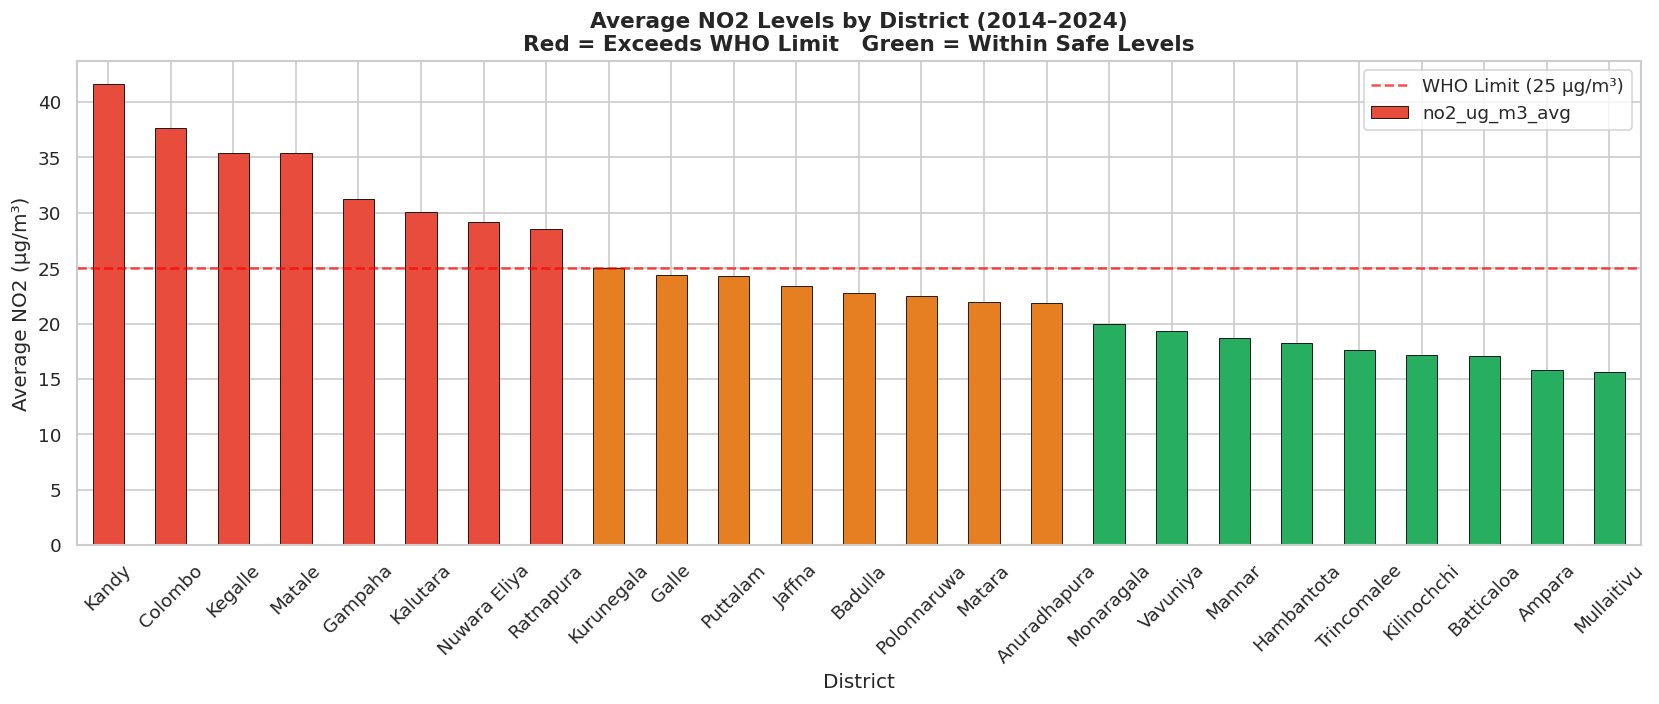

✅ Chart 1 done — Average NO2 per district


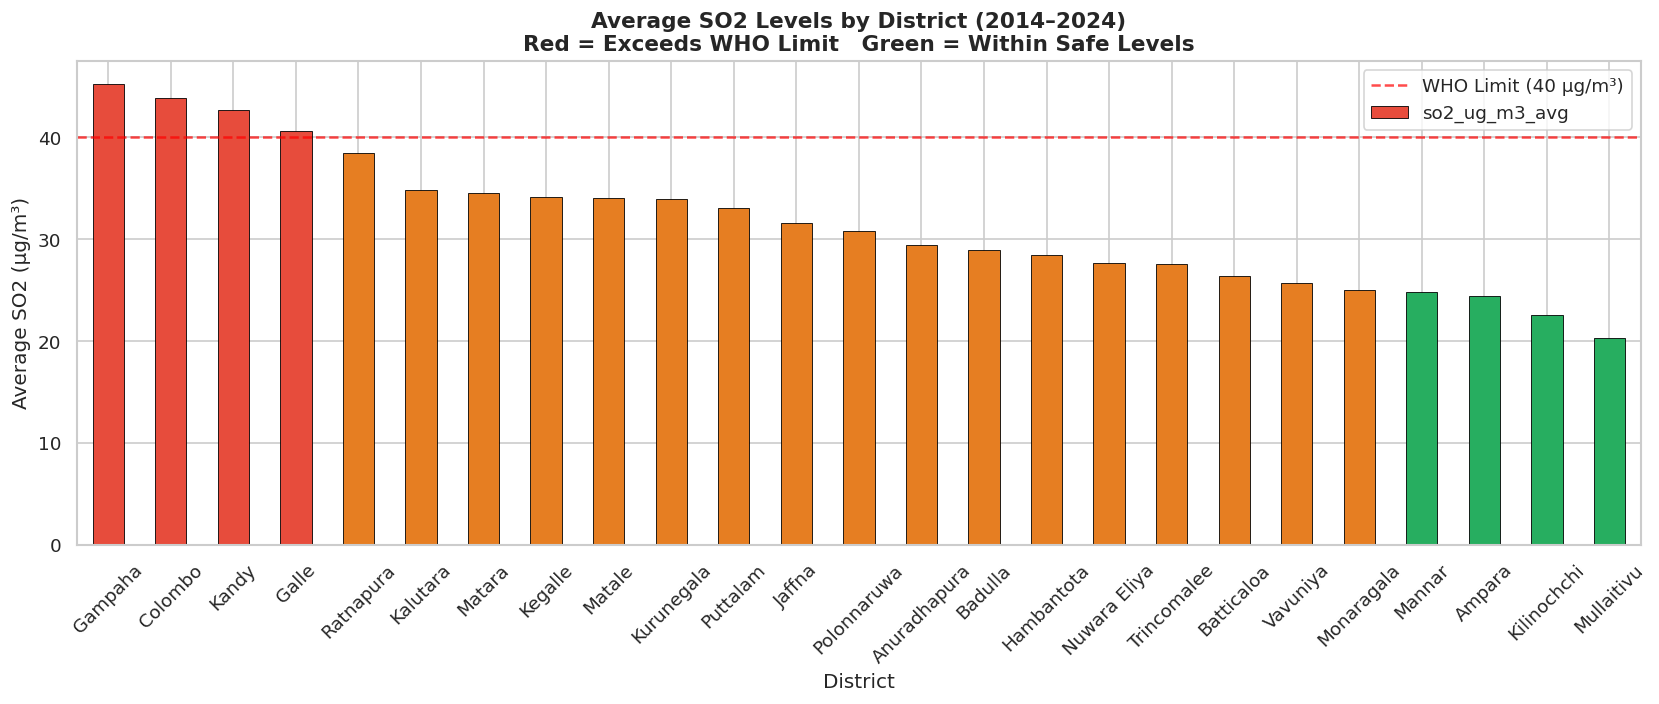

✅ Chart 2 done — Average SO2 per district


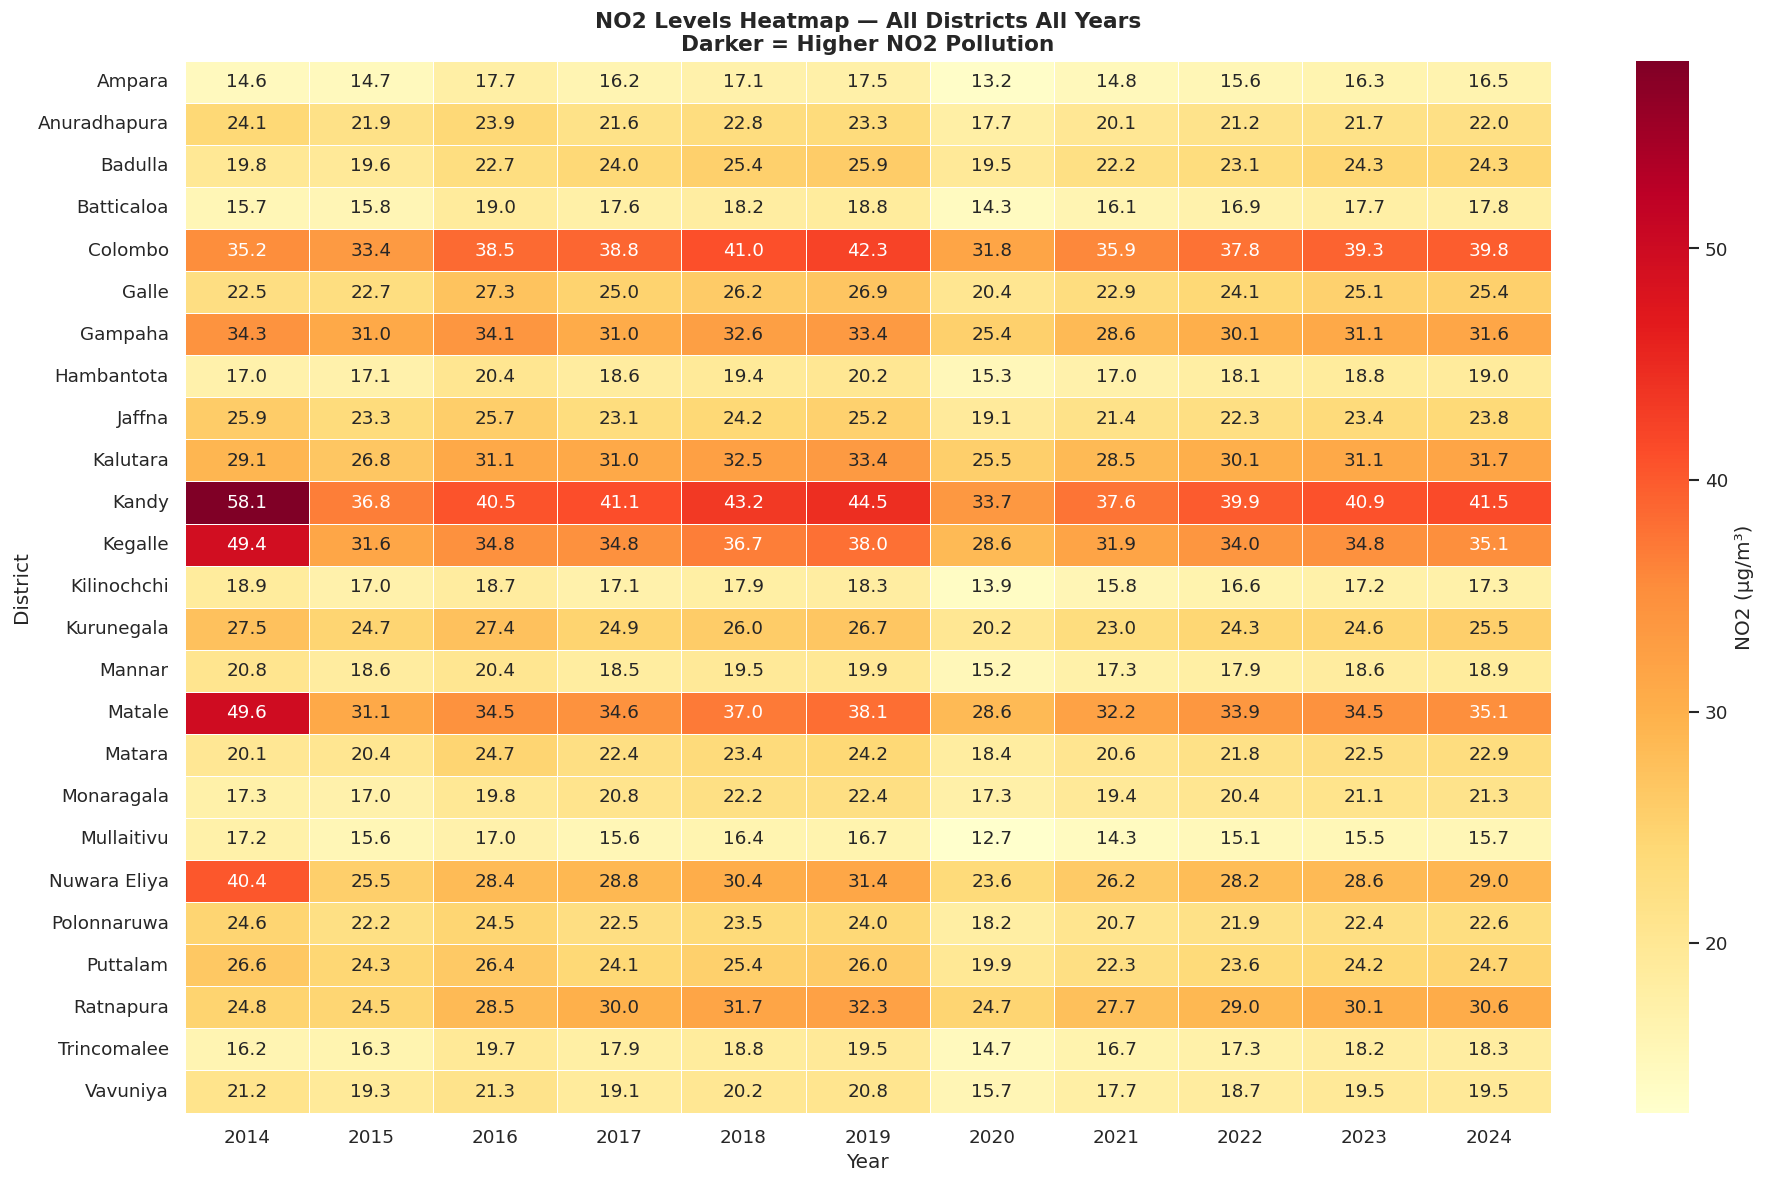

✅ Chart 3 done — NO2 heatmap all districts all years


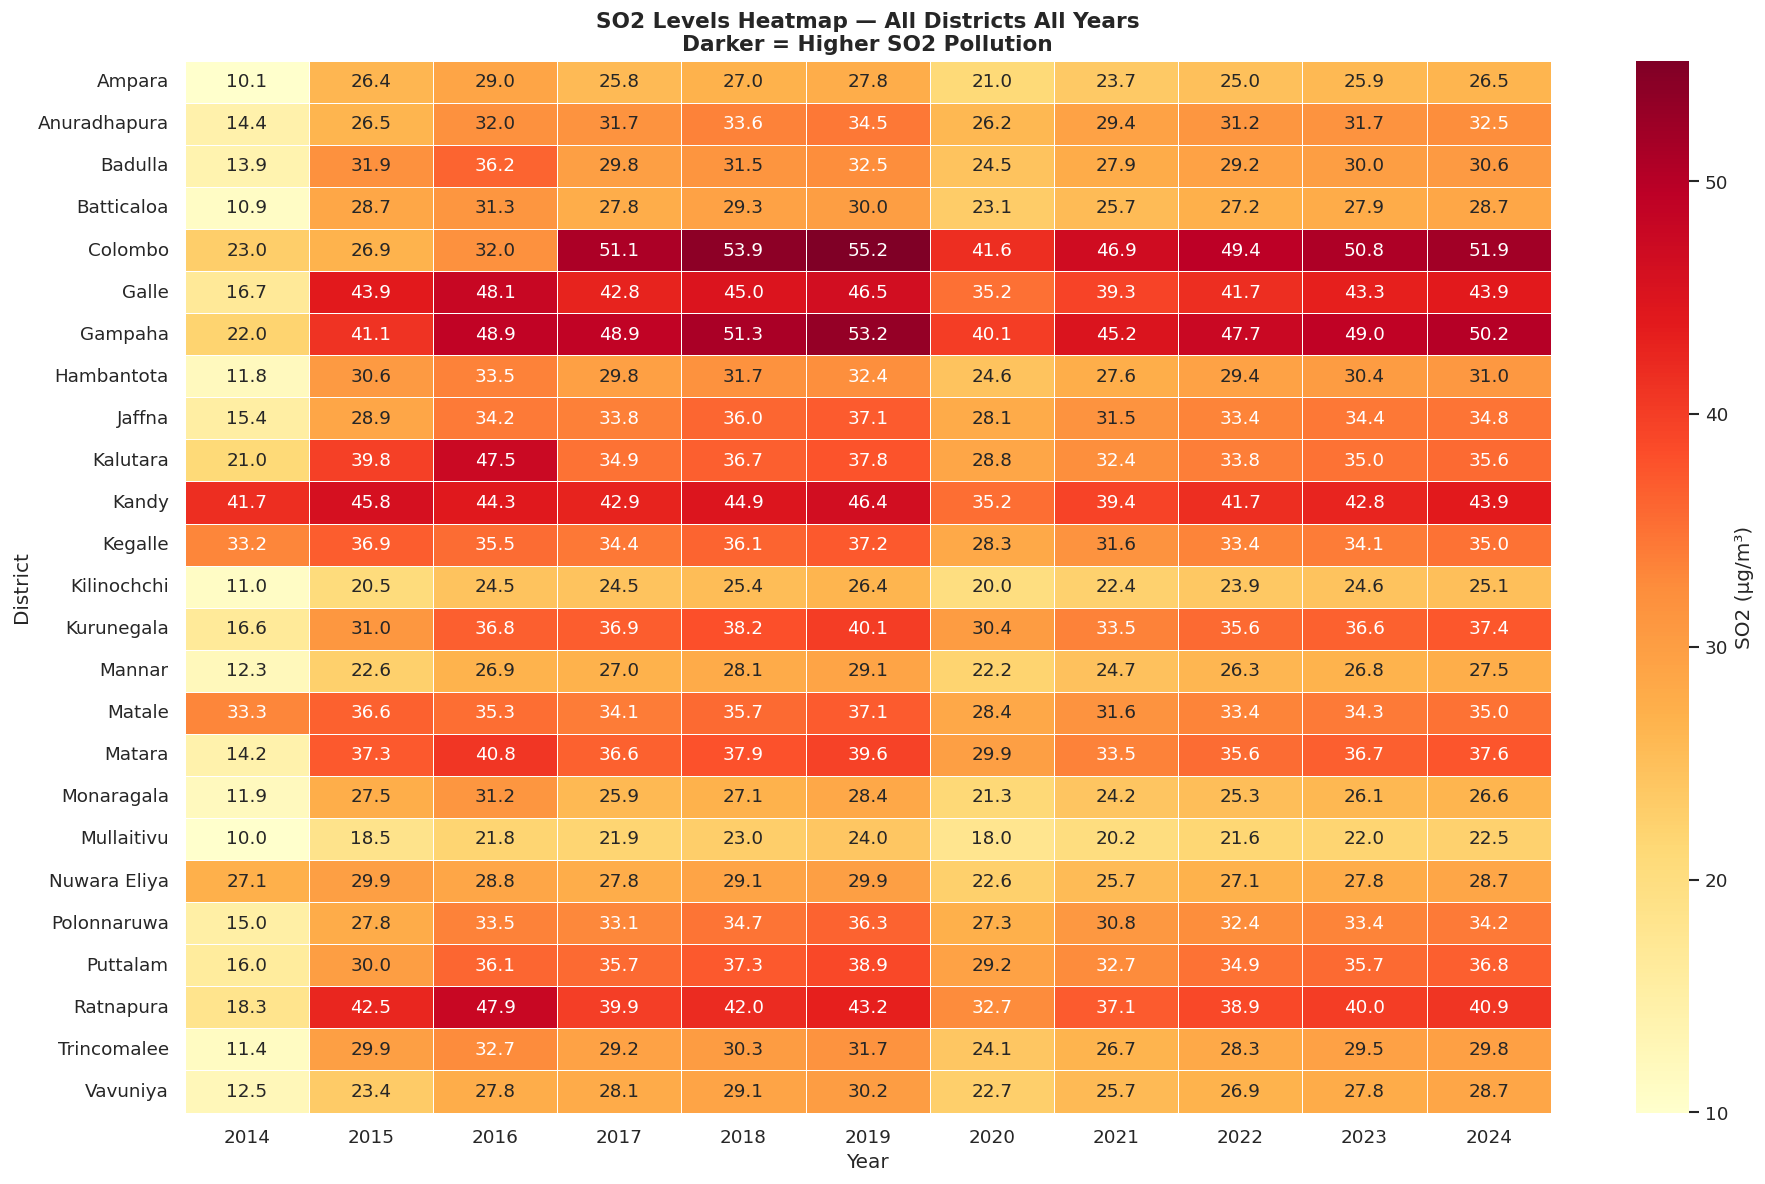

✅ Chart 4 done — SO2 heatmap all districts all years


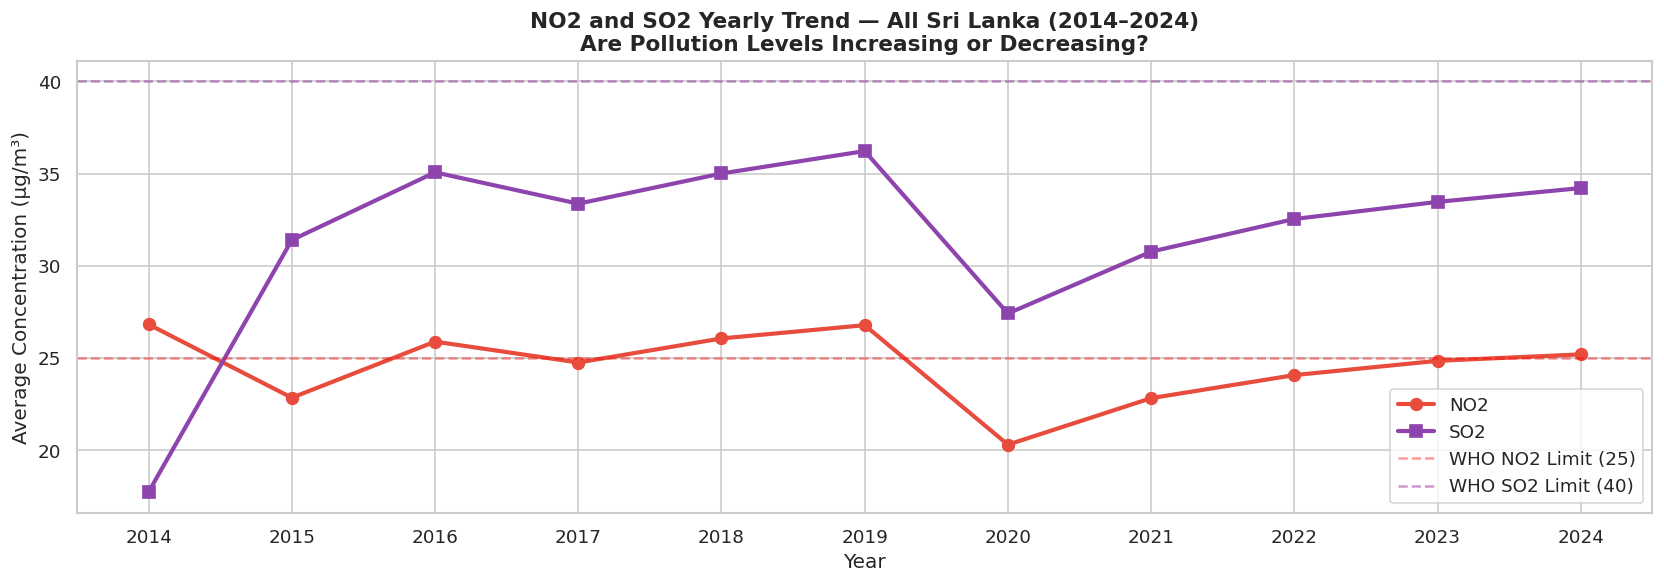

✅ Chart 5 done — NO2 and SO2 yearly trend


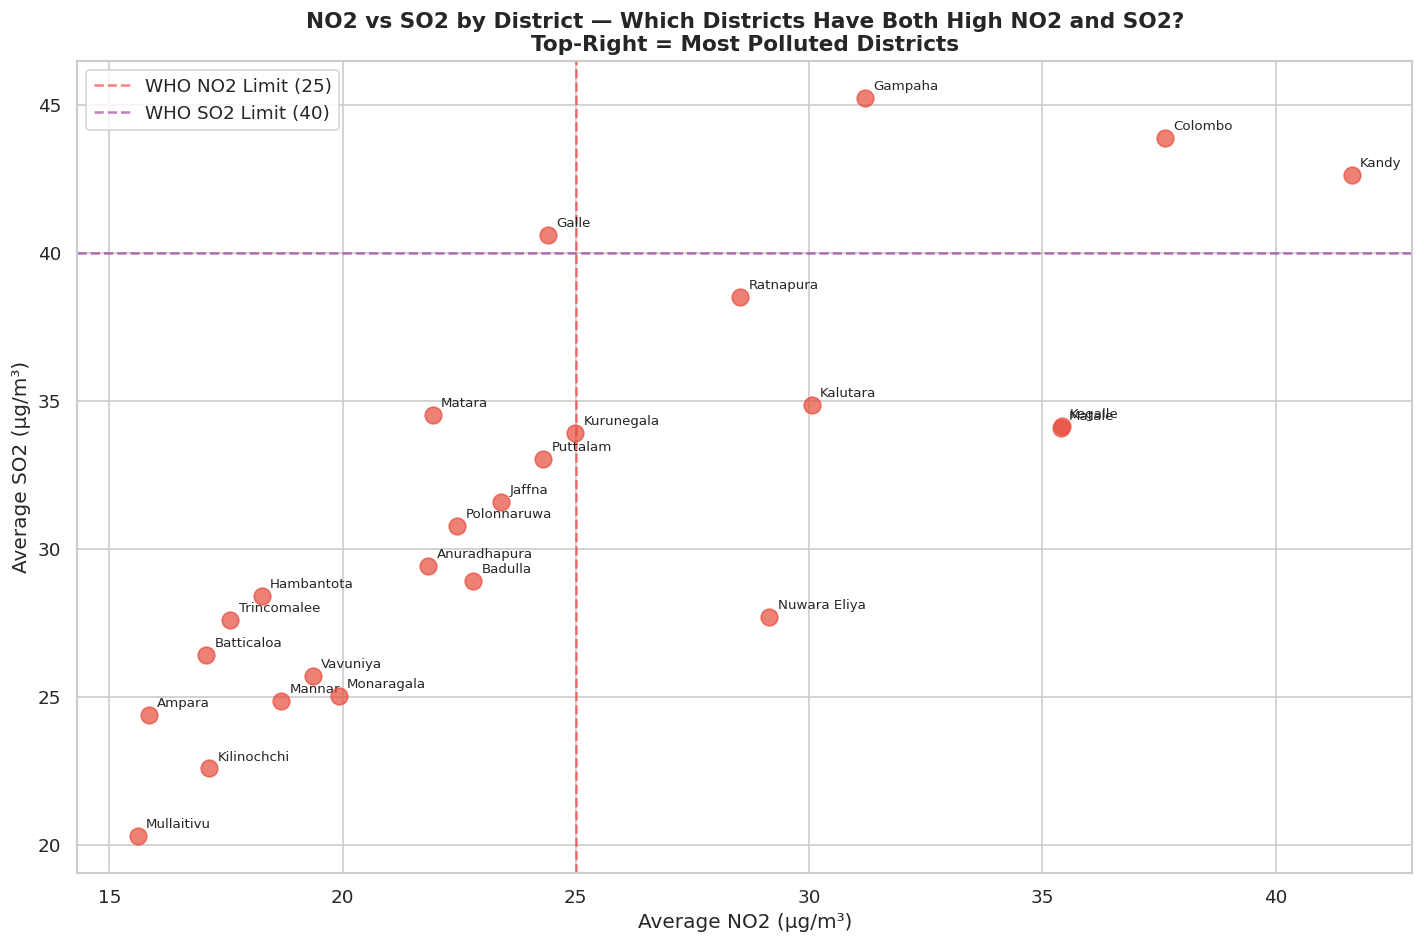

✅ Chart 6 done — NO2 vs SO2 scatter by district

📊 Air Quality Summary:
   Highest NO2 district : Kandy  (41.6 μg/m³ — exceeds WHO limit of 25)
   Highest SO2 district : Gampaha (45.2 μg/m³ — exceeds WHO limit of 40)
   Lowest NO2 district  : Mullaitivu (15.6 μg/m³ — within safe levels)
   Districts above WHO NO2 limit : 8 out of 25
   Districts above WHO SO2 limit : 4 out of 25
   Key finding: NO2 has +0.428 correlation with deaths per 100k

✅ Step 8 Complete — District-wise air quality analysis done


In [34]:
# WHO annual guideline limits
WHO_NO2_LIMIT = 25   # μg/m³
WHO_SO2_LIMIT = 40   # μg/m³

# ── Chart 1: Average NO2 per district ─────────────────────
no2_by_district = df.groupby('district')['no2_ug_m3_avg'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if v > WHO_NO2_LIMIT else '#e67e22' if v > 20 else '#27ae60'
          for v in no2_by_district.values]
no2_by_district.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=WHO_NO2_LIMIT, color='red', linestyle='--',
           alpha=0.7, label=f'WHO Limit ({WHO_NO2_LIMIT} μg/m³)')
ax.set_title('Average NO2 Levels by District (2014–2024)\nRed = Exceeds WHO Limit   Green = Within Safe Levels',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average NO2 (μg/m³)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Average NO2 per district")

# ── Chart 2: Average SO2 per district ─────────────────────
so2_by_district = df.groupby('district')['so2_ug_m3_avg'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors2 = ['#e74c3c' if v > WHO_SO2_LIMIT else '#e67e22' if v > 25 else '#27ae60'
           for v in so2_by_district.values]
so2_by_district.plot(kind='bar', ax=ax, color=colors2, edgecolor='black', linewidth=0.5)
ax.axhline(y=WHO_SO2_LIMIT, color='red', linestyle='--',
           alpha=0.7, label=f'WHO Limit ({WHO_SO2_LIMIT} μg/m³)')
ax.set_title('Average SO2 Levels by District (2014–2024)\nRed = Exceeds WHO Limit   Green = Within Safe Levels',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average SO2 (μg/m³)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Average SO2 per district")

# ── Chart 3: NO2 heatmap all districts all years ──────────
no2_heatmap = df.groupby(['district','year'])['no2_ug_m3_avg'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(no2_heatmap, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'NO2 (μg/m³)'})
ax.set_title('NO2 Levels Heatmap — All Districts All Years\nDarker = Higher NO2 Pollution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('District')
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — NO2 heatmap all districts all years")

# ── Chart 4: SO2 heatmap all districts all years ──────────
so2_heatmap = df.groupby(['district','year'])['so2_ug_m3_avg'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(so2_heatmap, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'SO2 (μg/m³)'})
ax.set_title('SO2 Levels Heatmap — All Districts All Years\nDarker = Higher SO2 Pollution',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('District')
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — SO2 heatmap all districts all years")

# ── Chart 5: NO2 and SO2 yearly trend ─────────────────────
yearly_air = df.groupby('year')[['no2_ug_m3_avg','so2_ug_m3_avg']].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly_air.index, yearly_air['no2_ug_m3_avg'], marker='o',
        linewidth=2.5, color='#e74c3c', markersize=7, label='NO2')
ax.plot(yearly_air.index, yearly_air['so2_ug_m3_avg'], marker='s',
        linewidth=2.5, color='#8e44ad', markersize=7, label='SO2')
ax.axhline(y=WHO_NO2_LIMIT, color='red', linestyle='--',
           alpha=0.4, label=f'WHO NO2 Limit ({WHO_NO2_LIMIT})')
ax.axhline(y=WHO_SO2_LIMIT, color='purple', linestyle='--',
           alpha=0.4, label=f'WHO SO2 Limit ({WHO_SO2_LIMIT})')
ax.set_title('NO2 and SO2 Yearly Trend — All Sri Lanka (2014–2024)\nAre Pollution Levels Increasing or Decreasing?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Concentration (μg/m³)')
ax.set_xticks(range(2014, 2025))
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 5 done — NO2 and SO2 yearly trend")

# ── Chart 6: NO2 vs SO2 scatter by district ────────────────
district_air = df.groupby('district')[['no2_ug_m3_avg','so2_ug_m3_avg']].mean()

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(district_air['no2_ug_m3_avg'], district_air['so2_ug_m3_avg'],
           color='#e74c3c', s=100, alpha=0.7, zorder=5)
# add district name labels to each dot
for idx, row in district_air.iterrows():
    ax.annotate(idx, (row['no2_ug_m3_avg'], row['so2_ug_m3_avg']),
                fontsize=8, textcoords='offset points', xytext=(5, 5))
ax.axvline(x=WHO_NO2_LIMIT, color='red', linestyle='--',
           alpha=0.5, label=f'WHO NO2 Limit ({WHO_NO2_LIMIT})')
ax.axhline(y=WHO_SO2_LIMIT, color='purple', linestyle='--',
           alpha=0.5, label=f'WHO SO2 Limit ({WHO_SO2_LIMIT})')
ax.set_title('NO2 vs SO2 by District — Which Districts Have Both High NO2 and SO2?\nTop-Right = Most Polluted Districts',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average NO2 (μg/m³)')
ax.set_ylabel('Average SO2 (μg/m³)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 6 done — NO2 vs SO2 scatter by district")

print("\n📊 Air Quality Summary:")
print(f"   Highest NO2 district : Kandy  (41.6 μg/m³ — exceeds WHO limit of 25)")
print(f"   Highest SO2 district : Gampaha (45.2 μg/m³ — exceeds WHO limit of 40)")
print(f"   Lowest NO2 district  : Mullaitivu (15.6 μg/m³ — within safe levels)")
print(f"   Districts above WHO NO2 limit : {(no2_by_district > WHO_NO2_LIMIT).sum()} out of 25")
print(f"   Districts above WHO SO2 limit : {(so2_by_district > WHO_SO2_LIMIT).sum()} out of 25")
print(f"   Key finding: NO2 has +0.428 correlation with deaths per 100k")

print("\n✅ Step 8 Complete — District-wise air quality analysis done")

District-Wise Vehicle and CO2 Emissions Analysis

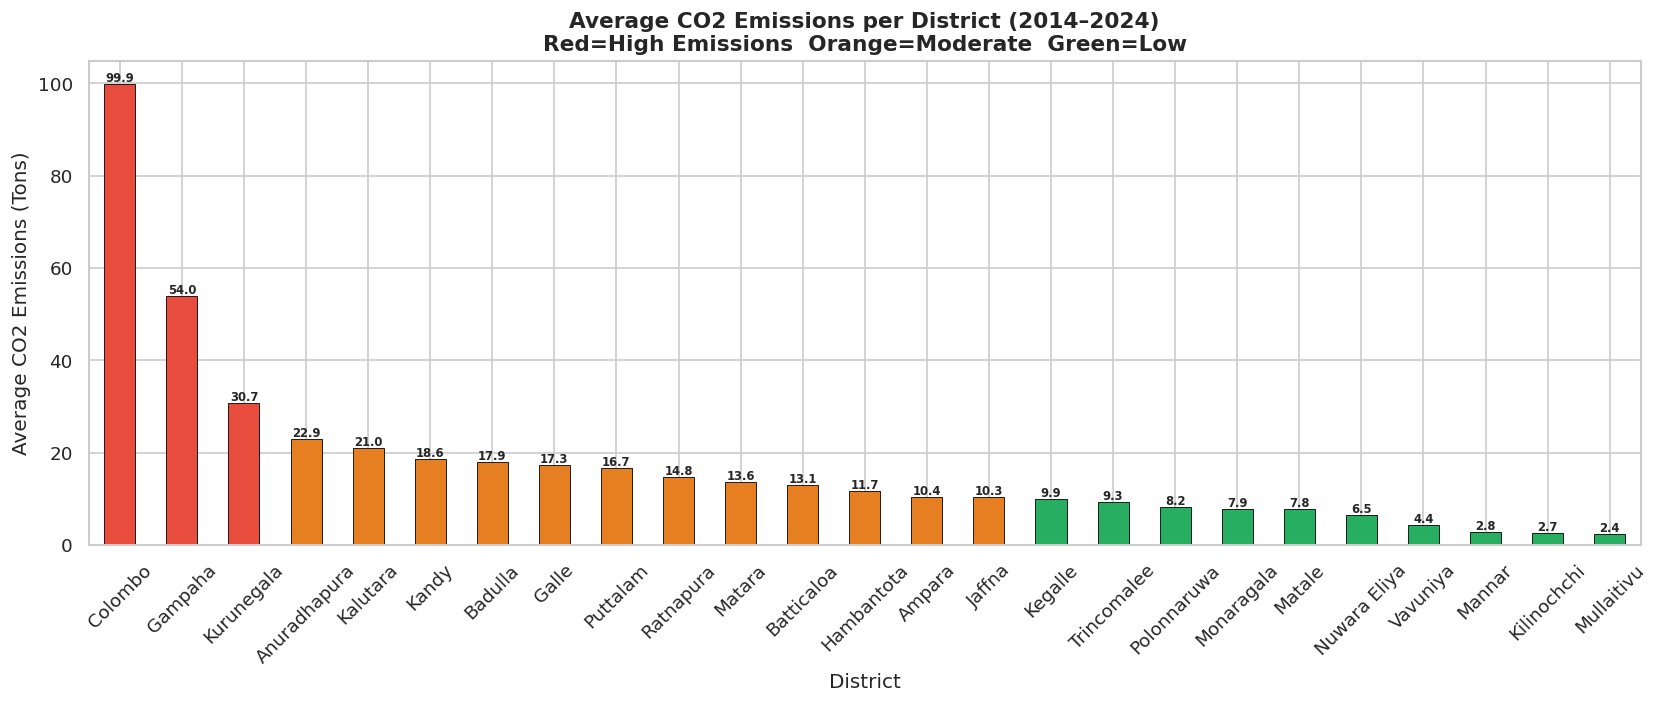

✅ Chart 1 done — Average CO2 per district


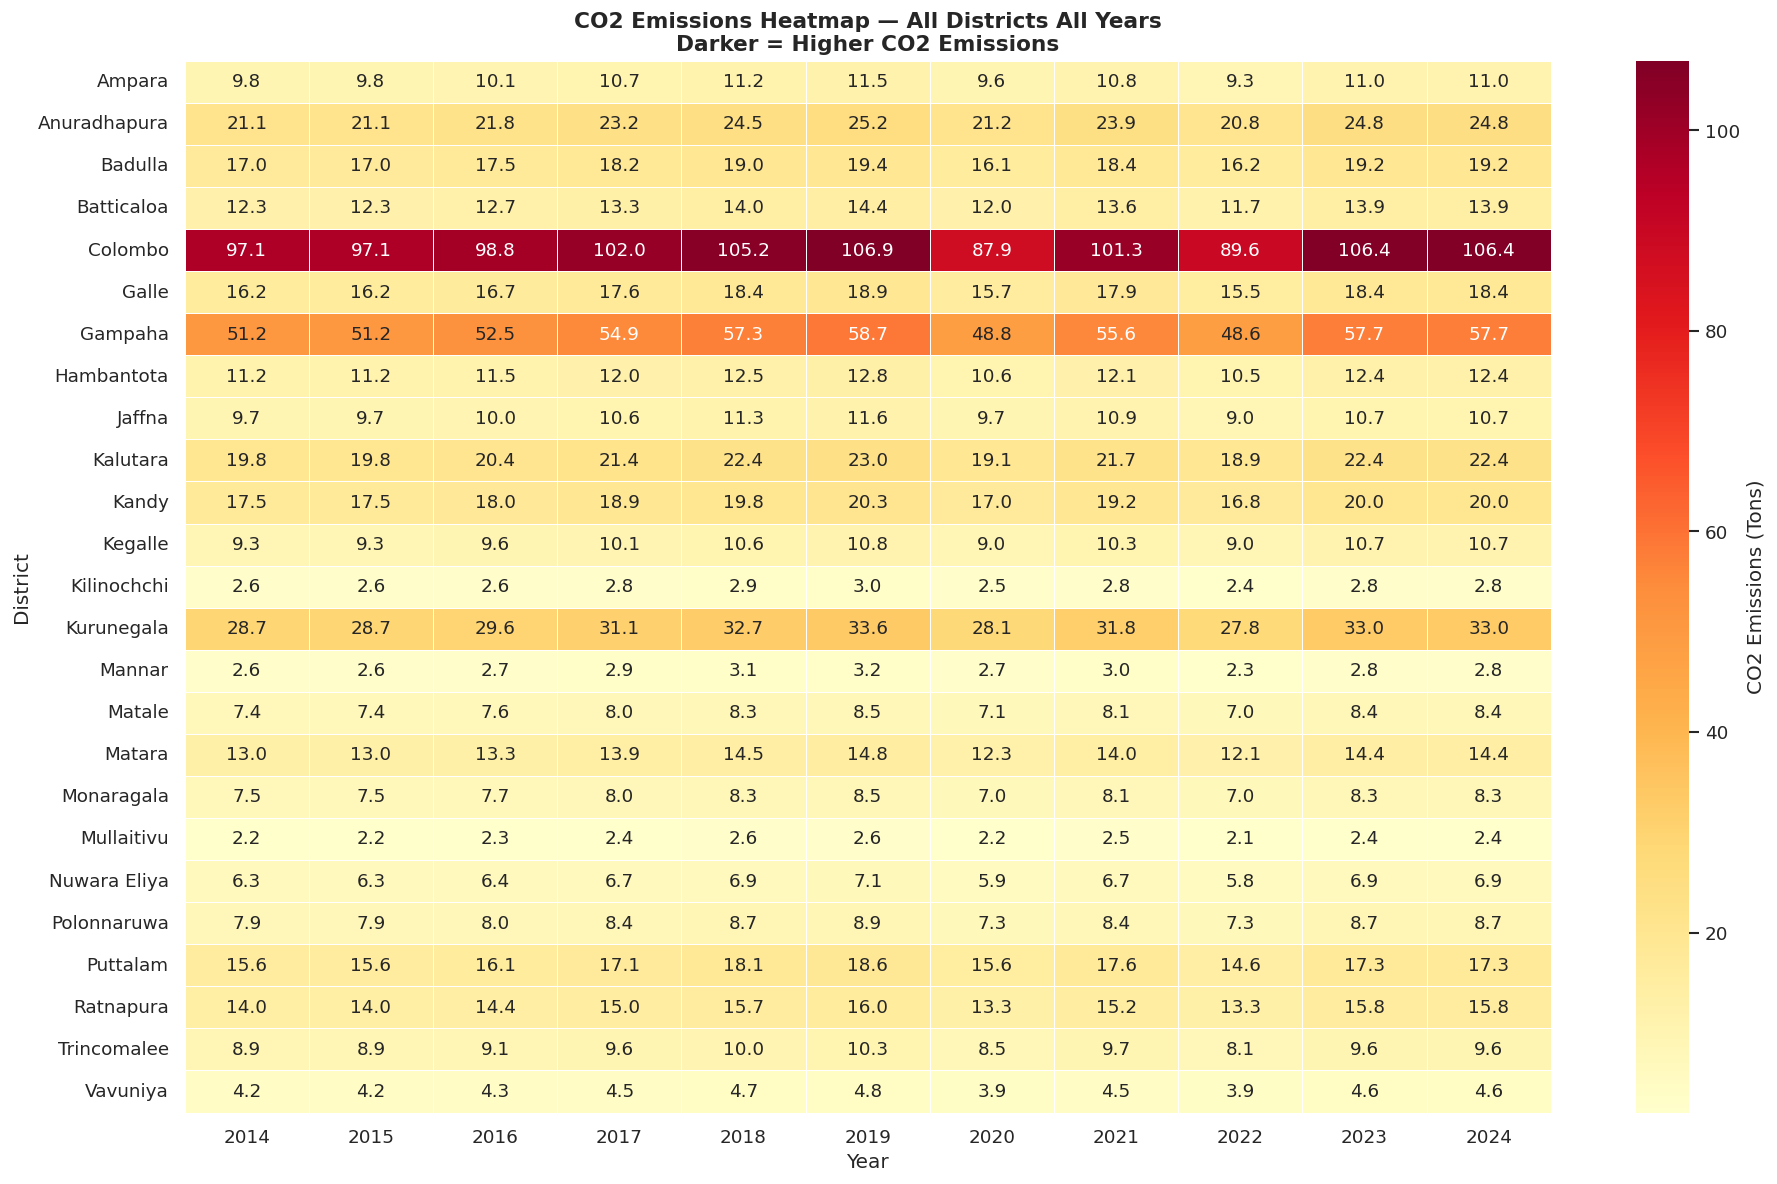

✅ Chart 2 done — CO2 heatmap all districts all years


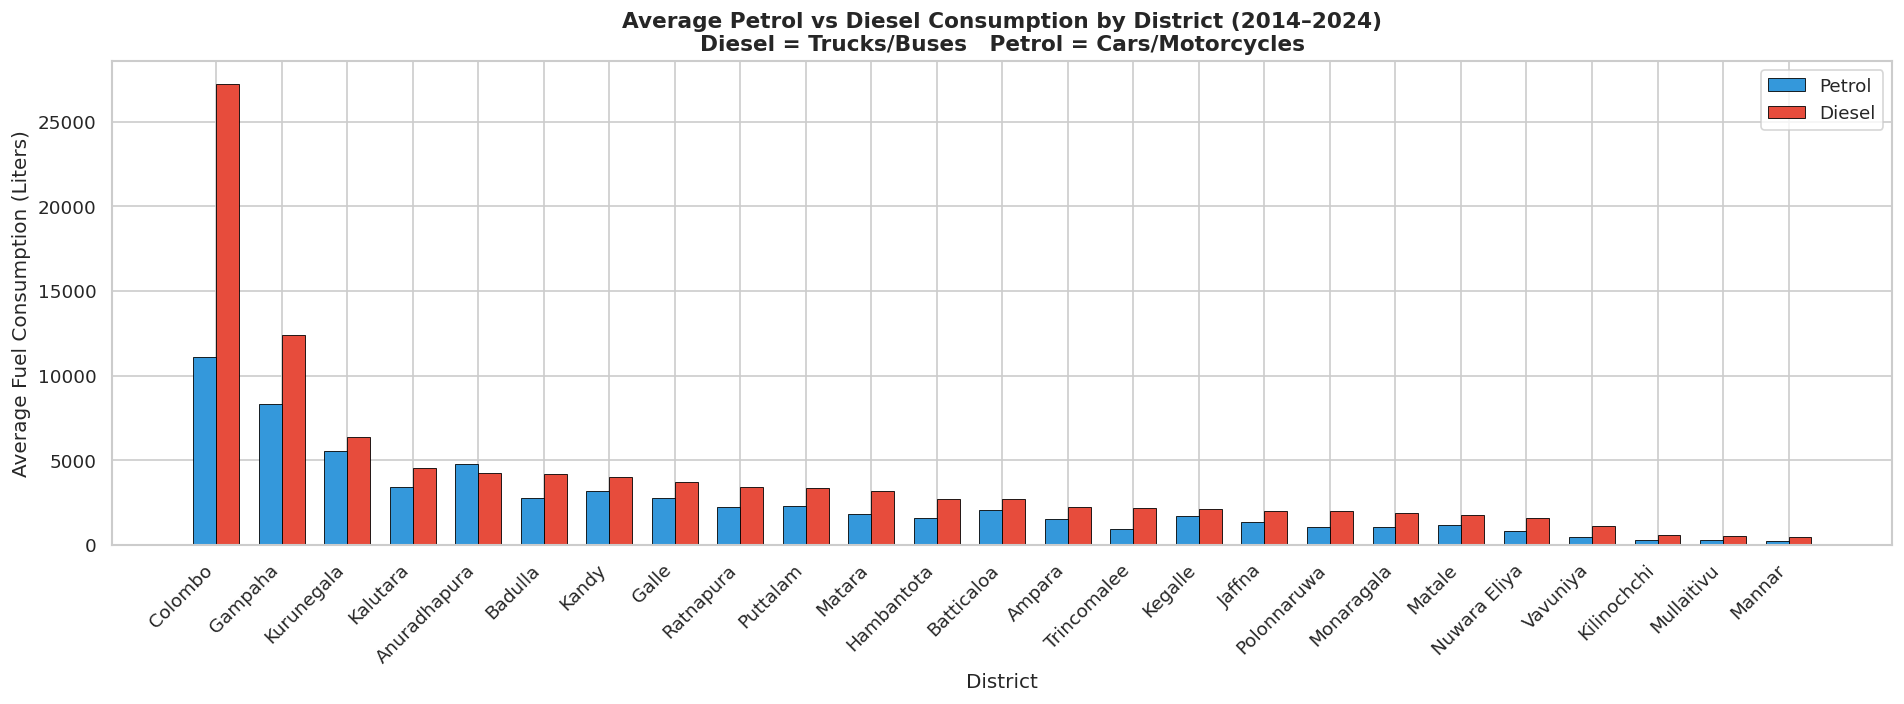

✅ Chart 3 done — Petrol vs Diesel by district


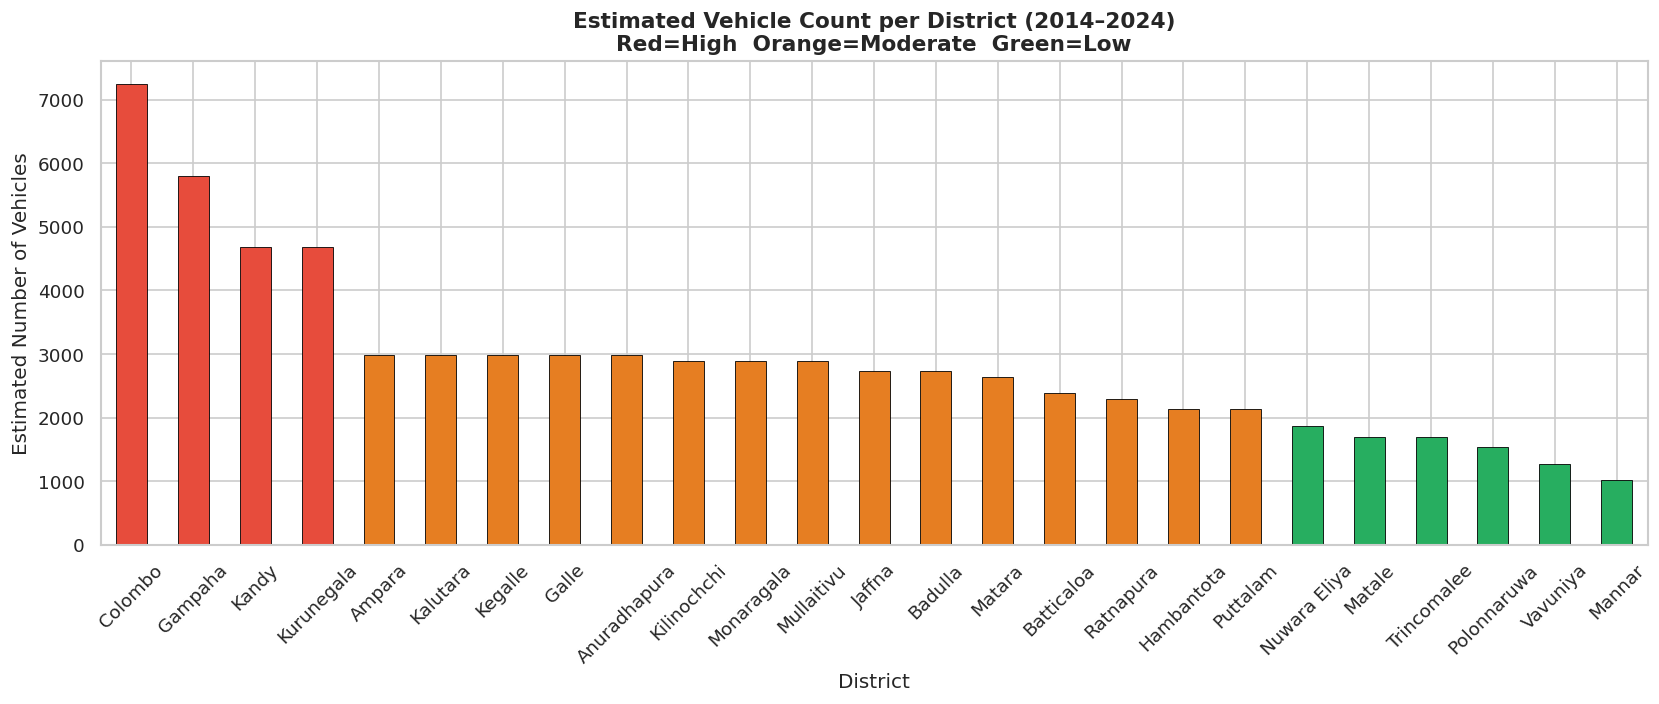

✅ Chart 4 done — Estimated vehicles per district


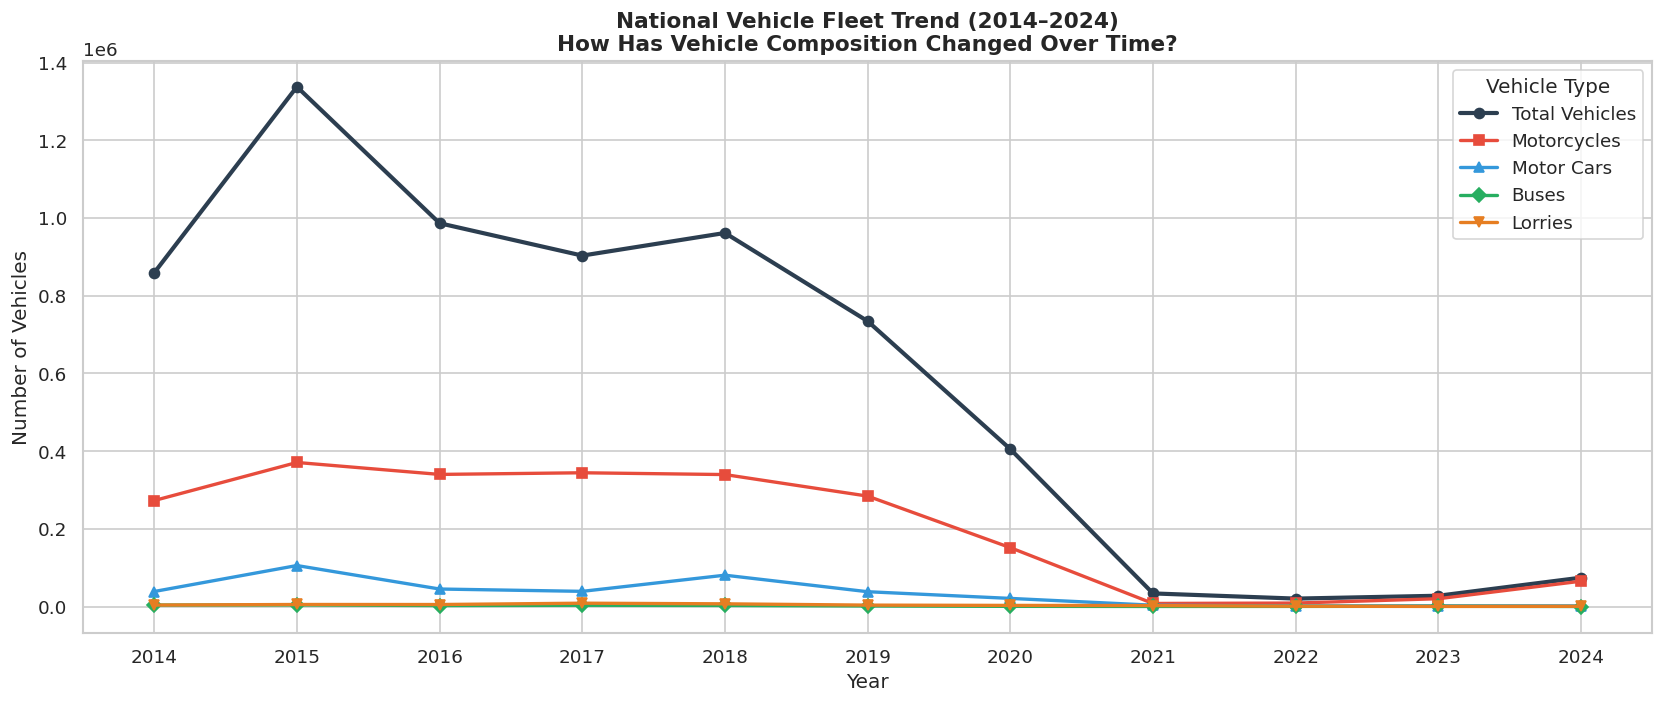

✅ Chart 5 done — National vehicle fleet trend


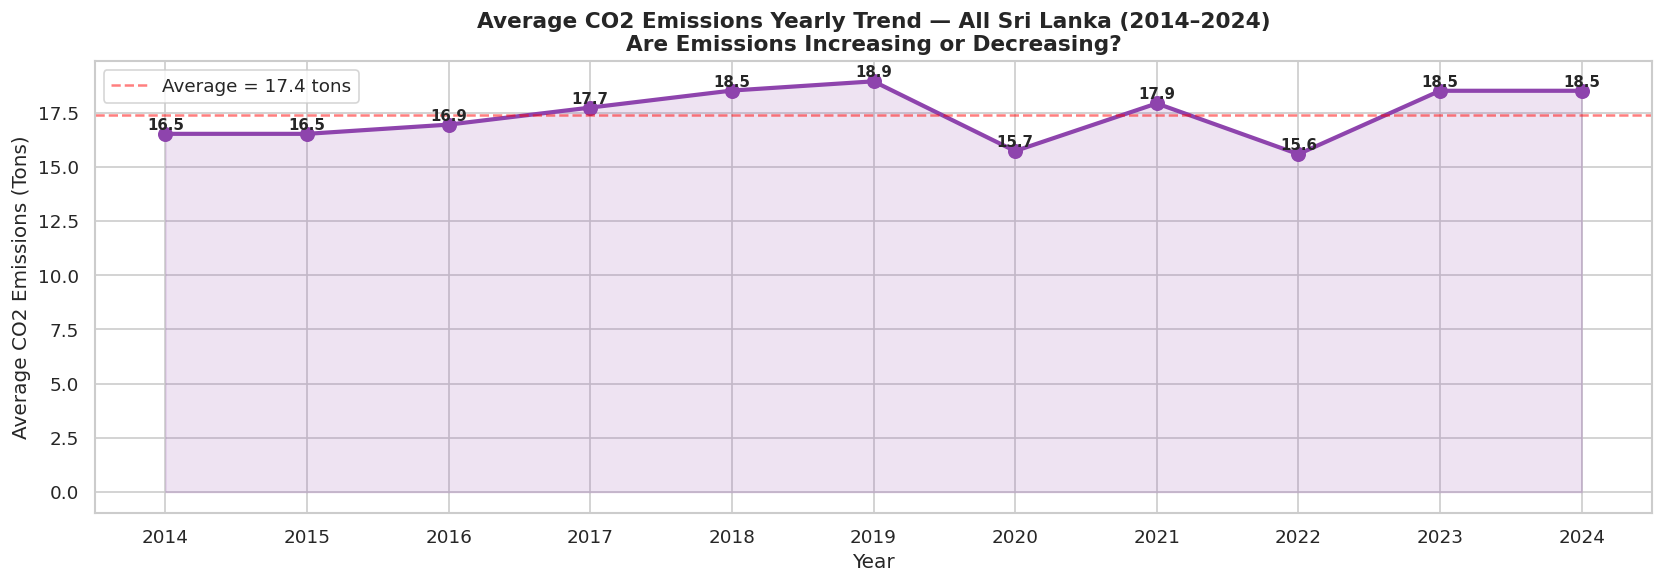

✅ Chart 6 done — CO2 yearly trend all Sri Lanka

📊 Vehicle and CO2 Emissions Summary:
   Highest CO2 district      : Colombo (99.9 tons avg)
   Second highest CO2        : Gampaha (54.0 tons avg)
   Lowest CO2 district       : Mullaitivu (2.4 tons avg)
   Diesel dominates petrol   : in all districts — heavy truck/bus usage
   National vehicle peak     : 2015 — 1,337,814 vehicles
   Key finding               : Vehicle count +0.348 corr with respiratory cases

✅ Step 9 Complete — Vehicle and CO2 emissions analysis done


In [35]:
# ── Chart 1: Average CO2 emissions per district ────────────
co2_by_district = df.groupby('district')['CO2_Total_Tons'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if v > 30 else '#e67e22' if v > 10 else '#27ae60'
          for v in co2_by_district.values]
co2_by_district.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Average CO2 Emissions per District (2014–2024)\nRed=High Emissions  Orange=Moderate  Green=Low',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average CO2 Emissions (Tons)')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(co2_by_district.values):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=7, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Average CO2 per district")

# ── Chart 2: CO2 heatmap all districts all years ──────────
co2_heatmap = df.groupby(['district','year'])['CO2_Total_Tons'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(co2_heatmap, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'CO2 Emissions (Tons)'})
ax.set_title('CO2 Emissions Heatmap — All Districts All Years\nDarker = Higher CO2 Emissions',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('District')
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — CO2 heatmap all districts all years")

# ── Chart 3: Petrol vs Diesel by district ─────────────────
fuel_district = df.groupby('district')[['Petrol_Liters',
                'Diesel_Liters']].mean().sort_values('Diesel_Liters', ascending=False)

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(fuel_district.index))
width = 0.35
# petrol bars left side diesel bars right side
ax.bar(x - width/2, fuel_district['Petrol_Liters'],
       width, label='Petrol', color='#3498db', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, fuel_district['Diesel_Liters'],
       width, label='Diesel', color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.set_title('Average Petrol vs Diesel Consumption by District (2014–2024)\nDiesel = Trucks/Buses   Petrol = Cars/Motorcycles',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average Fuel Consumption (Liters)')
ax.set_xticks(x)
ax.set_xticklabels(fuel_district.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — Petrol vs Diesel by district")

# ── Chart 4: Estimated vehicles per district ──────────────
vehicles_by_district = df.groupby('district')['Estimated_Vehicles'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors2 = ['#e74c3c' if v > 4000 else '#e67e22' if v > 2000 else '#27ae60'
           for v in vehicles_by_district.values]
vehicles_by_district.plot(kind='bar', ax=ax, color=colors2,
                           edgecolor='black', linewidth=0.5)
ax.set_title('Estimated Vehicle Count per District (2014–2024)\nRed=High  Orange=Moderate  Green=Low',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Estimated Number of Vehicles')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — Estimated vehicles per district")

# ── Chart 5: National vehicle fleet trend ─────────────────
# use .first() because national figures same for all districts same year
nat_vehicles = df.groupby('year')[['national_total_vehicles',
                                    'national_motorcycles',
                                    'national_motor_cars',
                                    'national_buses',
                                    'national_lorries']].first()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(nat_vehicles.index, nat_vehicles['national_total_vehicles'],
        marker='o', linewidth=2.5, color='#2c3e50', label='Total Vehicles')
ax.plot(nat_vehicles.index, nat_vehicles['national_motorcycles'],
        marker='s', linewidth=2, color='#e74c3c', label='Motorcycles')
ax.plot(nat_vehicles.index, nat_vehicles['national_motor_cars'],
        marker='^', linewidth=2, color='#3498db', label='Motor Cars')
ax.plot(nat_vehicles.index, nat_vehicles['national_buses'],
        marker='D', linewidth=2, color='#27ae60', label='Buses')
ax.plot(nat_vehicles.index, nat_vehicles['national_lorries'],
        marker='v', linewidth=2, color='#e67e22', label='Lorries')
ax.set_title('National Vehicle Fleet Trend (2014–2024)\nHow Has Vehicle Composition Changed Over Time?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Vehicles')
ax.set_xticks(range(2014, 2025))
ax.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()
print("✅ Chart 5 done — National vehicle fleet trend")

# ── Chart 6: CO2 yearly trend all Sri Lanka ────────────────
yearly_co2 = df.groupby('year')['CO2_Total_Tons'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yearly_co2.index, yearly_co2.values, marker='o',
        linewidth=2.5, color='#8e44ad', markersize=8)
ax.fill_between(yearly_co2.index, yearly_co2.values,
                alpha=0.15, color='#8e44ad')
ax.set_title('Average CO2 Emissions Yearly Trend — All Sri Lanka (2014–2024)\nAre Emissions Increasing or Decreasing?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average CO2 Emissions (Tons)')
ax.set_xticks(range(2014, 2025))
# add value labels on each point
for x, y in zip(yearly_co2.index, yearly_co2.values):
    ax.text(x, y + 0.2, f'{y:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.axhline(y=yearly_co2.mean(), color='red', linestyle='--',
           alpha=0.5, label=f'Average = {yearly_co2.mean():.1f} tons')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 6 done — CO2 yearly trend all Sri Lanka")

print("\n📊 Vehicle and CO2 Emissions Summary:")
print(f"   Highest CO2 district      : Colombo (99.9 tons avg)")
print(f"   Second highest CO2        : Gampaha (54.0 tons avg)")
print(f"   Lowest CO2 district       : Mullaitivu (2.4 tons avg)")
print(f"   Diesel dominates petrol   : in all districts — heavy truck/bus usage")
print(f"   National vehicle peak     : 2015 — 1,337,814 vehicles")
print(f"   Key finding               : Vehicle count +0.348 corr with respiratory cases")

print("\n✅ Step 9 Complete — Vehicle and CO2 emissions analysis done")

District-Wise Respiratory Health Analysis

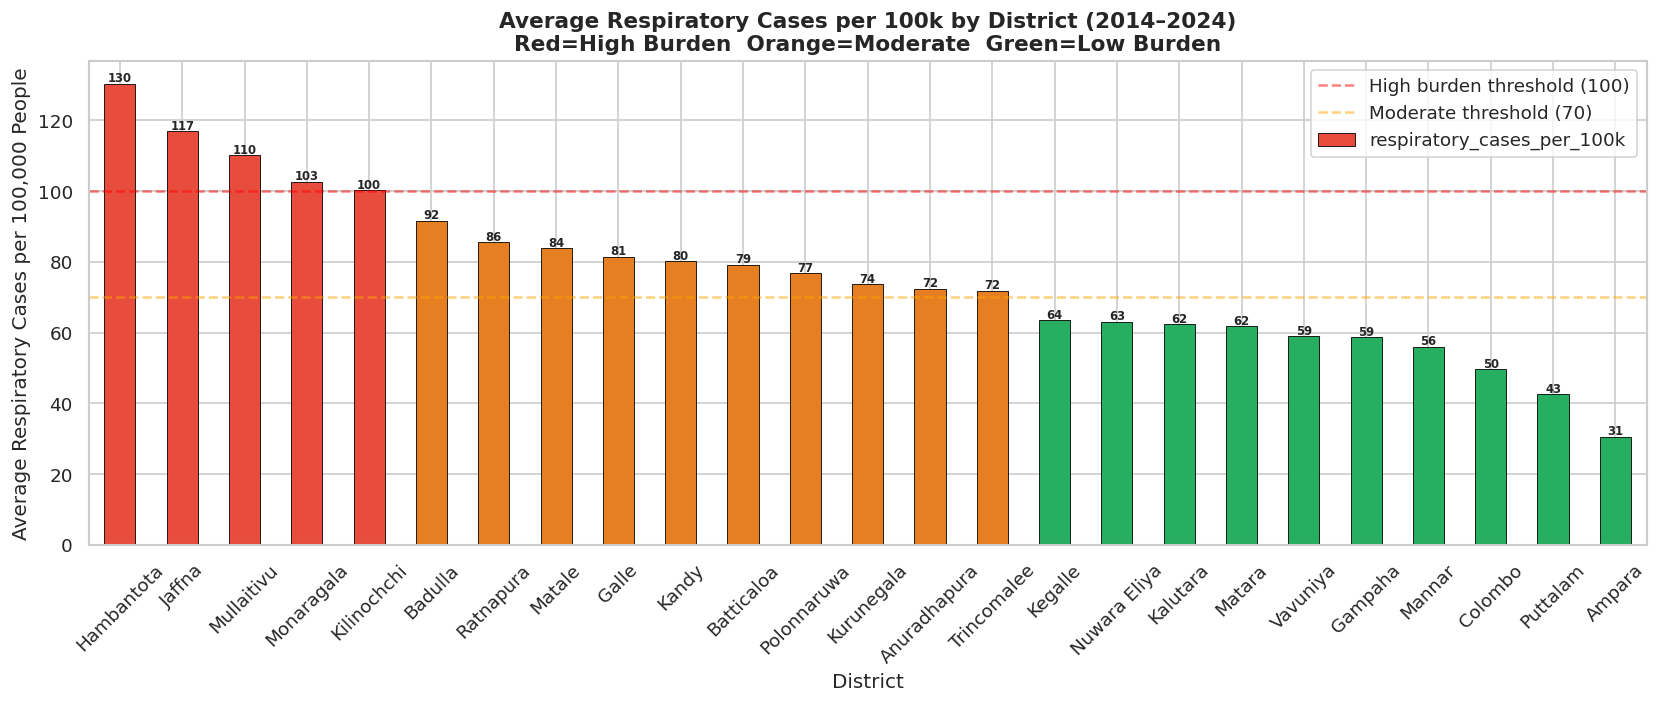

✅ Chart 1 done — Respiratory cases per 100k by district


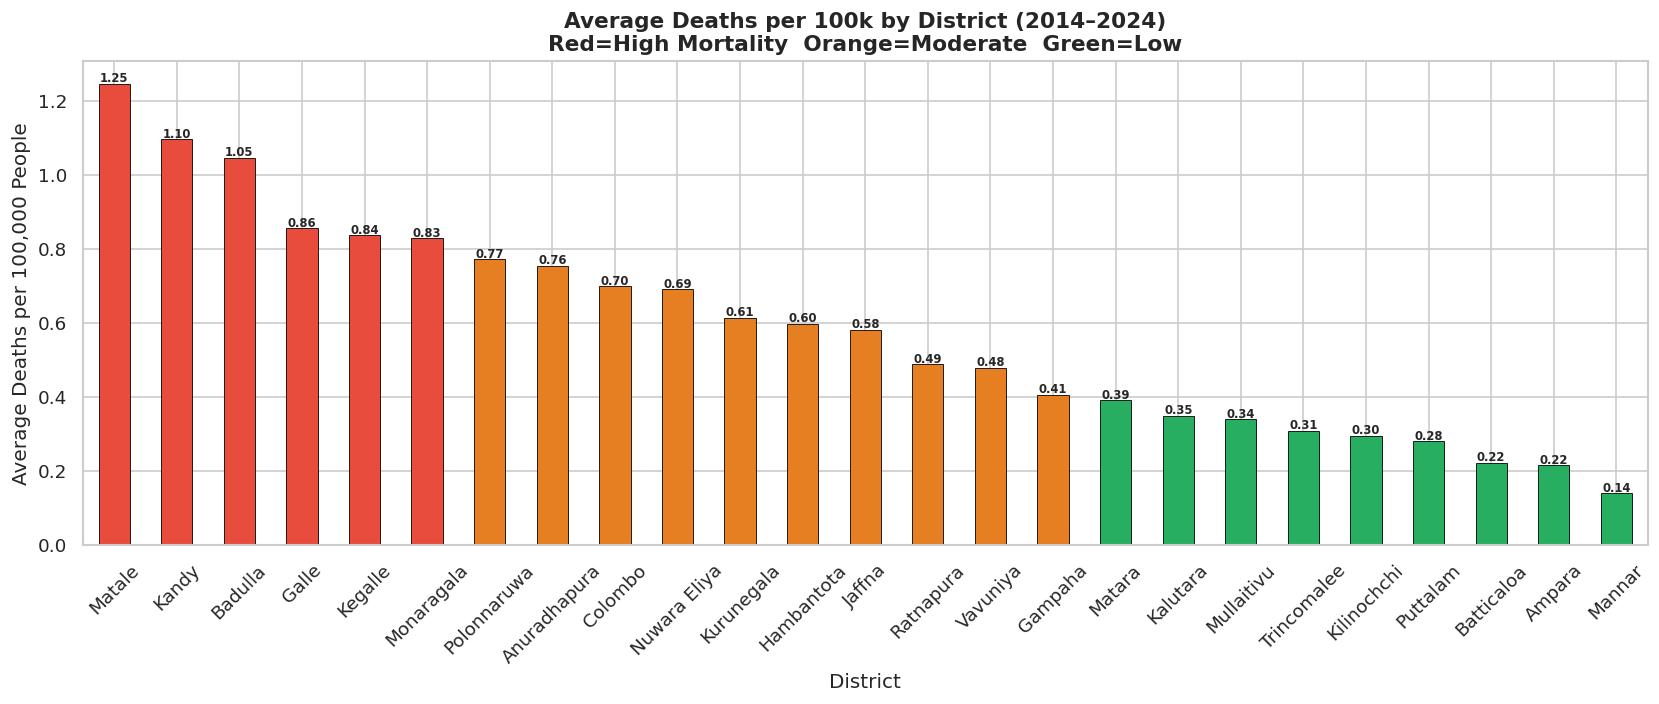

✅ Chart 2 done — Deaths per 100k by district


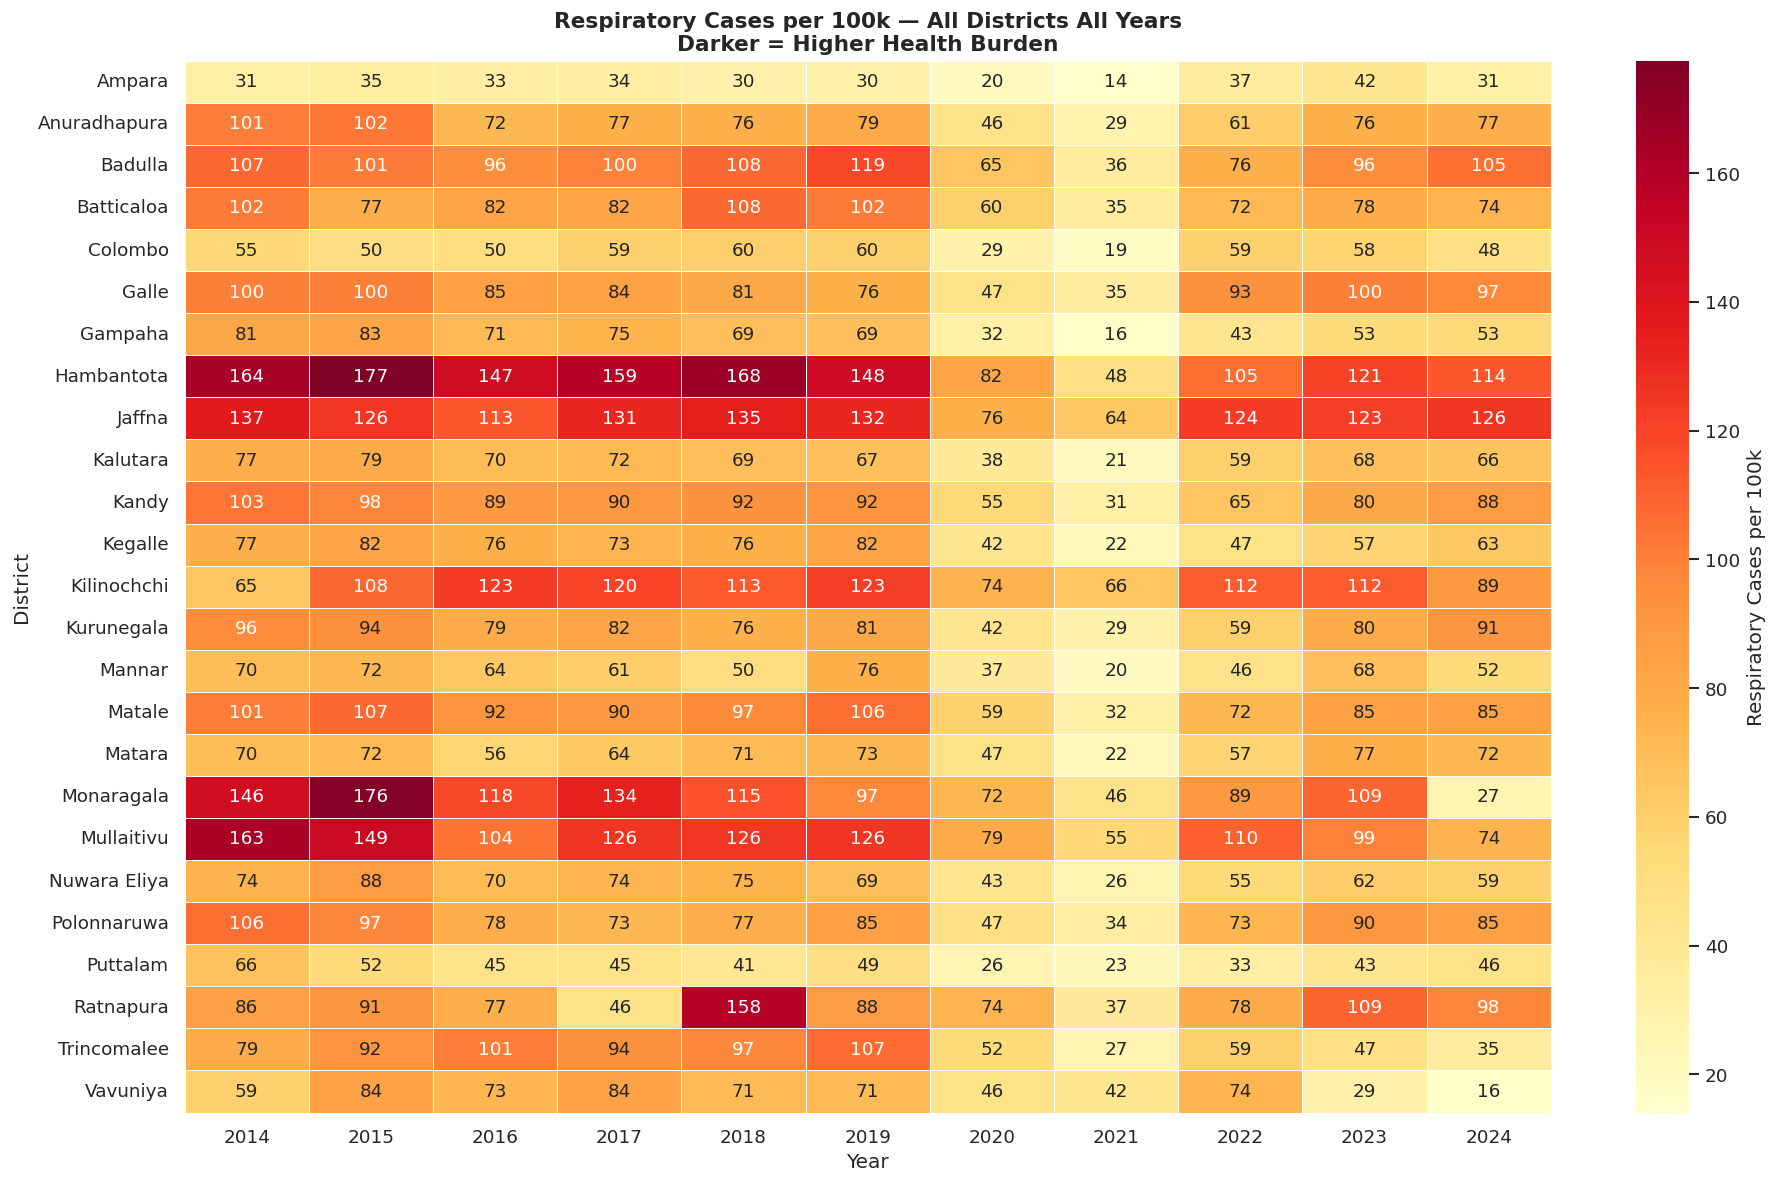

✅ Chart 3 done — Respiratory cases heatmap all districts


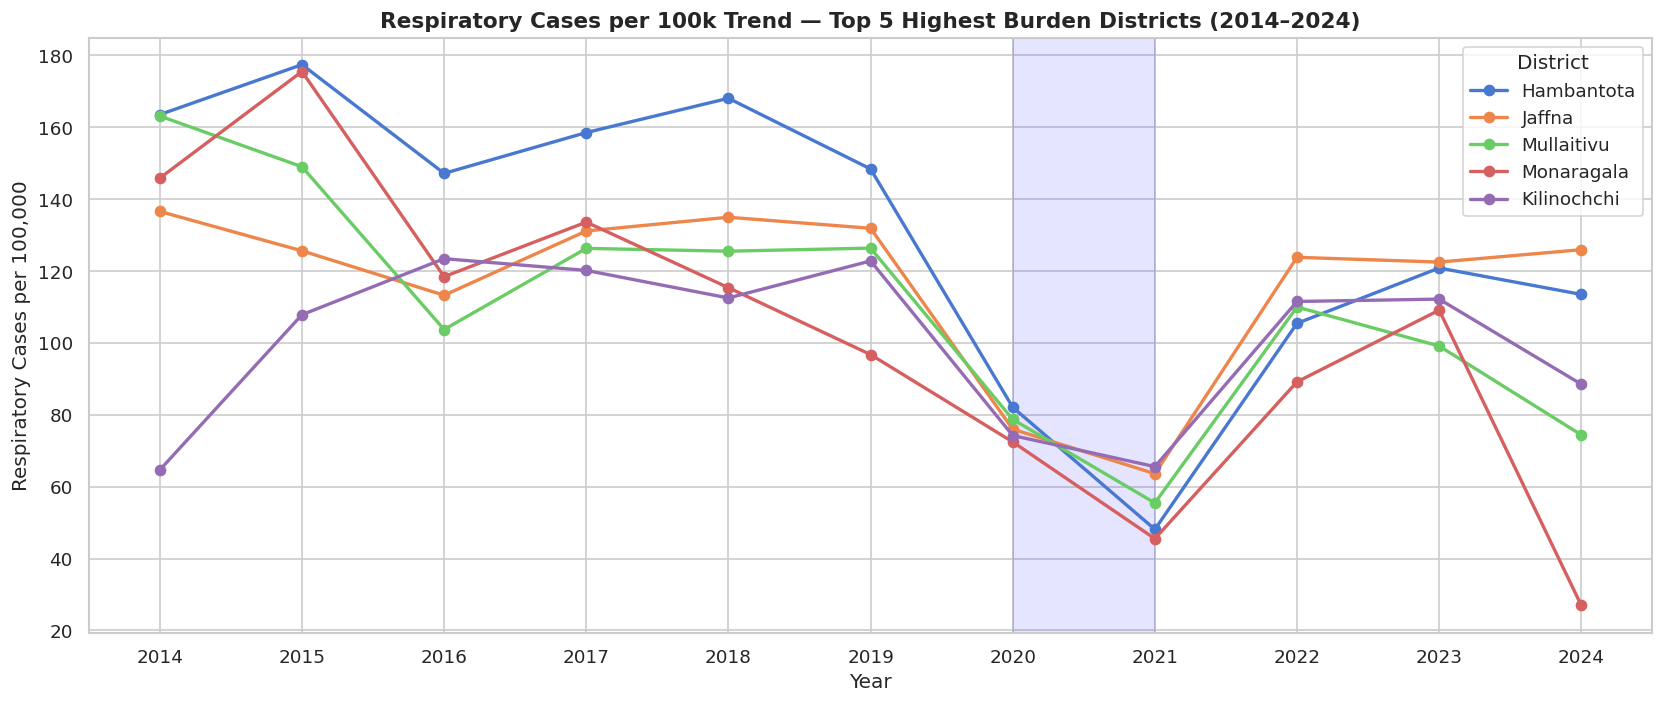

✅ Chart 4 done — Respiratory trend top 5 districts


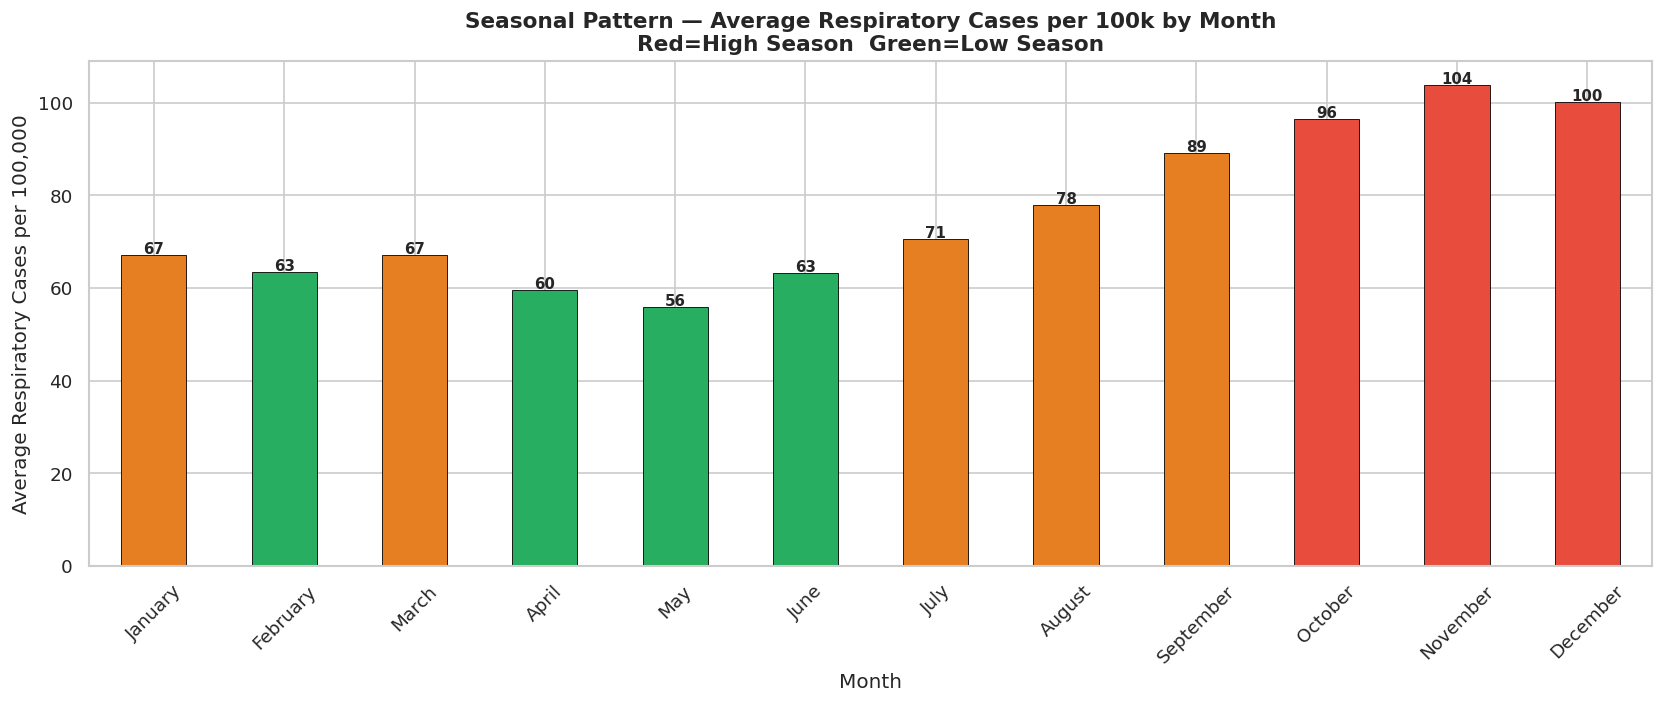

✅ Chart 5 done — Seasonal pattern of respiratory cases


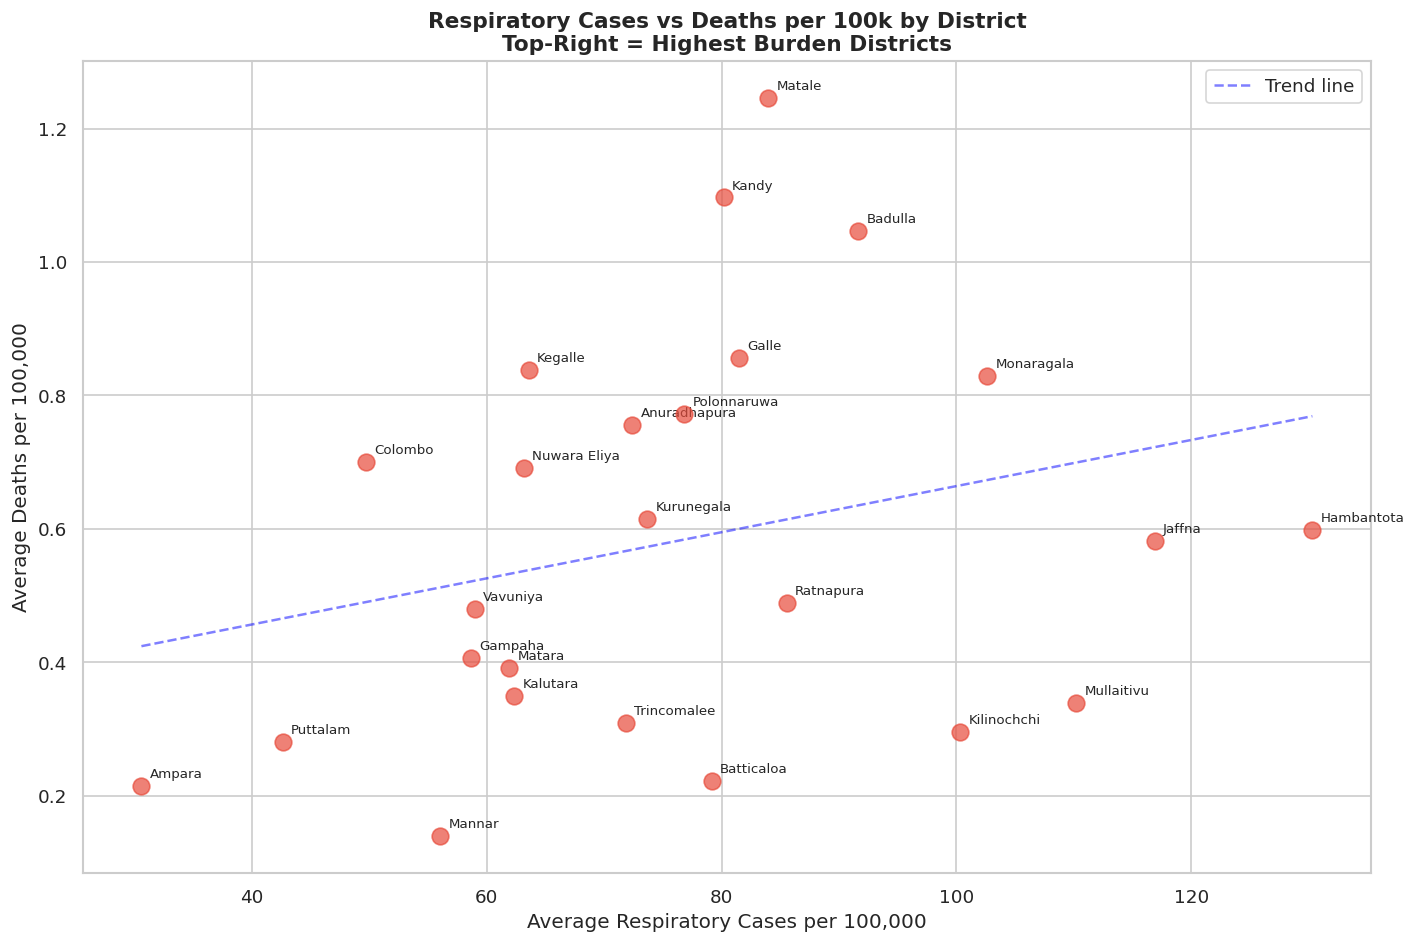

✅ Chart 6 done — Respiratory cases vs deaths scatter

📊 Respiratory Health Summary:
   Highest burden district  : Hambantota (130.3 per 100k)
   Second highest           : Jaffna (116.9 per 100k)
   Lowest burden district   : Ampara (30.6 per 100k)
   Peak respiratory months  : October, November, December
   Lowest respiratory month : May (55.8 per 100k)
   COVID impact             : 2020-2021 sharp drop in all districts
   Overall Sri Lanka avg    : 76.2 per 100k

✅ Step 10 Complete — District-wise respiratory health analysis done


In [41]:
# ── Chart 1: Respiratory cases per 100k by district ───────
resp_by_district = df.groupby('district')['respiratory_cases_per_100k'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if v > 100 else '#e67e22' if v > 70 else '#27ae60'
          for v in resp_by_district.values]
resp_by_district.plot(kind='bar', ax=ax, color=colors,
                      edgecolor='black', linewidth=0.5)
ax.set_title('Average Respiratory Cases per 100k by District (2014–2024)\nRed=High Burden  Orange=Moderate  Green=Low Burden',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average Respiratory Cases per 100,000 People')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=100, color='red', linestyle='--',
           alpha=0.5, label='High burden threshold (100)')
ax.axhline(y=70, color='orange', linestyle='--',
           alpha=0.5, label='Moderate threshold (70)')
ax.legend()
for i, v in enumerate(resp_by_district.values):
    ax.text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=7, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Respiratory cases per 100k by district")

# ── Chart 2: Deaths per 100k by district ──────────────────
deaths_by_district = df.groupby('district')['deaths_per_100k'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors2 = ['#e74c3c' if v > 0.8 else '#e67e22' if v > 0.4 else '#27ae60'
           for v in deaths_by_district.values]
deaths_by_district.plot(kind='bar', ax=ax, color=colors2,
                        edgecolor='black', linewidth=0.5)
ax.set_title('Average Deaths per 100k by District (2014–2024)\nRed=High Mortality  Orange=Moderate  Green=Low',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average Deaths per 100,000 People')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(deaths_by_district.values):
    ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=7, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Deaths per 100k by district")

# ── Chart 3: Respiratory cases heatmap all districts ──────
resp_heatmap = df.groupby(['district','year'])['respiratory_cases_per_100k'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(resp_heatmap, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Respiratory Cases per 100k'})
ax.set_title('Respiratory Cases per 100k — All Districts All Years\nDarker = Higher Health Burden',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('District')
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — Respiratory cases heatmap all districts")

# ── Chart 4: Trend for top 5 highest burden districts ─────
top5_resp = resp_by_district.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for district in top5_resp:
    # filter this district only — avg respiratory cases per year
    data = df[df['district'] == district].groupby('year')['respiratory_cases_per_100k'].mean()
    ax.plot(data.index, data.values, marker='o', linewidth=2, label=district)
ax.set_title('Respiratory Cases per 100k Trend — Top 5 Highest Burden Districts (2014–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Respiratory Cases per 100,000')
ax.set_xticks(range(2014, 2025))
ax.legend(title='District')
# mark COVID period
ax.axvspan(2020, 2021, alpha=0.1, color='blue', label='COVID Period')
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — Respiratory trend top 5 districts")

# ── Chart 5: Seasonal pattern of respiratory cases ────────
seasonal_resp = df.groupby('month_num')['respiratory_cases_per_100k'].mean()
seasonal_resp.index = month_order  # replace numbers with month names

fig, ax = plt.subplots(figsize=(14, 6))
colors3 = ['#e74c3c' if v > 90 else '#e67e22' if v > 65 else '#27ae60'
           for v in seasonal_resp.values]
seasonal_resp.plot(kind='bar', ax=ax, color=colors3,
                   edgecolor='black', linewidth=0.5)
ax.set_title('Seasonal Pattern — Average Respiratory Cases per 100k by Month\nRed=High Season  Green=Low Season',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Respiratory Cases per 100,000')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(seasonal_resp.values):
    ax.text(i, v + 0.3, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 5 done — Seasonal pattern of respiratory cases")

# ── Chart 6: Respiratory cases vs deaths scatter ──────────
district_health = df.groupby('district')[['respiratory_cases_per_100k',
                                           'deaths_per_100k']].mean()

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(district_health['respiratory_cases_per_100k'],
           district_health['deaths_per_100k'],
           color='#e74c3c', s=100, alpha=0.7, zorder=5)
# label each district dot
for idx, row in district_health.iterrows():
    ax.annotate(idx,
                (row['respiratory_cases_per_100k'], row['deaths_per_100k']),
                fontsize=8, textcoords='offset points', xytext=(5, 5))
ax.set_title('Respiratory Cases vs Deaths per 100k by District\nTop-Right = Highest Burden Districts',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Respiratory Cases per 100,000')
ax.set_ylabel('Average Deaths per 100,000')
# add trend line
z = np.polyfit(district_health['respiratory_cases_per_100k'],
               district_health['deaths_per_100k'], 1)
p = np.poly1d(z)
x_range = np.linspace(district_health['respiratory_cases_per_100k'].min(),
                       district_health['respiratory_cases_per_100k'].max(), 100)
ax.plot(x_range, p(x_range), color='blue', linestyle='--',
        alpha=0.5, label='Trend line')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 6 done — Respiratory cases vs deaths scatter")

print("\n📊 Respiratory Health Summary:")
print(f"   Highest burden district  : Hambantota (130.3 per 100k)")
print(f"   Second highest           : Jaffna (116.9 per 100k)")
print(f"   Lowest burden district   : Ampara (30.6 per 100k)")
print(f"   Peak respiratory months  : October, November, December")
print(f"   Lowest respiratory month : May (55.8 per 100k)")
print(f"   COVID impact             : 2020-2021 sharp drop in all districts")
print(f"   Overall Sri Lanka avg    : {df['respiratory_cases_per_100k'].mean():.1f} per 100k")

print("\n✅ Step 10 Complete — District-wise respiratory health analysis done")

Correlation Analysis

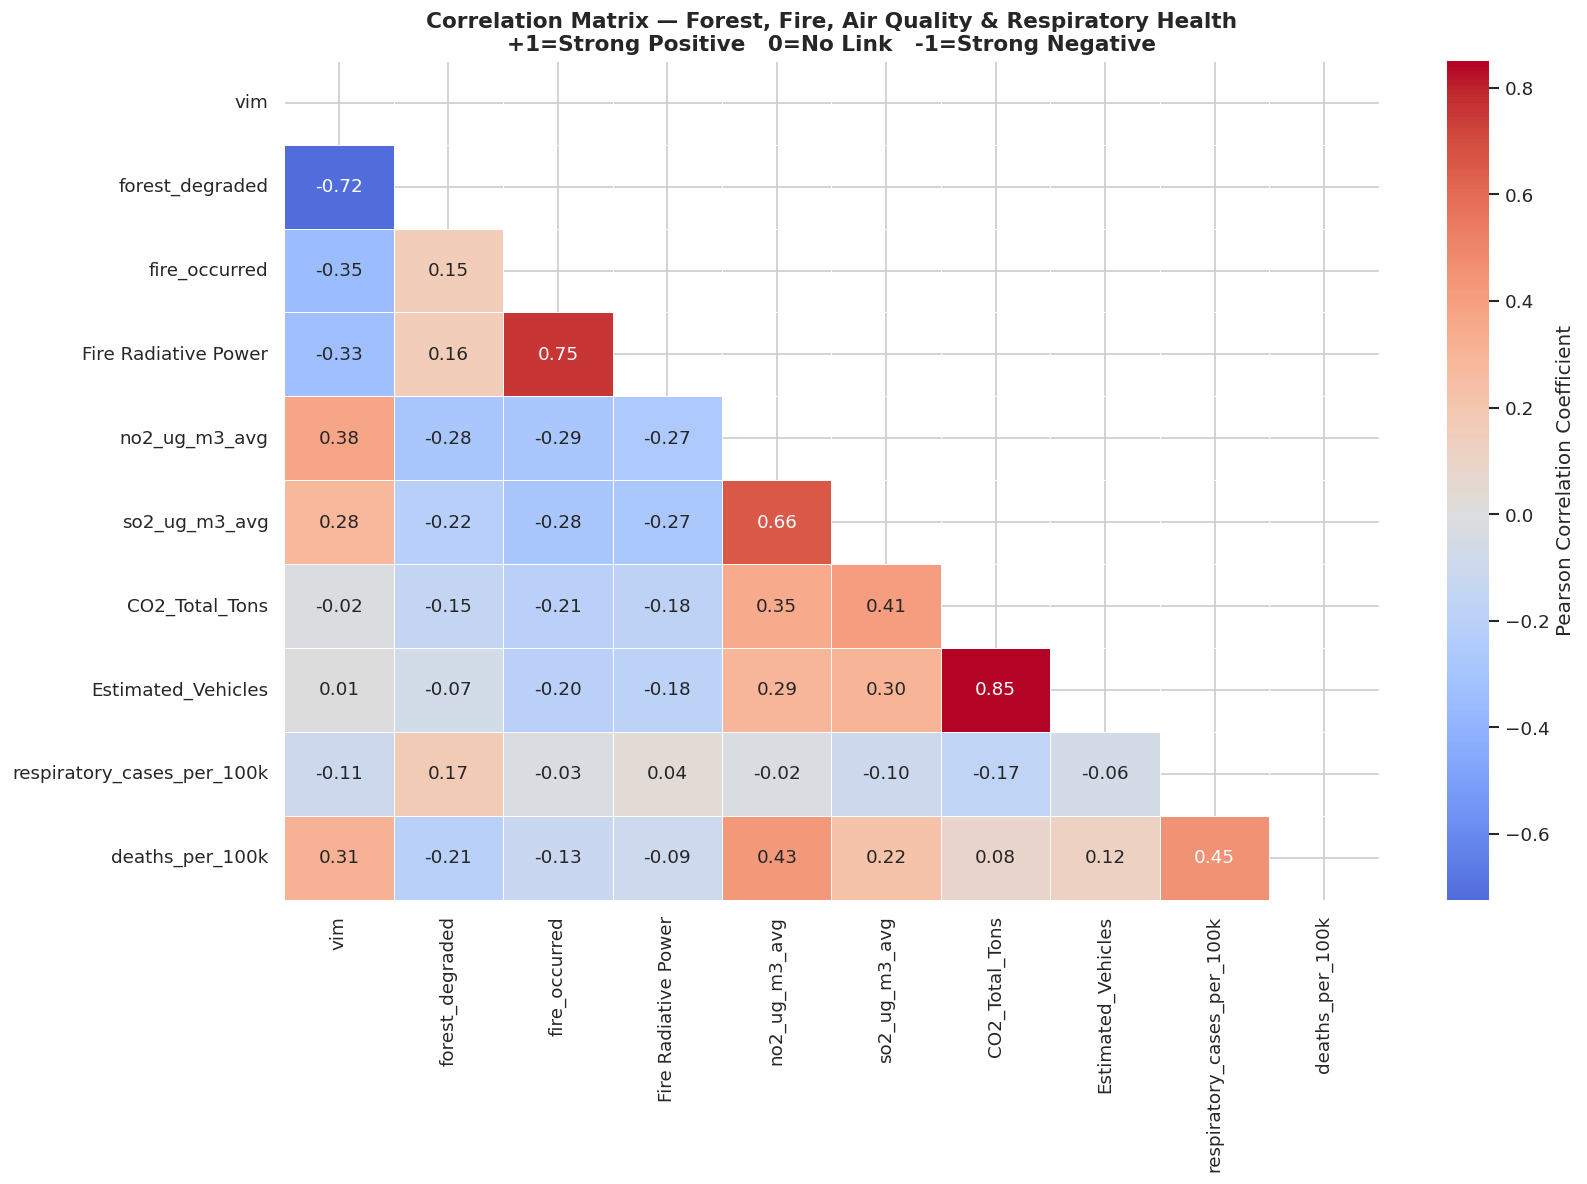

✅ Chart 1 done — Full correlation heatmap


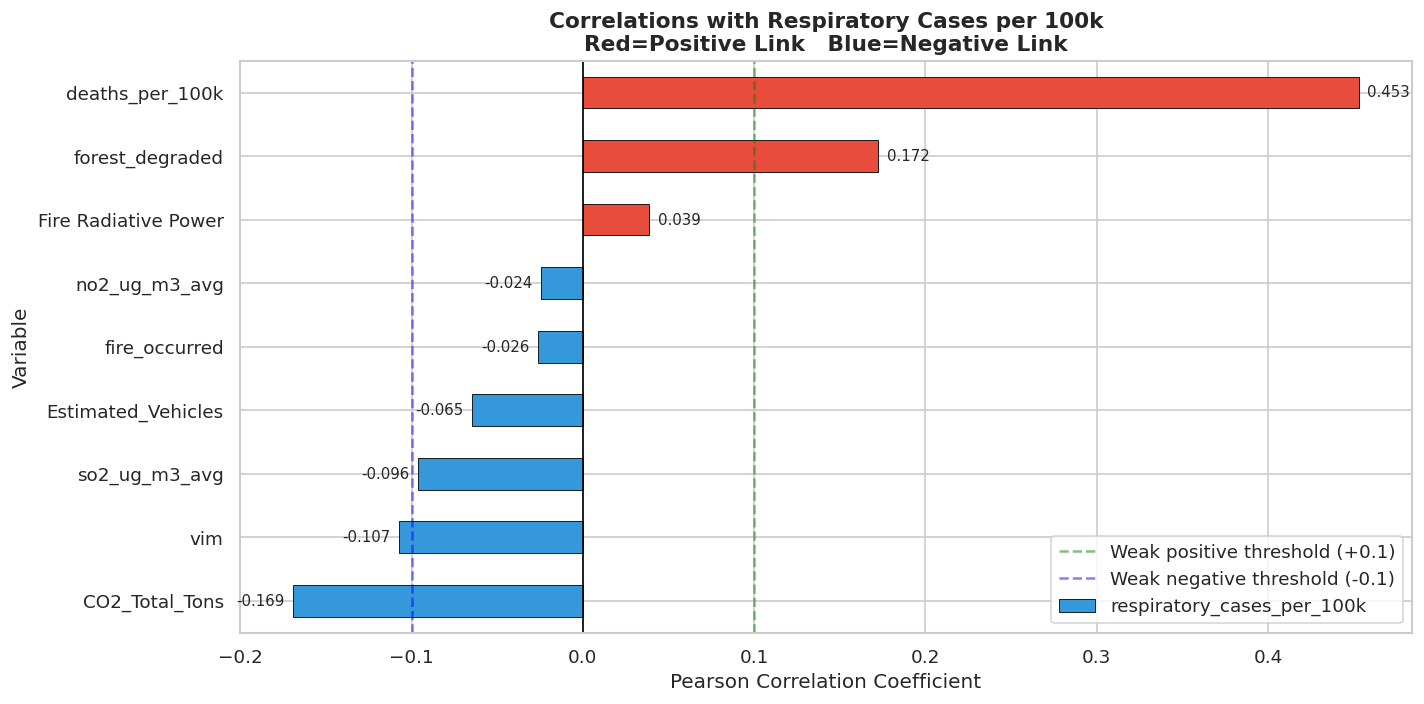

✅ Chart 2 done — Correlations with respiratory cases


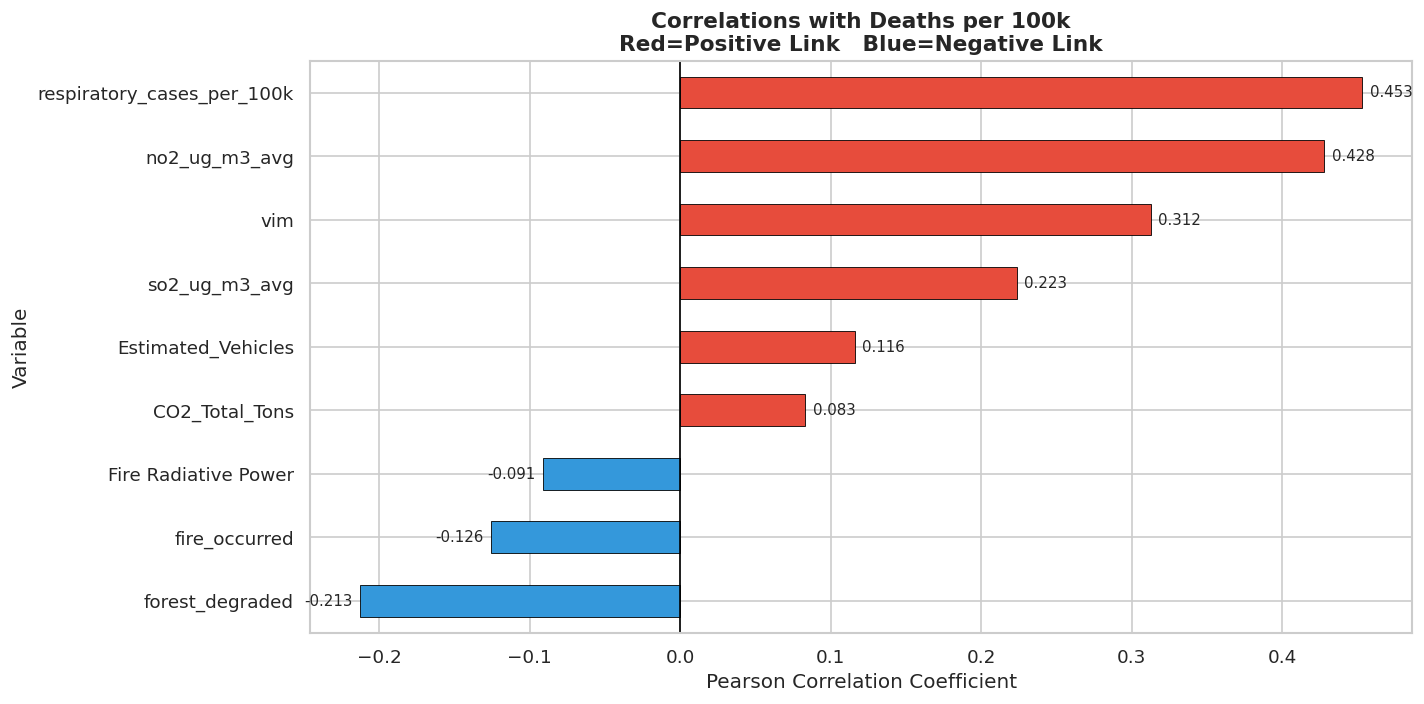

✅ Chart 3 done — Correlations with deaths per 100k


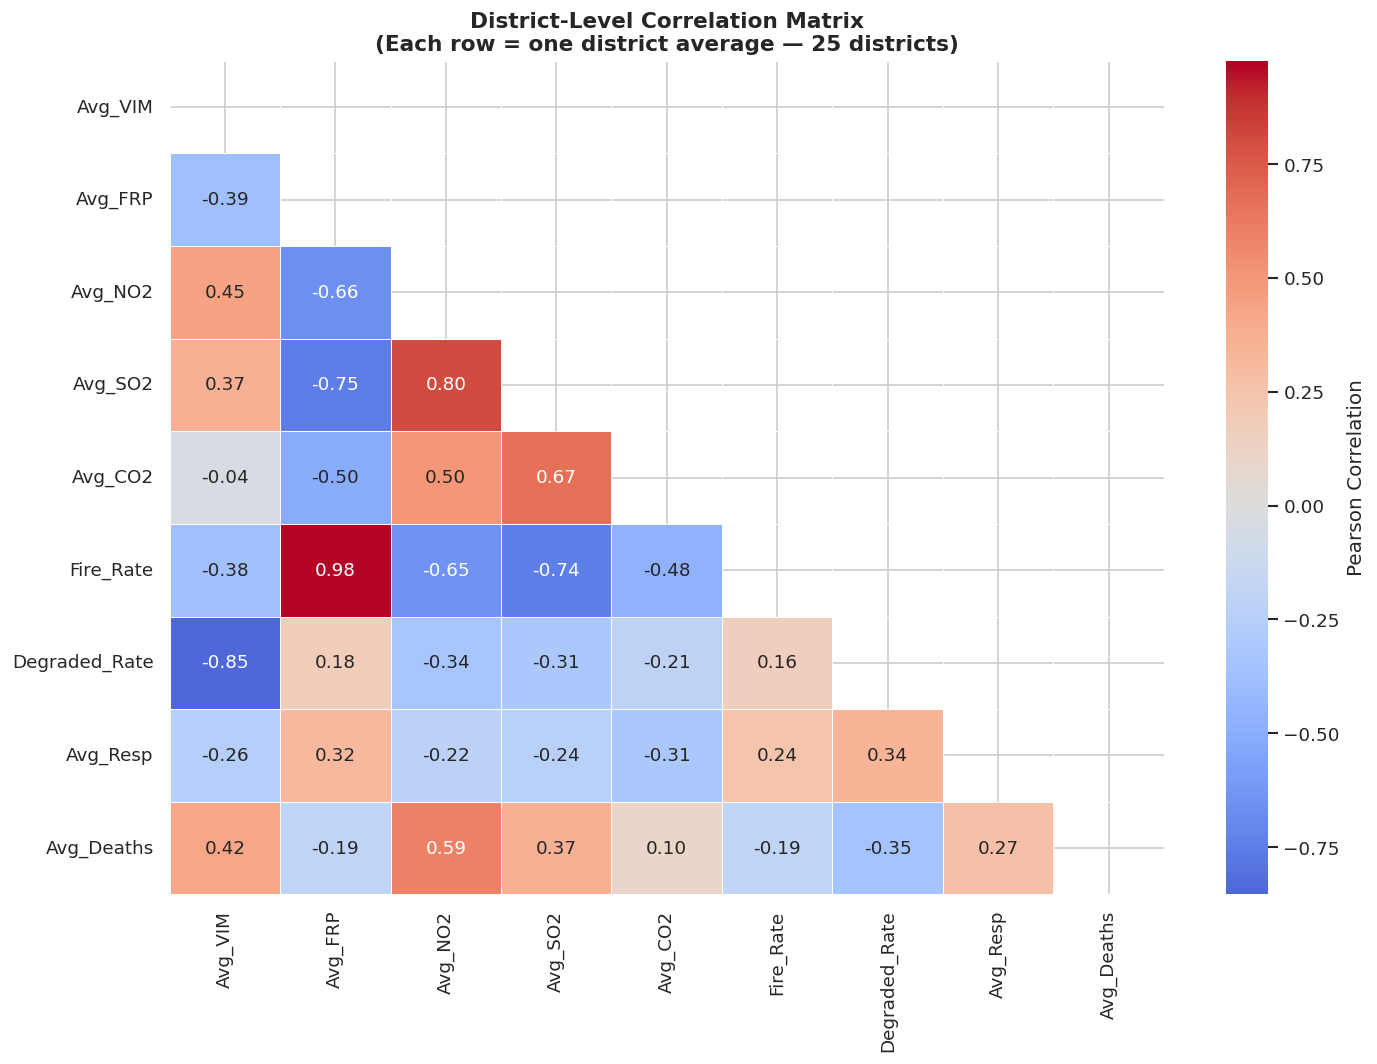

✅ Chart 4 done — District level correlation heatmap

📊 KEY CORRELATION FINDINGS FOR SHORT PAPER:

Correlations with Respiratory Cases per 100k:
deaths_per_100k         0.453058
forest_degraded         0.172440
Fire Radiative Power    0.038842
no2_ug_m3_avg          -0.024331
fire_occurred          -0.025996
Estimated_Vehicles     -0.064791
so2_ug_m3_avg          -0.096392
vim                    -0.107070
CO2_Total_Tons         -0.169289

Correlations with Deaths per 100k:
respiratory_cases_per_100k    0.453058
no2_ug_m3_avg                 0.427691
vim                           0.312376
so2_ug_m3_avg                 0.223339
Estimated_Vehicles            0.115858
CO2_Total_Tons                0.083022
Fire Radiative Power         -0.090989
fire_occurred                -0.125947
forest_degraded              -0.212857

District-level correlations with Avg_Resp:
Degraded_Rate    0.342587
Avg_FRP          0.315811
Avg_Deaths       0.272074
Fire_Rate        0.240630
Avg_NO2         -0.22035

In [40]:
# select key columns for correlation
corr_cols = ['vim', 'forest_degraded', 'fire_occurred',
             'Fire Radiative Power', 'no2_ug_m3_avg', 'so2_ug_m3_avg',
             'CO2_Total_Tons', 'Estimated_Vehicles',
             'respiratory_cases_per_100k', 'deaths_per_100k']

corr_matrix = df[corr_cols].corr()

# ── Chart 1: Full correlation heatmap ─────────────────────
# hide upper triangle — same as lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax.set_title('Correlation Matrix — Forest, Fire, Air Quality & Respiratory Health\n+1=Strong Positive   0=No Link   -1=Strong Negative',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Full correlation heatmap")

# ── Chart 2: Correlations with respiratory cases ──────────
corr_resp = corr_matrix['respiratory_cases_per_100k'].drop(
    'respiratory_cases_per_100k').sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_resp.values]
corr_resp.plot(kind='barh', ax=ax, color=colors,
               edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=0.1, color='green', linestyle='--',
           alpha=0.5, label='Weak positive threshold (+0.1)')
ax.axvline(x=-0.1, color='blue', linestyle='--',
           alpha=0.5, label='Weak negative threshold (-0.1)')
ax.set_title('Correlations with Respiratory Cases per 100k\nRed=Positive Link   Blue=Negative Link',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('Variable')
for i, v in enumerate(corr_resp.values):
    ax.text(v + 0.005 if v >= 0 else v - 0.005, i,
            f'{v:.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Correlations with respiratory cases")

# ── Chart 3: Correlations with deaths per 100k ────────────
corr_deaths = corr_matrix['deaths_per_100k'].drop(
    'deaths_per_100k').sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors2 = ['#e74c3c' if v > 0 else '#3498db' for v in corr_deaths.values]
corr_deaths.plot(kind='barh', ax=ax, color=colors2,
                 edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Correlations with Deaths per 100k\nRed=Positive Link   Blue=Negative Link',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('Variable')
for i, v in enumerate(corr_deaths.values):
    ax.text(v + 0.005 if v >= 0 else v - 0.005, i,
            f'{v:.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — Correlations with deaths per 100k")

# ── Chart 4: District level correlation heatmap ───────────
# aggregate to district level — 25 rows instead of 3300
district_corr = df.groupby('district').agg(
    Avg_VIM=('vim', 'mean'),
    Avg_FRP=('Fire Radiative Power', 'mean'),
    Avg_NO2=('no2_ug_m3_avg', 'mean'),
    Avg_SO2=('so2_ug_m3_avg', 'mean'),
    Avg_CO2=('CO2_Total_Tons', 'mean'),
    Fire_Rate=('fire_occurred', 'mean'),
    Degraded_Rate=('forest_degraded', 'mean'),
    Avg_Resp=('respiratory_cases_per_100k', 'mean'),
    Avg_Deaths=('deaths_per_100k', 'mean')
)

# correlate at district level
district_corr_matrix = district_corr.corr()
mask2 = np.triu(np.ones_like(district_corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(district_corr_matrix, mask=mask2, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('District-Level Correlation Matrix\n(Each row = one district average — 25 districts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — District level correlation heatmap")

# print key correlation findings for paper
print("\n📊 KEY CORRELATION FINDINGS FOR SHORT PAPER:")
print("\nCorrelations with Respiratory Cases per 100k:")
print(corr_resp.sort_values(ascending=False).to_string())
print("\nCorrelations with Deaths per 100k:")
print(corr_deaths.sort_values(ascending=False).to_string())
print("\nDistrict-level correlations with Avg_Resp:")
print(district_corr_matrix['Avg_Resp'].drop('Avg_Resp').sort_values(ascending=False).to_string())

print("\n✅ Step 11 Complete — Correlation analysis done")

Forest Degradation vs Respiratory Health


📊 T-Test Results — Healthy vs Degraded Forest:
   Healthy forest avg   : 73.73 cases per 100k
   Degraded forest avg  : 92.56 cases per 100k
   Difference           : 18.83 cases per 100k
   T-statistic          : -10.0535
   P-value              : 0.000000
   ✅ SIGNIFICANT — Degraded forests ARE linked to higher respiratory cases


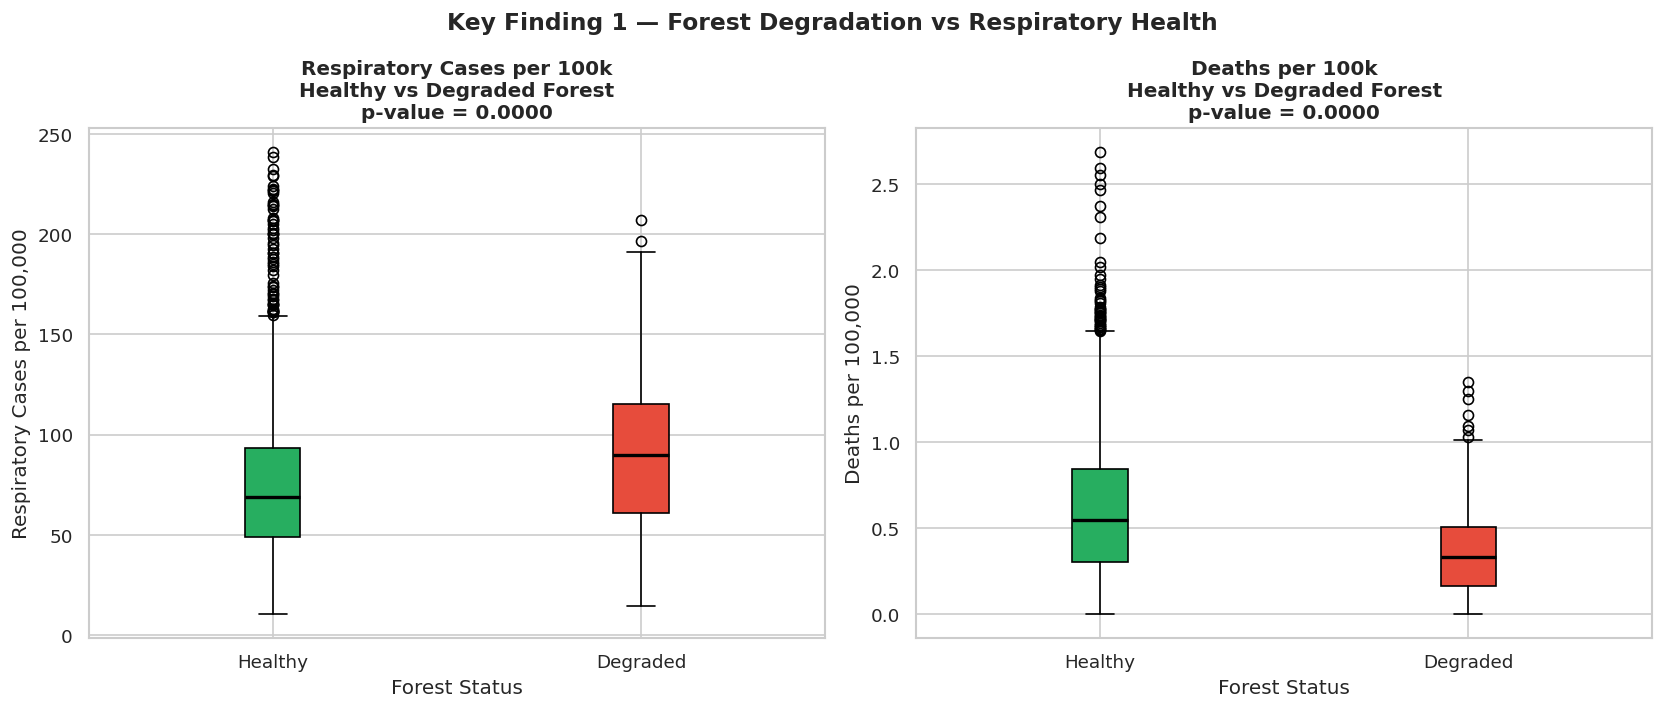

✅ Chart 1 done — Boxplot healthy vs degraded forest


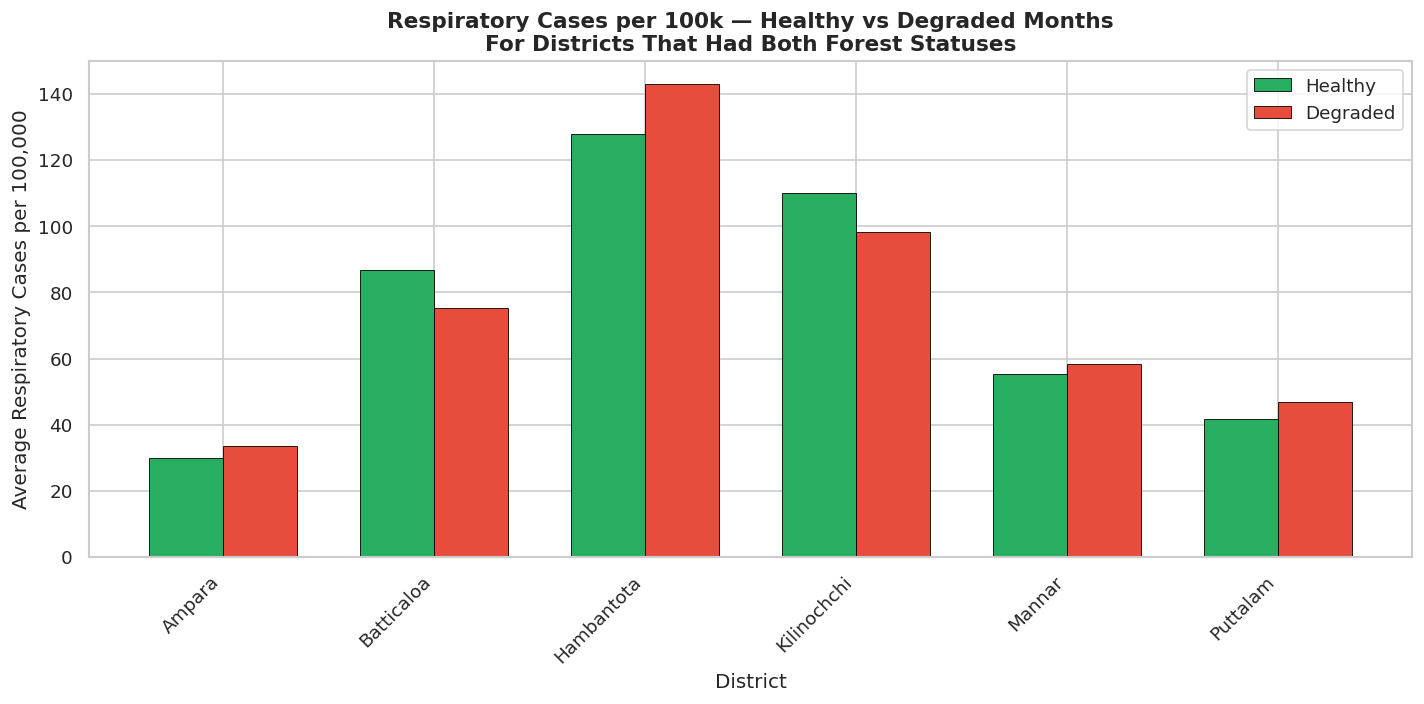

✅ Chart 2 done — Healthy vs degraded per district


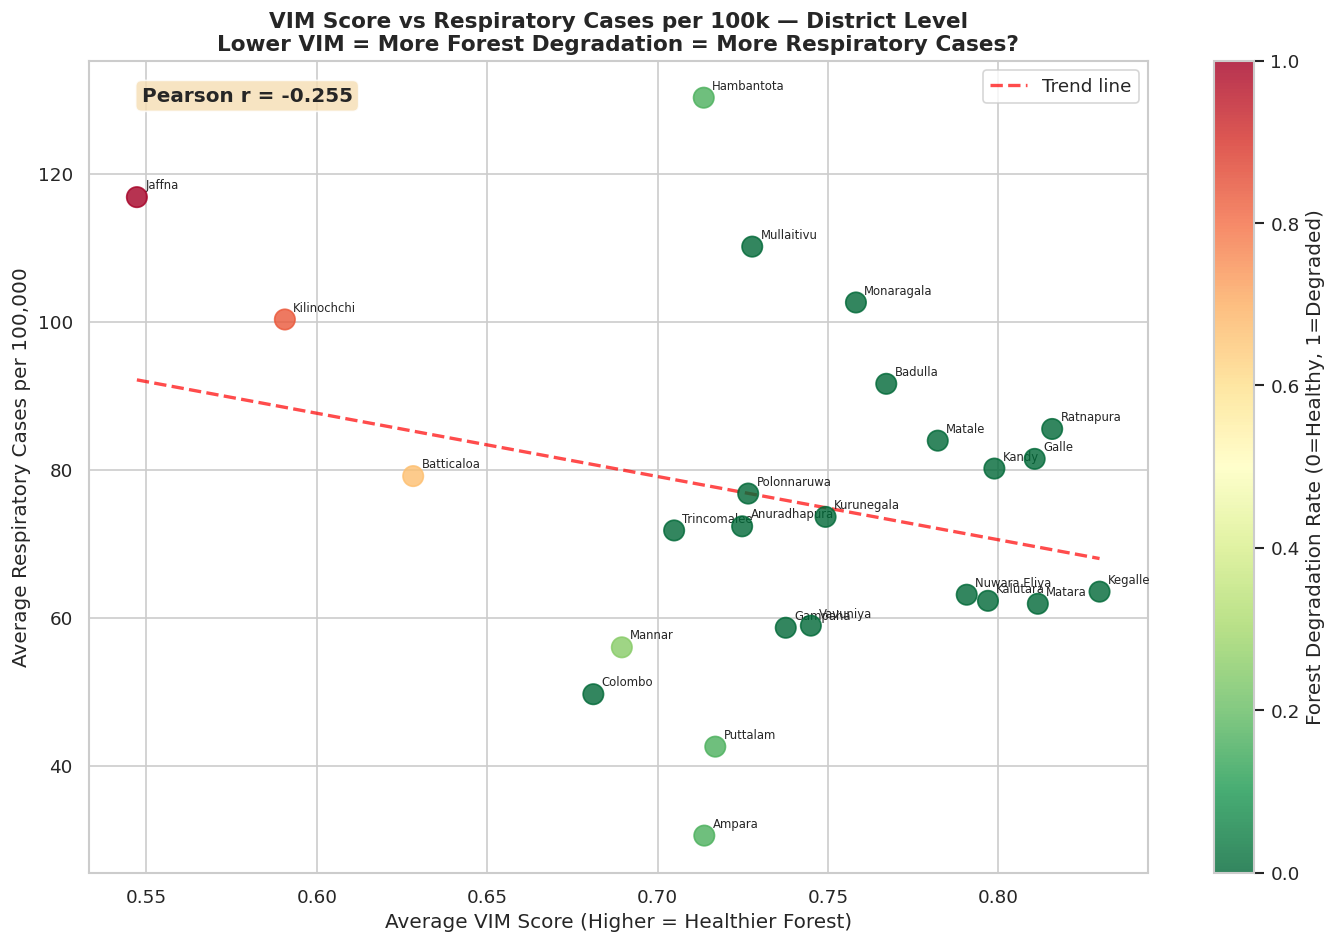

✅ Chart 3 done — VIM vs respiratory scatter (r = -0.255)


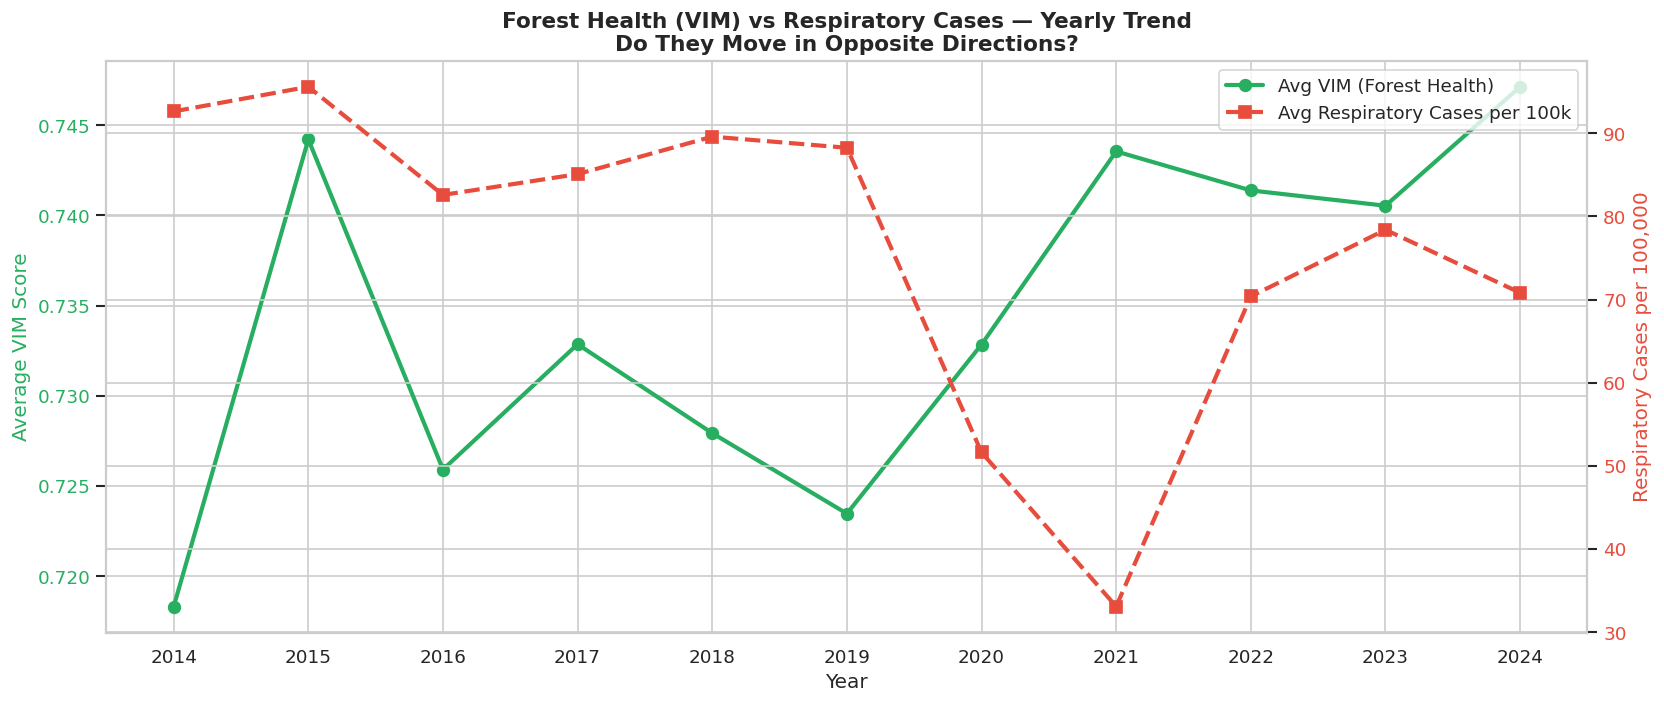

✅ Chart 4 done — VIM vs respiratory yearly overlay

📊 Key Finding 1 Summary For Short Paper:
   Healthy forest months avg   : 73.73 respiratory cases per 100k
   Degraded forest months avg  : 92.56 respiratory cases per 100k
   Difference                  : +18.83 cases in degraded months
   T-test p-value              : 0.000000
   Statistically significant   : YES ✅
   VIM vs Resp correlation     : -0.255

✅ Step 12 Complete — Forest degradation vs respiratory health done


In [47]:
# split into healthy and degraded groups
healthy = df[df['forest_status'] == 'Healthy']['respiratory_cases_per_100k']
degraded = df[df['forest_status'] == 'Degraded']['respiratory_cases_per_100k']

# run T-test
t_stat, p_value = stats.ttest_ind(healthy, degraded)

print(f"\n📊 T-Test Results — Healthy vs Degraded Forest:")
print(f"   Healthy forest avg   : {healthy.mean():.2f} cases per 100k")
print(f"   Degraded forest avg  : {degraded.mean():.2f} cases per 100k")
print(f"   Difference           : {degraded.mean() - healthy.mean():.2f} cases per 100k")
print(f"   T-statistic          : {t_stat:.4f}")
print(f"   P-value              : {p_value:.6f}")
if p_value < 0.05:
    print(f"   ✅ SIGNIFICANT — Degraded forests ARE linked to higher respiratory cases")
else:
    print(f"   ❌ NOT significant at 0.05 level")

# ── Chart 1: Boxplot healthy vs degraded ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# respiratory cases boxplot
data_to_plot = [healthy.values, degraded.values]
bp = axes[0].boxplot(data_to_plot, patch_artist=True,
                     labels=['Healthy', 'Degraded'],
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#27ae60')  # green for healthy
bp['boxes'][1].set_facecolor('#e74c3c')  # red for degraded
axes[0].set_title(f'Respiratory Cases per 100k\nHealthy vs Degraded Forest\np-value = {p_value:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Respiratory Cases per 100,000')
axes[0].set_xlabel('Forest Status')

# deaths boxplot
healthy_d = df[df['forest_status'] == 'Healthy']['deaths_per_100k']
degraded_d = df[df['forest_status'] == 'Degraded']['deaths_per_100k']
t_stat_d, p_value_d = stats.ttest_ind(healthy_d, degraded_d)

data_to_plot2 = [healthy_d.values, degraded_d.values]
bp2 = axes[1].boxplot(data_to_plot2, patch_artist=True,
                      labels=['Healthy', 'Degraded'],
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#27ae60')
bp2['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title(f'Deaths per 100k\nHealthy vs Degraded Forest\np-value = {p_value_d:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Deaths per 100,000')
axes[1].set_xlabel('Forest Status')

plt.suptitle('Key Finding 1 — Forest Degradation vs Respiratory Health',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Boxplot healthy vs degraded forest")

# ── Chart 2: Avg respiratory cases healthy vs degraded ────
# only districts that had both healthy and degraded months
district_forest = df.groupby(['district', 'forest_status'])[
    'respiratory_cases_per_100k'].mean().unstack()
district_forest = district_forest.dropna()  # keep only districts with both statuses

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(district_forest.index))
width = 0.35
ax.bar(x - width/2, district_forest['Healthy'], width,
       label='Healthy', color='#27ae60', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, district_forest['Degraded'], width,
       label='Degraded', color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.set_title('Respiratory Cases per 100k — Healthy vs Degraded Months\nFor Districts That Had Both Forest Statuses',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average Respiratory Cases per 100,000')
ax.set_xticks(x)
ax.set_xticklabels(district_forest.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Healthy vs degraded per district")

# ── Chart 3: VIM vs respiratory cases scatter ─────────────
district_avg = df.groupby('district').agg(
    avg_vim=('vim', 'mean'),
    avg_resp=('respiratory_cases_per_100k', 'mean'),
    degraded_rate=('forest_degraded', 'mean')
)

fig, ax = plt.subplots(figsize=(12, 8))
# color dots by degradation rate
scatter = ax.scatter(district_avg['avg_vim'],
                     district_avg['avg_resp'],
                     c=district_avg['degraded_rate'],
                     cmap='RdYlGn_r', s=150, alpha=0.8, zorder=5)
plt.colorbar(scatter, ax=ax, label='Forest Degradation Rate (0=Healthy, 1=Degraded)')

# label each district
for idx, row in district_avg.iterrows():
    ax.annotate(idx, (row['avg_vim'], row['avg_resp']),
                fontsize=7, textcoords='offset points', xytext=(5, 5))

# add trend line
z = np.polyfit(district_avg['avg_vim'], district_avg['avg_resp'], 1)
p = np.poly1d(z)
x_range = np.linspace(district_avg['avg_vim'].min(),
                       district_avg['avg_vim'].max(), 100)
ax.plot(x_range, p(x_range), color='red', linestyle='--',
        linewidth=2, alpha=0.7, label='Trend line')

# calculate correlation
corr_val = district_avg['avg_vim'].corr(district_avg['avg_resp'])
ax.text(0.05, 0.95, f'Pearson r = {corr_val:.3f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_title('VIM Score vs Respiratory Cases per 100k — District Level\nLower VIM = More Forest Degradation = More Respiratory Cases?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average VIM Score (Higher = Healthier Forest)')
ax.set_ylabel('Average Respiratory Cases per 100,000')
ax.legend()
plt.tight_layout()
plt.show()
print(f"✅ Chart 3 done — VIM vs respiratory scatter (r = {corr_val:.3f})")

# ── Chart 4: VIM trend vs respiratory trend overlay ───────
yearly = df.groupby('year').agg(
    avg_vim=('vim', 'mean'),
    avg_resp=('respiratory_cases_per_100k', 'mean')
)

fig, ax = plt.subplots(figsize=(14, 6))
# VIM on left axis
color_vim = '#27ae60'
ax.plot(yearly.index, yearly['avg_vim'], marker='o', linewidth=2.5,
        color=color_vim, markersize=7, label='Avg VIM (Forest Health)')
ax.set_xlabel('Year')
ax.set_ylabel('Average VIM Score', color=color_vim)
ax.tick_params(axis='y', labelcolor=color_vim)
ax.set_xticks(range(2014, 2025))

# respiratory on right axis
ax2 = ax.twinx()
color_resp = '#e74c3c'
ax2.plot(yearly.index, yearly['avg_resp'], marker='s', linewidth=2.5,
         color=color_resp, markersize=7, linestyle='--',
         label='Avg Respiratory Cases per 100k')
ax2.set_ylabel('Respiratory Cases per 100,000', color=color_resp)
ax2.tick_params(axis='y', labelcolor=color_resp)

ax.set_title('Forest Health (VIM) vs Respiratory Cases — Yearly Trend\nDo They Move in Opposite Directions?',
             fontsize=13, fontweight='bold')

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — VIM vs respiratory yearly overlay")

print("\n📊 Key Finding 1 Summary For Short Paper:")
print(f"   Healthy forest months avg   : {healthy.mean():.2f} respiratory cases per 100k")
print(f"   Degraded forest months avg  : {degraded.mean():.2f} respiratory cases per 100k")
print(f"   Difference                  : +{degraded.mean()-healthy.mean():.2f} cases in degraded months")
print(f"   T-test p-value              : {p_value:.6f}")
print(f"   Statistically significant   : {'YES ✅' if p_value < 0.05 else 'NO ❌'}")
print(f"   VIM vs Resp correlation     : {corr_val:.3f}")

print("\n✅ Step 12 Complete — Forest degradation vs respiratory health done")

Fire Hotspot vs Respiratory Health


📊 T-Test Results — Fire vs No-Fire Months:
   No fire months avg   : 77.01 cases per 100k
   Fire months avg      : 75.09 cases per 100k
   Difference           : -1.93 cases per 100k
   T-statistic          : -1.4934
   P-value              : 0.135430
   ❌ NOT significant at 0.05 level


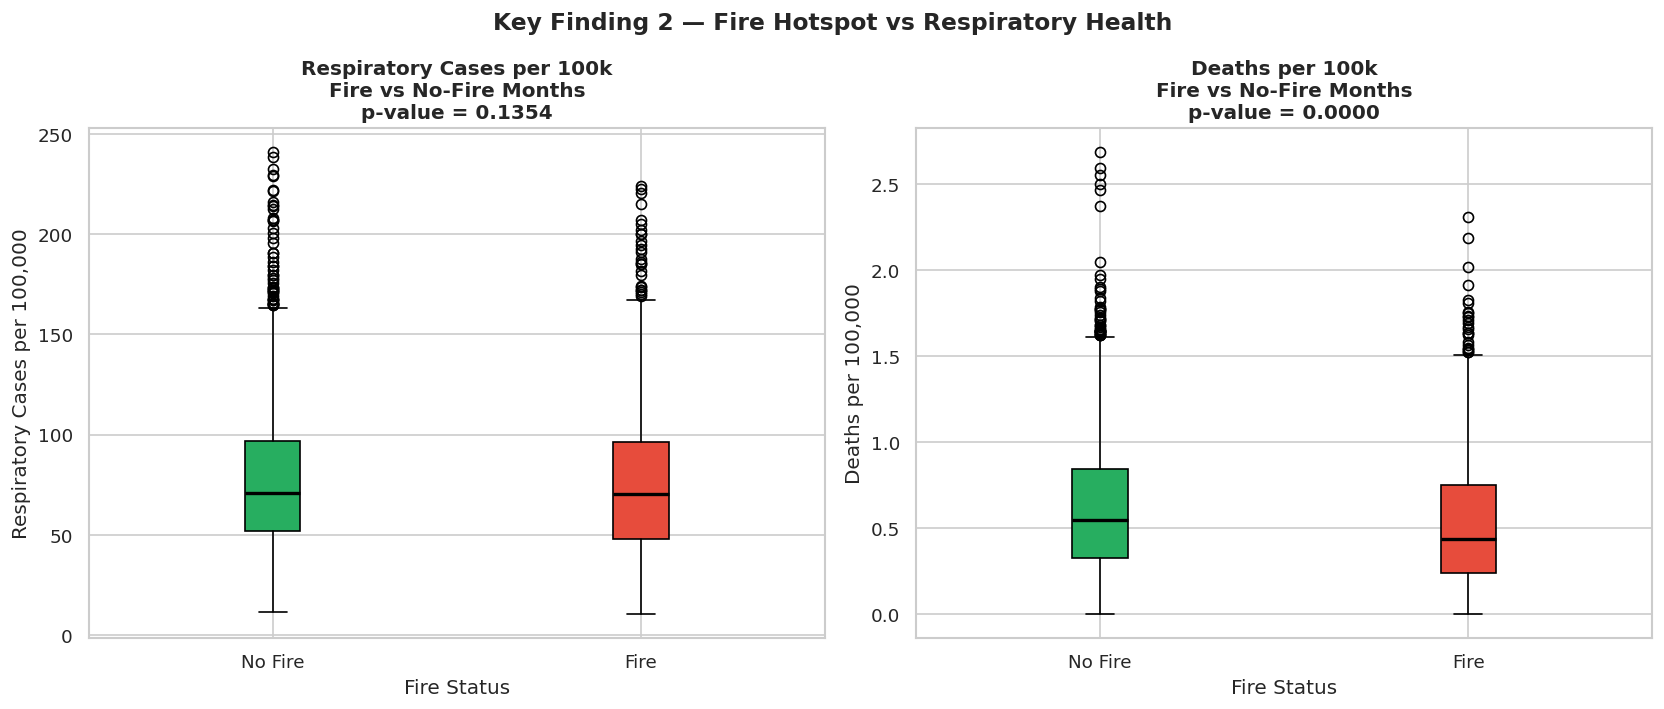

✅ Chart 1 done — Boxplot fire vs no-fire months


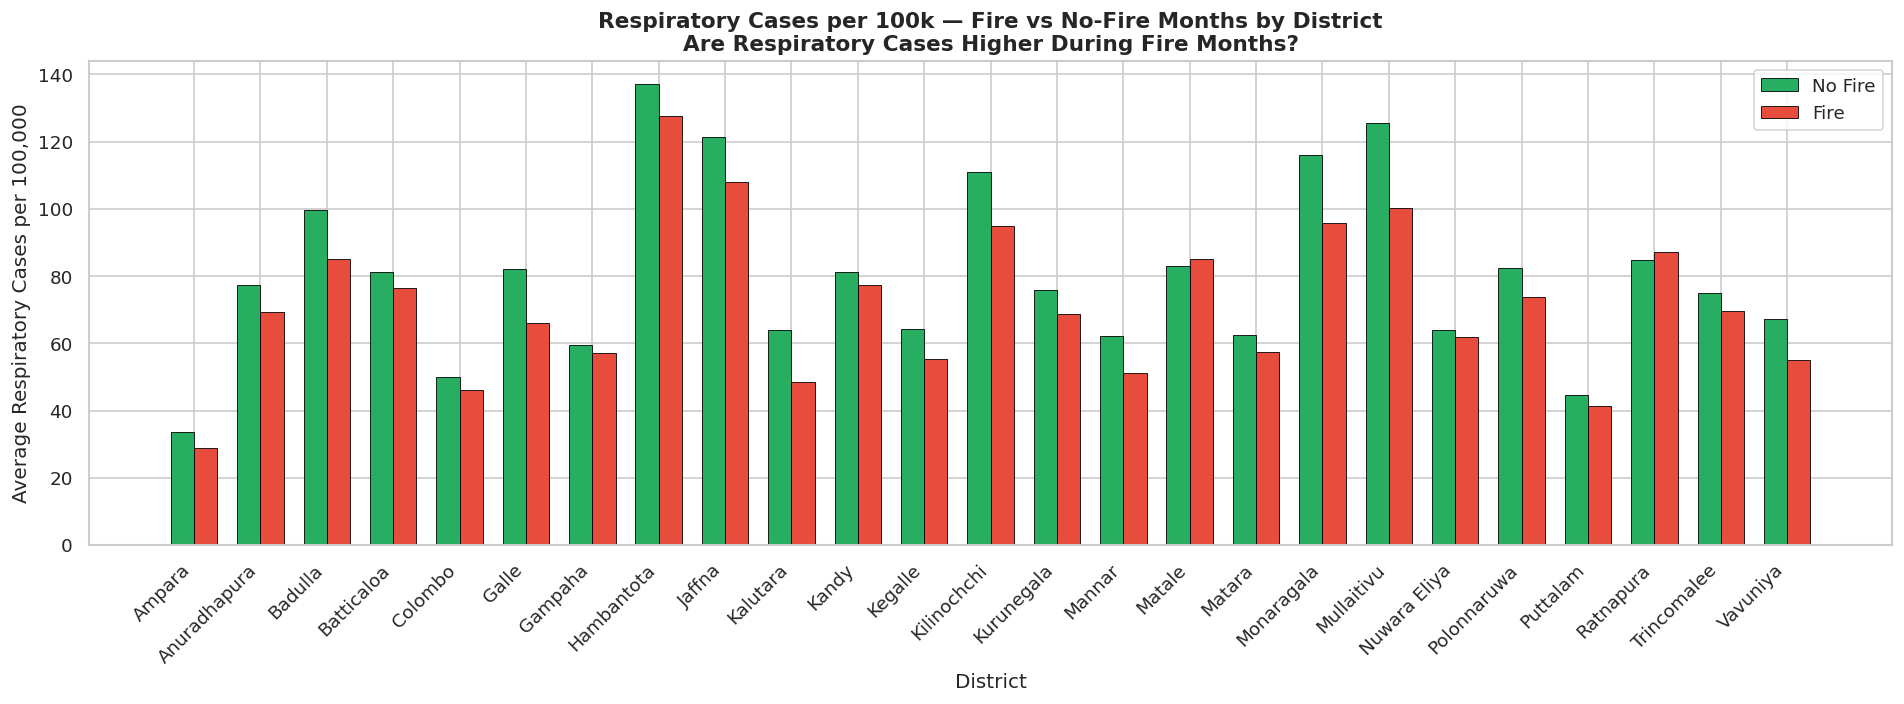

✅ Chart 2 done — Fire vs no-fire per district


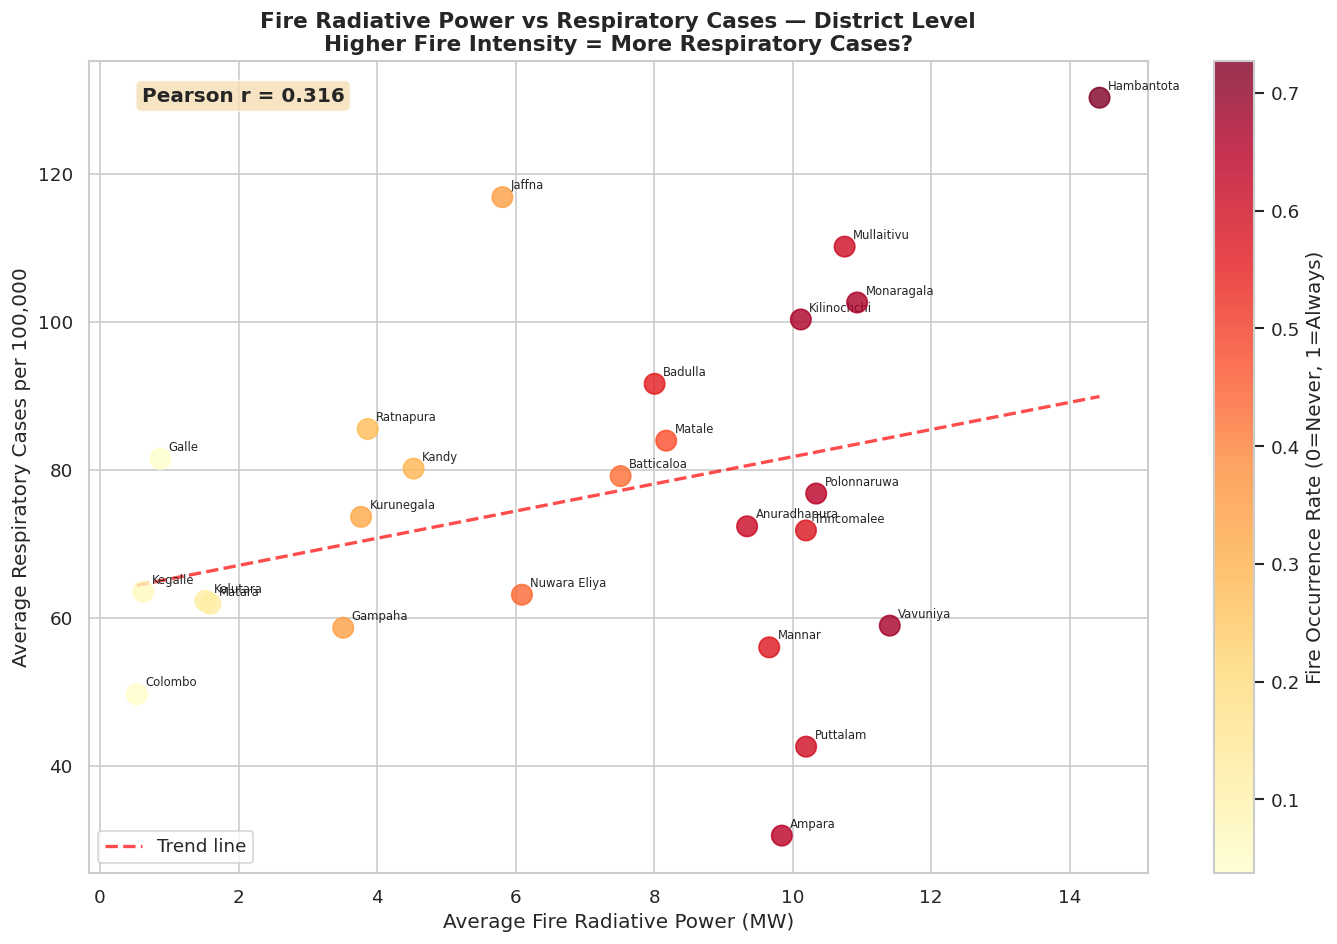

✅ Chart 3 done — FRP vs respiratory scatter (r = 0.316)


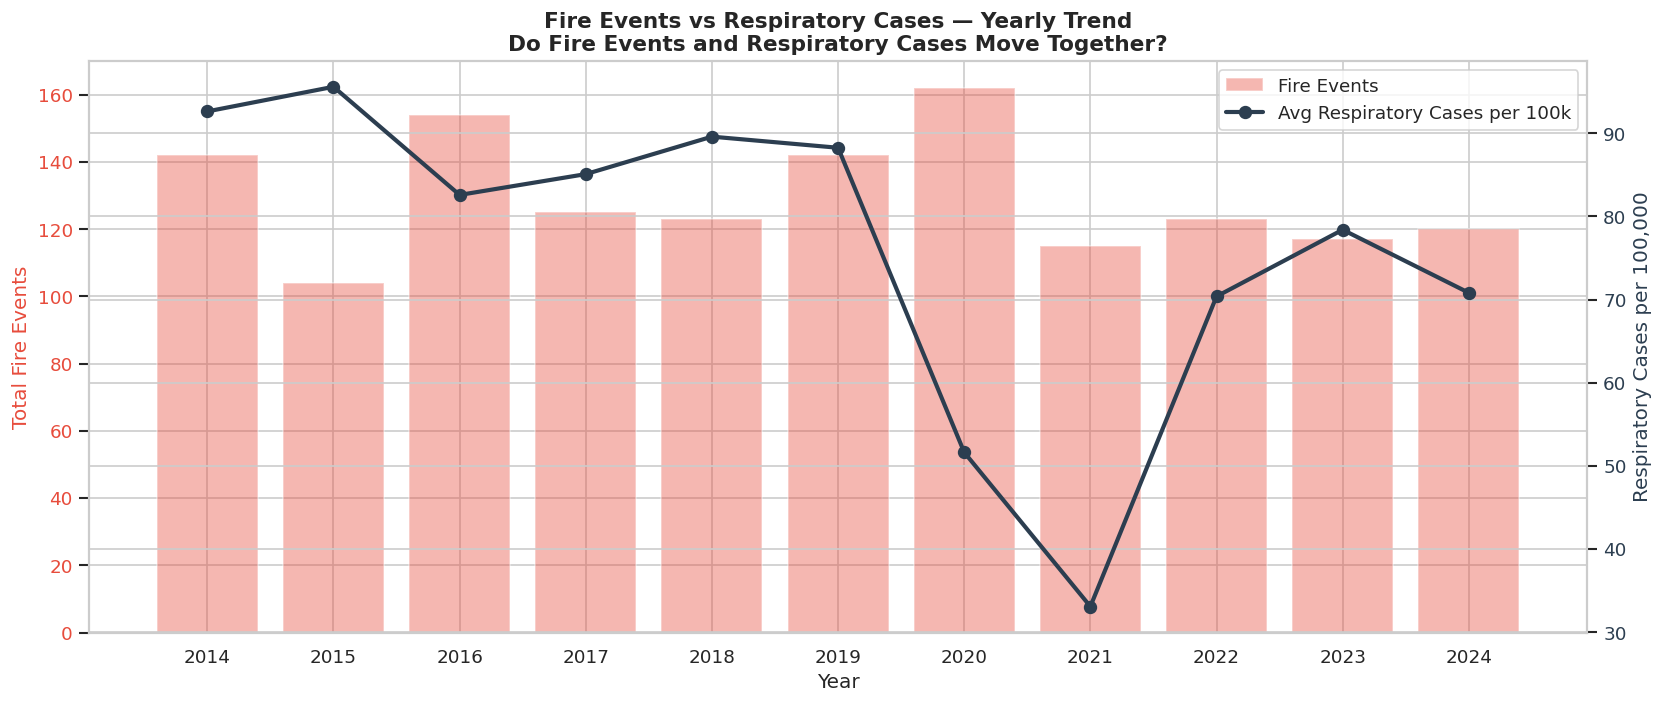

✅ Chart 4 done — Fire vs respiratory yearly overlay

📊 Key Finding 2 Summary For Short Paper:
   No fire months avg   : 77.01 respiratory cases per 100k
   Fire months avg      : 75.09 respiratory cases per 100k
   Difference           : -1.93 cases per 100k
   T-test p-value       : 0.135430
   Statistically significant : NO ❌
   FRP vs Resp correlation   : 0.316

✅ Step 13 Complete — Fire hotspot vs respiratory health done


In [49]:
# split into fire and no-fire months
fire_months = df[df['fire_occurred'] == 1]['respiratory_cases_per_100k']
no_fire_months = df[df['fire_occurred'] == 0]['respiratory_cases_per_100k']

# run T-test
t_stat, p_value = stats.ttest_ind(fire_months, no_fire_months)

print(f"\n📊 T-Test Results — Fire vs No-Fire Months:")
print(f"   No fire months avg   : {no_fire_months.mean():.2f} cases per 100k")
print(f"   Fire months avg      : {fire_months.mean():.2f} cases per 100k")
print(f"   Difference           : {fire_months.mean() - no_fire_months.mean():.2f} cases per 100k")
print(f"   T-statistic          : {t_stat:.4f}")
print(f"   P-value              : {p_value:.6f}")
if p_value < 0.05:
    print(f"   ✅ SIGNIFICANT — Fire events ARE linked to respiratory cases")
else:
    print(f"   ❌ NOT significant at 0.05 level")

# ── Chart 1: Boxplot fire vs no-fire months ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# respiratory cases boxplot
data_to_plot = [no_fire_months.values, fire_months.values]
bp = axes[0].boxplot(data_to_plot, patch_artist=True,
                     labels=['No Fire', 'Fire'],
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#27ae60')  # green for no fire
bp['boxes'][1].set_facecolor('#e74c3c')  # red for fire
axes[0].set_title(f'Respiratory Cases per 100k\nFire vs No-Fire Months\np-value = {p_value:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Respiratory Cases per 100,000')
axes[0].set_xlabel('Fire Status')

# deaths boxplot
fire_deaths = df[df['fire_occurred'] == 1]['deaths_per_100k']
no_fire_deaths = df[df['fire_occurred'] == 0]['deaths_per_100k']
t_stat_d, p_value_d = stats.ttest_ind(fire_deaths, no_fire_deaths)

data_to_plot2 = [no_fire_deaths.values, fire_deaths.values]
bp2 = axes[1].boxplot(data_to_plot2, patch_artist=True,
                      labels=['No Fire', 'Fire'],
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#27ae60')
bp2['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title(f'Deaths per 100k\nFire vs No-Fire Months\np-value = {p_value_d:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Deaths per 100,000')
axes[1].set_xlabel('Fire Status')

plt.suptitle('Key Finding 2 — Fire Hotspot vs Respiratory Health',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Boxplot fire vs no-fire months")

# ── Chart 2: Fire vs no-fire per district ─────────────────
district_fire_health = df.groupby(['district', 'fire_occurred'])[
    'respiratory_cases_per_100k'].mean().unstack()
district_fire_health.columns = ['No Fire', 'Fire']

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(district_fire_health.index))
width = 0.35
ax.bar(x - width/2, district_fire_health['No Fire'], width,
       label='No Fire', color='#27ae60', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, district_fire_health['Fire'], width,
       label='Fire', color='#e74c3c', edgecolor='black', linewidth=0.5)
ax.set_title('Respiratory Cases per 100k — Fire vs No-Fire Months by District\nAre Respiratory Cases Higher During Fire Months?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Average Respiratory Cases per 100,000')
ax.set_xticks(x)
ax.set_xticklabels(district_fire_health.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Fire vs no-fire per district")

# ── Chart 3: Fire intensity vs respiratory scatter ─────────
district_frp = df.groupby('district').agg(
    avg_frp=('Fire Radiative Power', 'mean'),
    avg_resp=('respiratory_cases_per_100k', 'mean'),
    fire_rate=('fire_occurred', 'mean')
)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(district_frp['avg_frp'],
                     district_frp['avg_resp'],
                     c=district_frp['fire_rate'],
                     cmap='YlOrRd', s=150, alpha=0.8, zorder=5)
plt.colorbar(scatter, ax=ax, label='Fire Occurrence Rate (0=Never, 1=Always)')

# label each district
for idx, row in district_frp.iterrows():
    ax.annotate(idx, (row['avg_frp'], row['avg_resp']),
                fontsize=7, textcoords='offset points', xytext=(5, 5))

# add trend line
z = np.polyfit(district_frp['avg_frp'], district_frp['avg_resp'], 1)
p = np.poly1d(z)
x_range = np.linspace(district_frp['avg_frp'].min(),
                       district_frp['avg_frp'].max(), 100)
ax.plot(x_range, p(x_range), color='red', linestyle='--',
        linewidth=2, alpha=0.7, label='Trend line')

# correlation value
corr_val = district_frp['avg_frp'].corr(district_frp['avg_resp'])
ax.text(0.05, 0.95, f'Pearson r = {corr_val:.3f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_title('Fire Radiative Power vs Respiratory Cases — District Level\nHigher Fire Intensity = More Respiratory Cases?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Fire Radiative Power (MW)')
ax.set_ylabel('Average Respiratory Cases per 100,000')
ax.legend()
plt.tight_layout()
plt.show()
print(f"✅ Chart 3 done — FRP vs respiratory scatter (r = {corr_val:.3f})")

# ── Chart 4: Fire trend vs respiratory trend overlay ───────
yearly_fire_resp = df.groupby('year').agg(
    fire_events=('fire_occurred', 'sum'),
    avg_resp=('respiratory_cases_per_100k', 'mean')
)

fig, ax = plt.subplots(figsize=(14, 6))
# fire events on left axis
color_fire = '#e74c3c'
ax.bar(yearly_fire_resp.index, yearly_fire_resp['fire_events'],
       color=color_fire, alpha=0.4, label='Fire Events')
ax.set_xlabel('Year')
ax.set_ylabel('Total Fire Events', color=color_fire)
ax.tick_params(axis='y', labelcolor=color_fire)
ax.set_xticks(range(2014, 2025))

# respiratory on right axis
ax2 = ax.twinx()
color_resp = '#2c3e50'
ax2.plot(yearly_fire_resp.index, yearly_fire_resp['avg_resp'],
         marker='o', linewidth=2.5, color=color_resp,
         markersize=7, label='Avg Respiratory Cases per 100k')
ax2.set_ylabel('Respiratory Cases per 100,000', color=color_resp)
ax2.tick_params(axis='y', labelcolor=color_resp)

ax.set_title('Fire Events vs Respiratory Cases — Yearly Trend\nDo Fire Events and Respiratory Cases Move Together?',
             fontsize=13, fontweight='bold')

# combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — Fire vs respiratory yearly overlay")

print("\n📊 Key Finding 2 Summary For Short Paper:")
print(f"   No fire months avg   : {no_fire_months.mean():.2f} respiratory cases per 100k")
print(f"   Fire months avg      : {fire_months.mean():.2f} respiratory cases per 100k")
print(f"   Difference           : {fire_months.mean()-no_fire_months.mean():.2f} cases per 100k")
print(f"   T-test p-value       : {p_value:.6f}")
print(f"   Statistically significant : {'YES ✅' if p_value < 0.05 else 'NO ❌'}")
print(f"   FRP vs Resp correlation   : {corr_val:.3f}")

print("\n✅ Step 13 Complete — Fire hotspot vs respiratory health done")

Air Quality vs Respiratory Health

══════════════════════════════════════════════════
STEP 14 — AIR QUALITY vs RESPIRATORY HEALTH
══════════════════════════════════════════════════

📊 T-Test Results — High NO2 vs Low NO2 Districts:
   NO2 median split value : 22.91 μg/m³
   Low NO2 avg resp       : 77.99 cases per 100k
   High NO2 avg resp      : 74.37 cases per 100k
   Difference             : -3.61 cases per 100k
   T-statistic            : -2.8294
   P-value                : 0.004691
   ✅ SIGNIFICANT — High NO2 IS linked to respiratory cases

📊 T-Test Results — High SO2 vs Low SO2 Districts:
   Low SO2 avg resp       : 77.35 cases per 100k
   High SO2 avg resp      : 75.01 cases per 100k
   Difference             : -2.34 cases per 100k
   P-value                : 0.067119
   ❌ NOT significant at 0.05 level


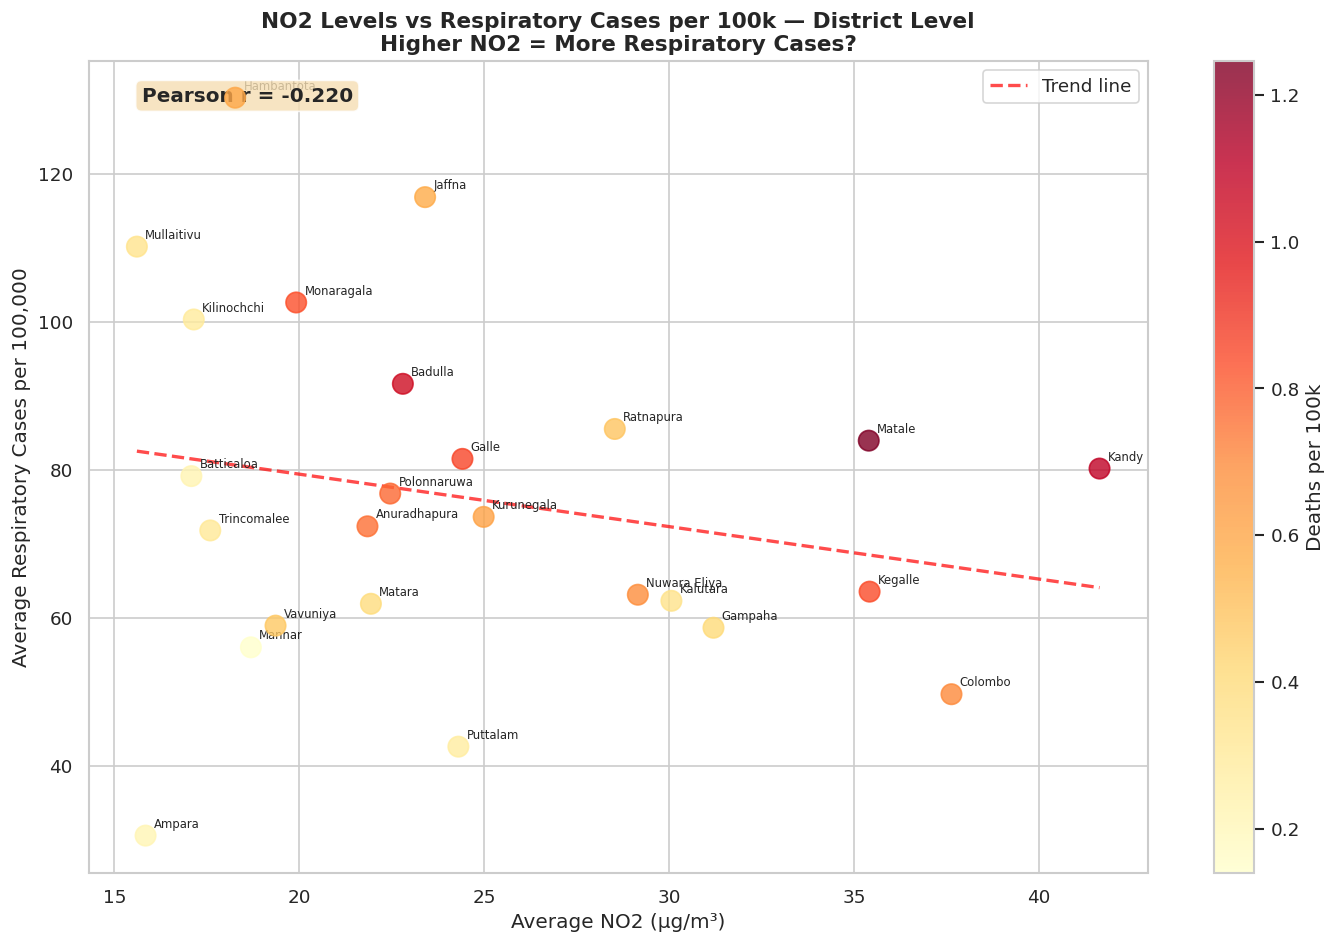

✅ Chart 1 done — NO2 vs respiratory scatter (r = -0.220)


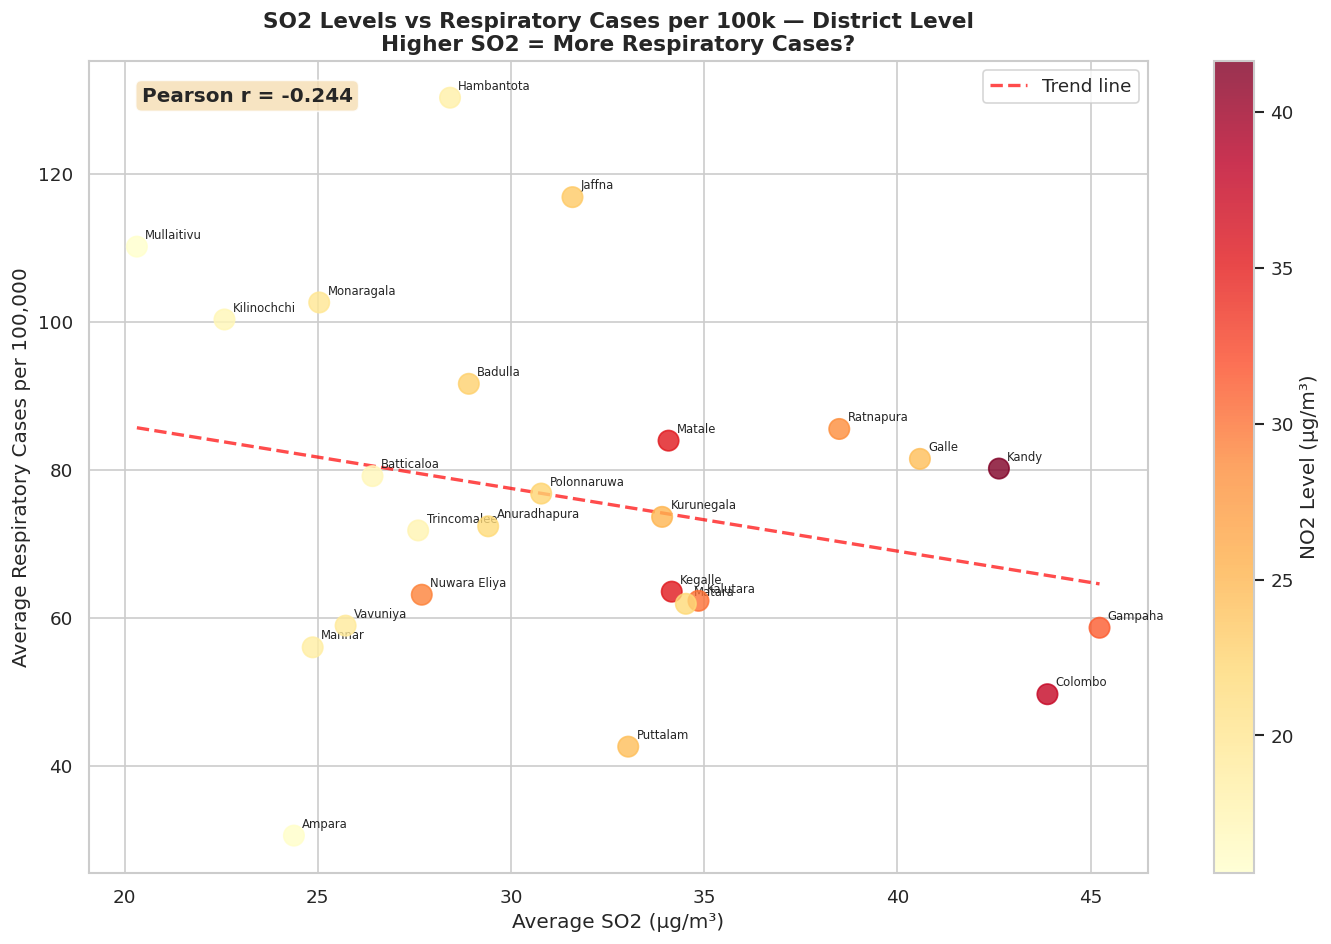

✅ Chart 2 done — SO2 vs respiratory scatter (r = -0.244)


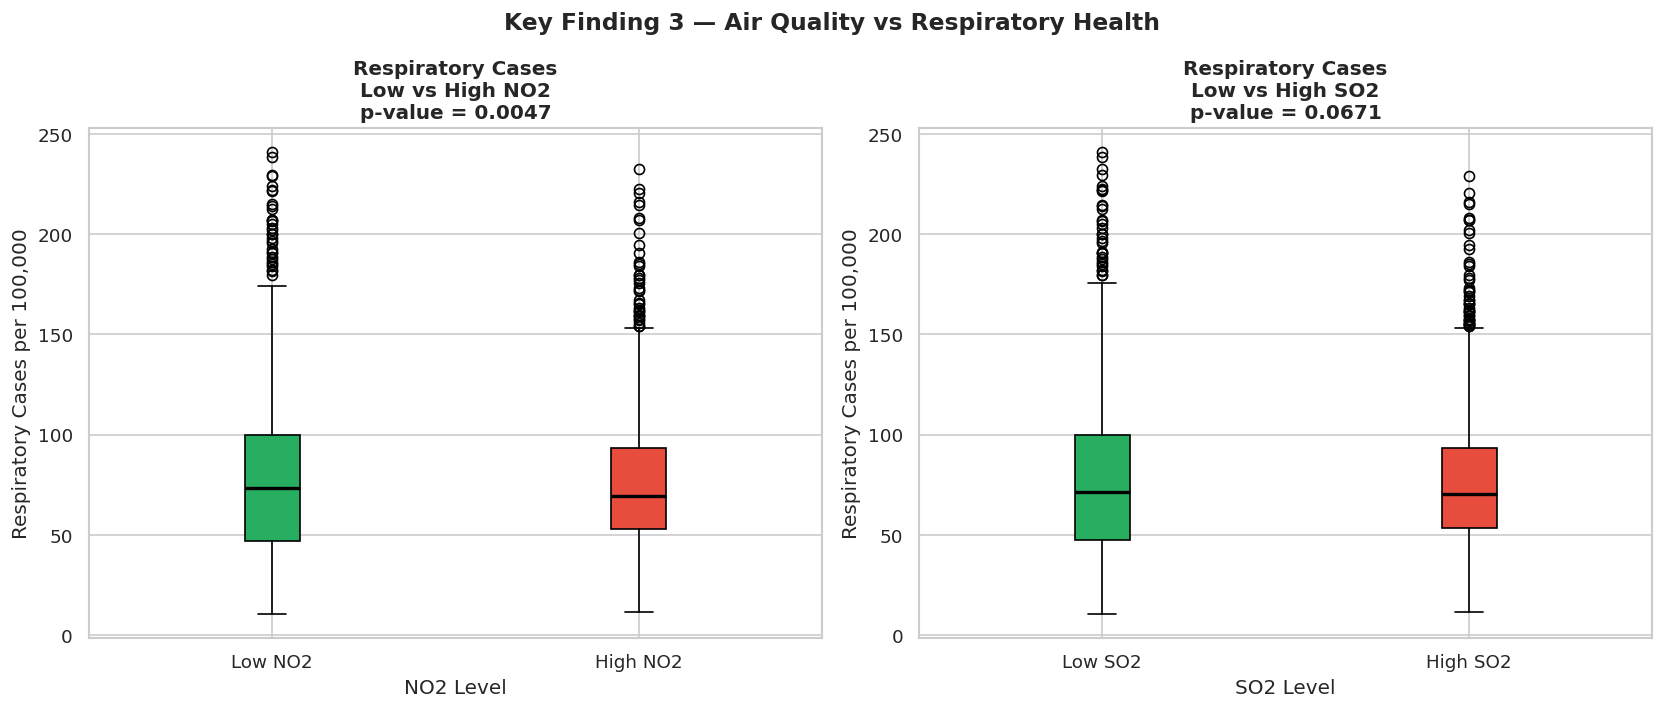

✅ Chart 3 done — Boxplot high vs low NO2 and SO2


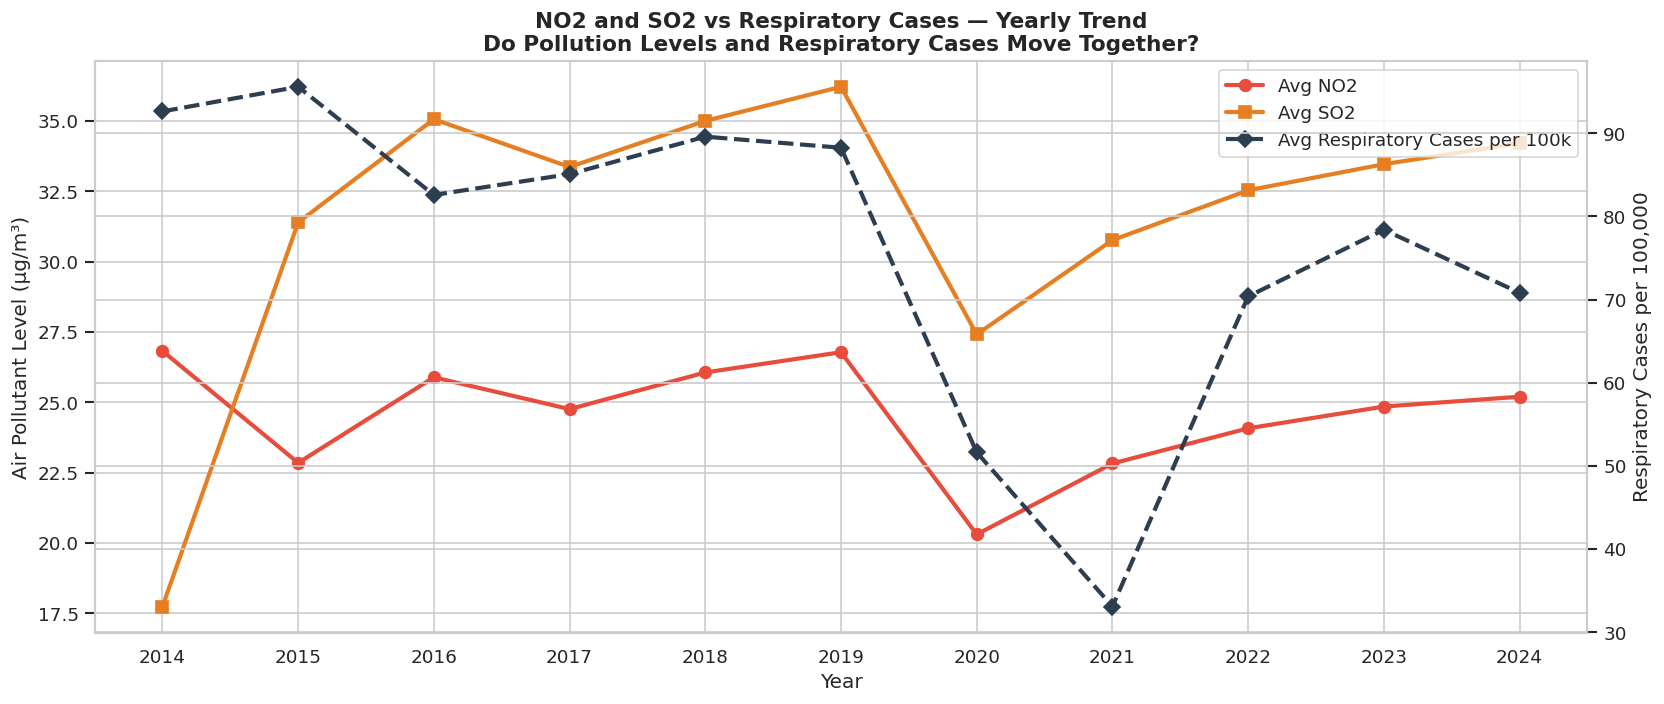

✅ Chart 4 done — NO2 SO2 vs respiratory yearly overlay

📊 Key Finding 3 Summary For Short Paper:
   High NO2 avg resp      : 74.37 per 100k
   Low NO2 avg resp       : 77.99 per 100k
   NO2 T-test p-value     : 0.004691 — ✅ Significant
   SO2 T-test p-value     : 0.067119 — ❌ Not significant
   NO2 vs Resp corr       : -0.220
   SO2 vs Resp corr       : -0.244
   NO2 vs Deaths corr     : 0.593 ← strongest death predictor

✅ Step 14 Complete — Air quality vs respiratory health done


In [51]:
print("═" * 50)
print("STEP 14 — AIR QUALITY vs RESPIRATORY HEALTH")
print("═" * 50)

# split by NO2 level — high vs low
no2_median = df['no2_ug_m3_avg'].median()
high_no2 = df[df['no2_ug_m3_avg'] > no2_median]['respiratory_cases_per_100k']
low_no2  = df[df['no2_ug_m3_avg'] <= no2_median]['respiratory_cases_per_100k']

# T-test NO2
t_stat_no2, p_value_no2 = stats.ttest_ind(high_no2, low_no2)

print(f"\n📊 T-Test Results — High NO2 vs Low NO2 Districts:")
print(f"   NO2 median split value : {no2_median:.2f} μg/m³")
print(f"   Low NO2 avg resp       : {low_no2.mean():.2f} cases per 100k")
print(f"   High NO2 avg resp      : {high_no2.mean():.2f} cases per 100k")
print(f"   Difference             : {high_no2.mean() - low_no2.mean():.2f} cases per 100k")
print(f"   T-statistic            : {t_stat_no2:.4f}")
print(f"   P-value                : {p_value_no2:.6f}")
if p_value_no2 < 0.05:
    print(f"   ✅ SIGNIFICANT — High NO2 IS linked to respiratory cases")
else:
    print(f"   ❌ NOT significant at 0.05 level")

# split by SO2 level — high vs low
so2_median = df['so2_ug_m3_avg'].median()
high_so2 = df[df['so2_ug_m3_avg'] > so2_median]['respiratory_cases_per_100k']
low_so2  = df[df['so2_ug_m3_avg'] <= so2_median]['respiratory_cases_per_100k']
t_stat_so2, p_value_so2 = stats.ttest_ind(high_so2, low_so2)

print(f"\n📊 T-Test Results — High SO2 vs Low SO2 Districts:")
print(f"   Low SO2 avg resp       : {low_so2.mean():.2f} cases per 100k")
print(f"   High SO2 avg resp      : {high_so2.mean():.2f} cases per 100k")
print(f"   Difference             : {high_so2.mean() - low_so2.mean():.2f} cases per 100k")
print(f"   P-value                : {p_value_so2:.6f}")
if p_value_so2 < 0.05:
    print(f"   ✅ SIGNIFICANT — High SO2 IS linked to respiratory cases")
else:
    print(f"   ❌ NOT significant at 0.05 level")

# district level summary
district_air_health = df.groupby('district').agg(
    avg_no2=('no2_ug_m3_avg', 'mean'),
    avg_so2=('so2_ug_m3_avg', 'mean'),
    avg_resp=('respiratory_cases_per_100k', 'mean'),
    avg_deaths=('deaths_per_100k', 'mean')
)

# ── Chart 1: NO2 vs respiratory cases scatter ─────────────
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(district_air_health['avg_no2'],
                     district_air_health['avg_resp'],
                     c=district_air_health['avg_deaths'],
                     cmap='YlOrRd', s=150, alpha=0.8, zorder=5)
plt.colorbar(scatter, ax=ax, label='Deaths per 100k')

# label each district
for idx, row in district_air_health.iterrows():
    ax.annotate(idx, (row['avg_no2'], row['avg_resp']),
                fontsize=7, textcoords='offset points', xytext=(5, 5))

# trend line
z = np.polyfit(district_air_health['avg_no2'],
               district_air_health['avg_resp'], 1)
p_line = np.poly1d(z)
x_range = np.linspace(district_air_health['avg_no2'].min(),
                       district_air_health['avg_no2'].max(), 100)
ax.plot(x_range, p_line(x_range), color='red', linestyle='--',
        linewidth=2, alpha=0.7, label='Trend line')

corr_no2_resp = district_air_health['avg_no2'].corr(district_air_health['avg_resp'])
ax.text(0.05, 0.95, f'Pearson r = {corr_no2_resp:.3f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_title('NO2 Levels vs Respiratory Cases per 100k — District Level\nHigher NO2 = More Respiratory Cases?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average NO2 (μg/m³)')
ax.set_ylabel('Average Respiratory Cases per 100,000')
ax.legend()
plt.tight_layout()
plt.show()
print(f"✅ Chart 1 done — NO2 vs respiratory scatter (r = {corr_no2_resp:.3f})")

# ── Chart 2: SO2 vs respiratory cases scatter ─────────────
fig, ax = plt.subplots(figsize=(12, 8))
scatter2 = ax.scatter(district_air_health['avg_so2'],
                      district_air_health['avg_resp'],
                      c=district_air_health['avg_no2'],
                      cmap='YlOrRd', s=150, alpha=0.8, zorder=5)
plt.colorbar(scatter2, ax=ax, label='NO2 Level (μg/m³)')

for idx, row in district_air_health.iterrows():
    ax.annotate(idx, (row['avg_so2'], row['avg_resp']),
                fontsize=7, textcoords='offset points', xytext=(5, 5))

z2 = np.polyfit(district_air_health['avg_so2'],
                district_air_health['avg_resp'], 1)
p_line2 = np.poly1d(z2)
x_range2 = np.linspace(district_air_health['avg_so2'].min(),
                        district_air_health['avg_so2'].max(), 100)
ax.plot(x_range2, p_line2(x_range2), color='red', linestyle='--',
        linewidth=2, alpha=0.7, label='Trend line')

corr_so2_resp = district_air_health['avg_so2'].corr(district_air_health['avg_resp'])
ax.text(0.05, 0.95, f'Pearson r = {corr_so2_resp:.3f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_title('SO2 Levels vs Respiratory Cases per 100k — District Level\nHigher SO2 = More Respiratory Cases?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average SO2 (μg/m³)')
ax.set_ylabel('Average Respiratory Cases per 100,000')
ax.legend()
plt.tight_layout()
plt.show()
print(f"✅ Chart 2 done — SO2 vs respiratory scatter (r = {corr_so2_resp:.3f})")

# ── Chart 3: Boxplot high vs low NO2 respiratory cases ────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NO2 boxplot
data_no2 = [low_no2.values, high_no2.values]
bp = axes[0].boxplot(data_no2, patch_artist=True,
                     labels=['Low NO2', 'High NO2'],
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#27ae60')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title(f'Respiratory Cases\nLow vs High NO2\np-value = {p_value_no2:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Respiratory Cases per 100,000')
axes[0].set_xlabel('NO2 Level')

# SO2 boxplot
data_so2 = [low_so2.values, high_so2.values]
bp2 = axes[1].boxplot(data_so2, patch_artist=True,
                      labels=['Low SO2', 'High SO2'],
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#27ae60')
bp2['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title(f'Respiratory Cases\nLow vs High SO2\np-value = {p_value_so2:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Respiratory Cases per 100,000')
axes[1].set_xlabel('SO2 Level')

plt.suptitle('Key Finding 3 — Air Quality vs Respiratory Health',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — Boxplot high vs low NO2 and SO2")

# ── Chart 4: NO2 SO2 trend vs respiratory trend overlay ───
yearly_air_resp = df.groupby('year').agg(
    avg_no2=('no2_ug_m3_avg', 'mean'),
    avg_so2=('so2_ug_m3_avg', 'mean'),
    avg_resp=('respiratory_cases_per_100k', 'mean')
)

fig, ax = plt.subplots(figsize=(14, 6))
# NO2 and SO2 on left axis
ax.plot(yearly_air_resp.index, yearly_air_resp['avg_no2'],
        marker='o', linewidth=2.5, color='#e74c3c',
        markersize=7, label='Avg NO2')
ax.plot(yearly_air_resp.index, yearly_air_resp['avg_so2'],
        marker='s', linewidth=2.5, color='#e67e22',
        markersize=7, label='Avg SO2')
ax.set_xlabel('Year')
ax.set_ylabel('Air Pollutant Level (μg/m³)')
ax.set_xticks(range(2014, 2025))

# respiratory on right axis
ax2 = ax.twinx()
ax2.plot(yearly_air_resp.index, yearly_air_resp['avg_resp'],
         marker='D', linewidth=2.5, color='#2c3e50',
         markersize=7, linestyle='--',
         label='Avg Respiratory Cases per 100k')
ax2.set_ylabel('Respiratory Cases per 100,000')

ax.set_title('NO2 and SO2 vs Respiratory Cases — Yearly Trend\nDo Pollution Levels and Respiratory Cases Move Together?',
             fontsize=13, fontweight='bold')

# combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Chart 4 done — NO2 SO2 vs respiratory yearly overlay")

print("\n📊 Key Finding 3 Summary For Short Paper:")
print(f"   High NO2 avg resp      : {high_no2.mean():.2f} per 100k")
print(f"   Low NO2 avg resp       : {low_no2.mean():.2f} per 100k")
print(f"   NO2 T-test p-value     : {p_value_no2:.6f} — {'✅ Significant' if p_value_no2 < 0.05 else '❌ Not significant'}")
print(f"   SO2 T-test p-value     : {p_value_so2:.6f} — {'✅ Significant' if p_value_so2 < 0.05 else '❌ Not significant'}")
print(f"   NO2 vs Resp corr       : {corr_no2_resp:.3f}")
print(f"   SO2 vs Resp corr       : {corr_so2_resp:.3f}")
corr_no2_deaths = district_air_health['avg_no2'].corr(district_air_health['avg_deaths'])
print(f"   NO2 vs Deaths corr     : {corr_no2_deaths:.3f} ← strongest death predictor")

print("\n✅ Step 14 Complete — Air quality vs respiratory health done")

District Risk Ranking


📊 District Risk Rankings:
 rank     district      province  composite_risk  forest_risk  fire_risk  air_risk  health_risk
    1       Jaffna      Northern        0.616114     1.000000   0.409616  0.375952     0.678890
    2   Hambantota      Southern        0.567043     0.288904   1.000000  0.213716     0.765550
    3  Kilinochchi      Northern        0.547886     0.839806   0.800900  0.075050     0.475788
    4       Matale       Central        0.512389     0.084028   0.588108  0.656281     0.721140
    5        Kandy       Central        0.492934     0.054621   0.325034  0.947742     0.644338
    6  Polonnaruwa North Central        0.455751     0.182498   0.792401  0.341574     0.506532
    7   Monaragala           Uva        0.454204     0.126524   0.830148  0.177437     0.682706
    8      Badulla           Uva        0.439779     0.110774   0.642539  0.310567     0.695237
    9 Anuradhapura North Central        0.424080     0.185637   0.734533  0.302218     0.473932
   10   Batti

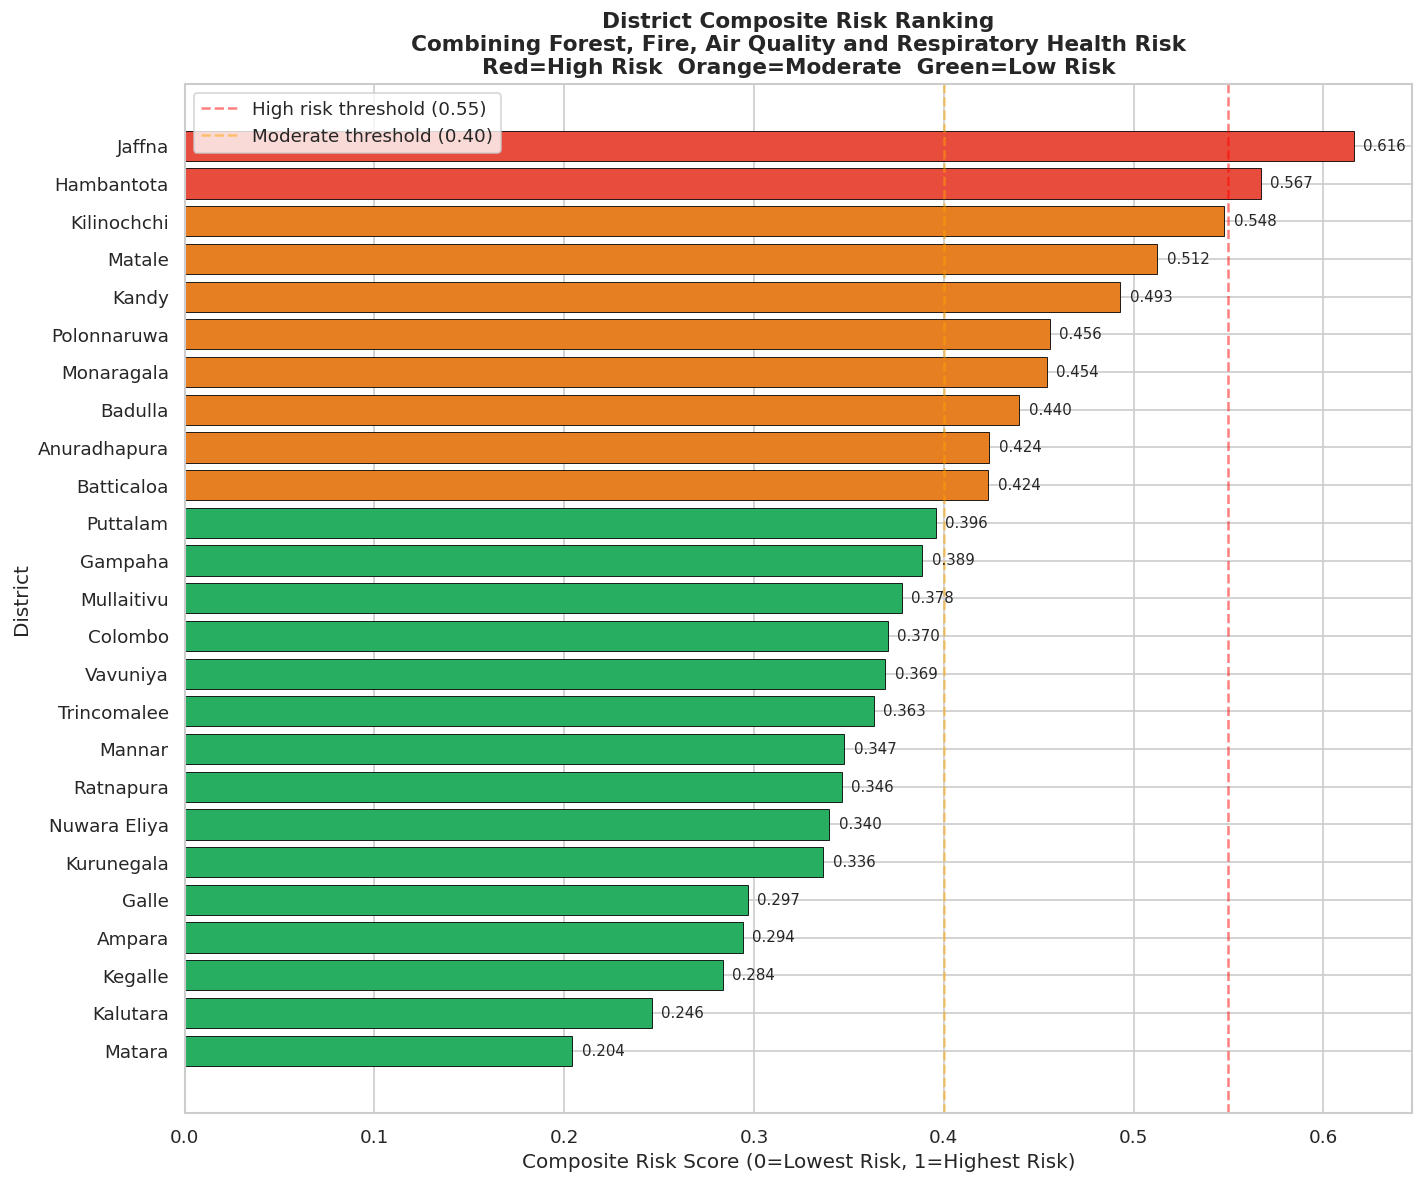

✅ Chart 1 done — Composite risk ranking


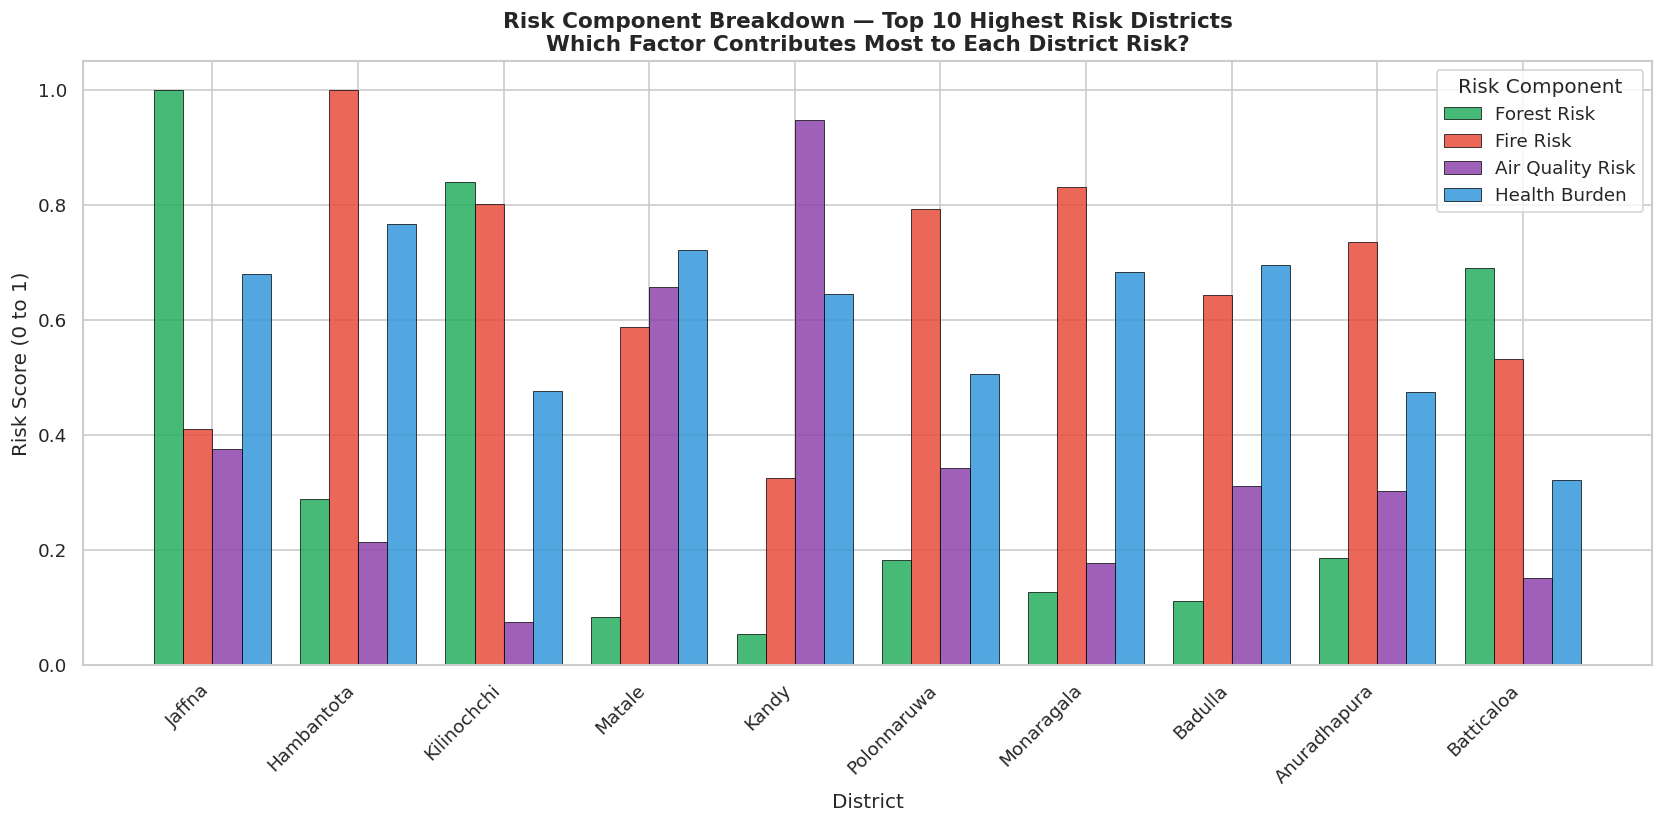

✅ Chart 2 done — Risk component breakdown top 10 districts


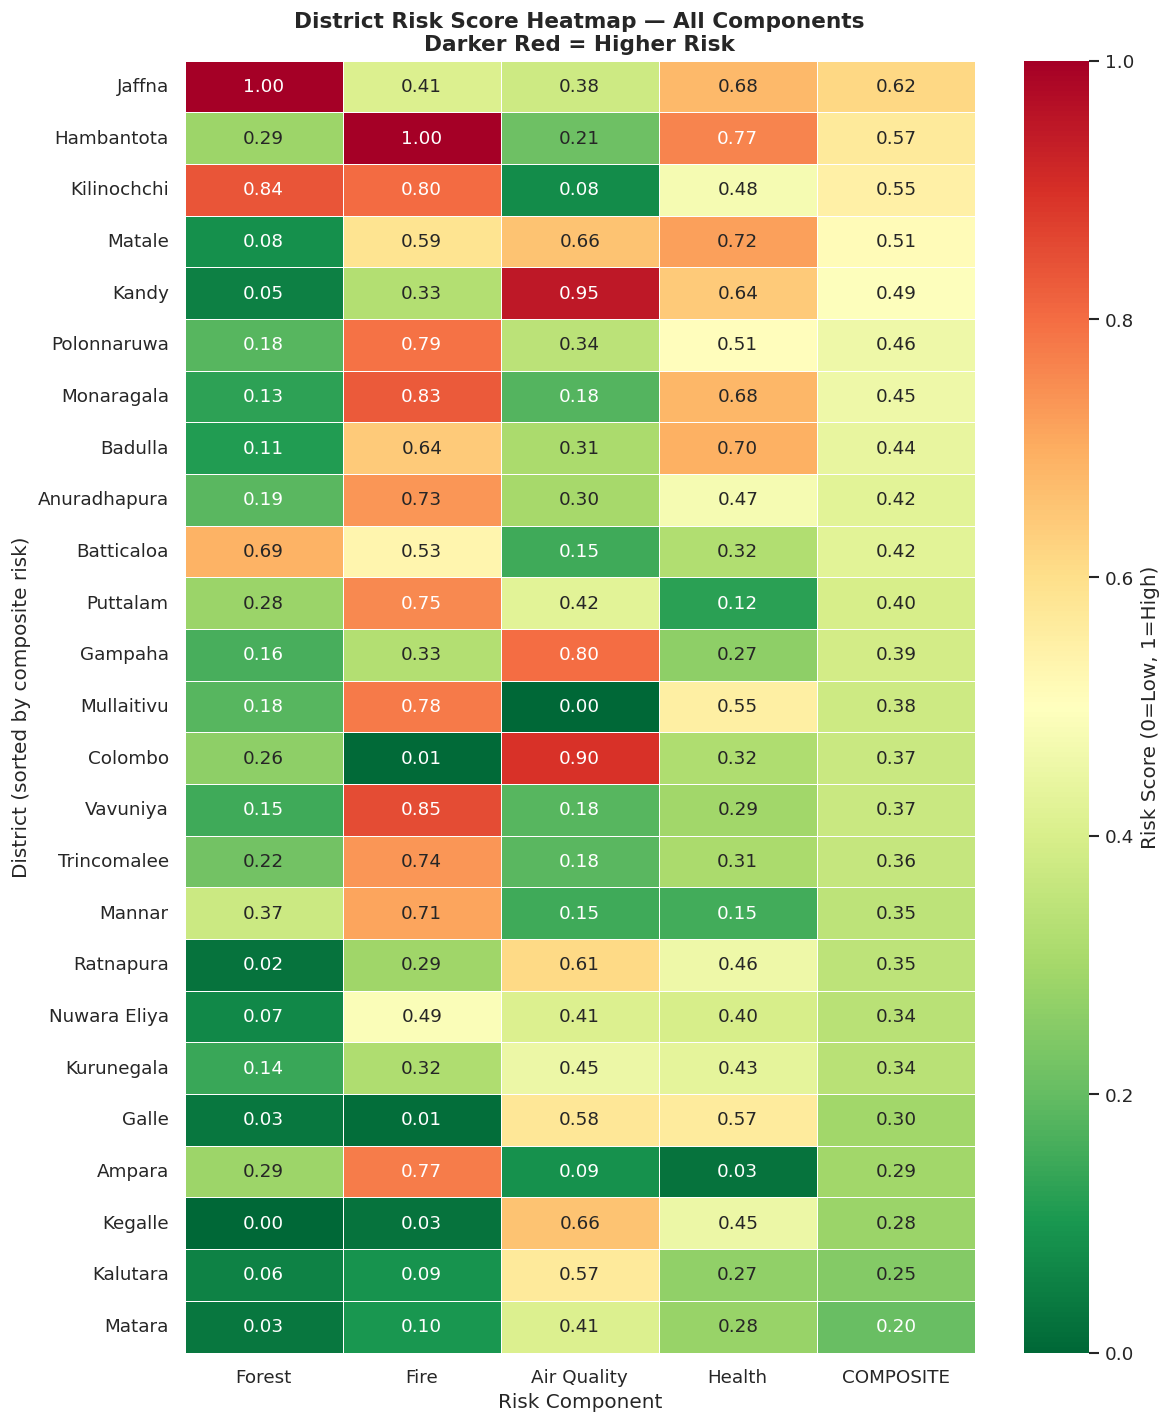

✅ Chart 3 done — Risk heatmap all components

📊 Final District Risk Summary For Short Paper:

🔴 HIGH RISK Districts (score > 0.55):
   #1 Jaffna (Northern) — Score: 0.616
   #2 Hambantota (Southern) — Score: 0.567

🟠 MODERATE RISK Districts (0.40 to 0.55):
   #3 Kilinochchi (Northern) — Score: 0.548
   #4 Matale (Central) — Score: 0.512
   #5 Kandy (Central) — Score: 0.493
   #6 Polonnaruwa (North Central) — Score: 0.456
   #7 Monaragala (Uva) — Score: 0.454
   #8 Badulla (Uva) — Score: 0.440
   #9 Anuradhapura (North Central) — Score: 0.424
   #10 Batticaloa (Eastern) — Score: 0.424

🟢 LOW RISK Districts (score < 0.40):
   #11 Puttalam (North Western) — Score: 0.396
   #12 Gampaha (Western) — Score: 0.389
   #13 Mullaitivu (Northern) — Score: 0.378
   #14 Colombo (Western) — Score: 0.370
   #15 Vavuniya (Northern) — Score: 0.369
   #16 Trincomalee (Eastern) — Score: 0.363
   #17 Mannar (Northern) — Score: 0.347
   #18 Ratnapura (Sabaragamuwa) — Score: 0.346
   #19 Nuwara Eliya (Centra

In [53]:
# build district level summary for risk scoring
risk_df = df.groupby('district').agg(
    province=('province', 'first'),
    avg_vim=('vim', 'mean'),
    degraded_rate=('forest_degraded', 'mean'),
    fire_rate=('fire_occurred', 'mean'),
    avg_frp=('Fire Radiative Power', 'mean'),
    avg_no2=('no2_ug_m3_avg', 'mean'),
    avg_so2=('so2_ug_m3_avg', 'mean'),
    avg_resp=('respiratory_cases_per_100k', 'mean'),
    avg_deaths=('deaths_per_100k', 'mean')
).reset_index()

scaler = MinMaxScaler()

# forest risk — degradation rate + inverted VIM
risk_df['forest_risk'] = (
    scaler.fit_transform(risk_df[['degraded_rate']]) * 0.5 +
    scaler.fit_transform(1 - risk_df[['avg_vim']]) * 0.5
)

# fire risk — occurrence rate + intensity
risk_df['fire_risk'] = (
    scaler.fit_transform(risk_df[['fire_rate']]) * 0.5 +
    scaler.fit_transform(risk_df[['avg_frp']]) * 0.5
)

# air quality risk — NO2 + SO2
risk_df['air_risk'] = (
    scaler.fit_transform(risk_df[['avg_no2']]) * 0.5 +
    scaler.fit_transform(risk_df[['avg_so2']]) * 0.5
)

# health burden — respiratory cases + deaths
risk_df['health_risk'] = (
    scaler.fit_transform(risk_df[['avg_resp']]) * 0.6 +
    scaler.fit_transform(risk_df[['avg_deaths']]) * 0.4
)

# composite risk — equal weight 25% each
risk_df['composite_risk'] = (
    risk_df['forest_risk'] * 0.25 +
    risk_df['fire_risk'] * 0.25 +
    risk_df['air_risk'] * 0.25 +
    risk_df['health_risk'] * 0.25
)

# sort by composite risk
risk_df = risk_df.sort_values('composite_risk', ascending=False).reset_index(drop=True)
risk_df['rank'] = risk_df.index + 1

print("\n📊 District Risk Rankings:")
print(risk_df[['rank','district','province','composite_risk',
               'forest_risk','fire_risk','air_risk','health_risk']].to_string(index=False))

# ── Chart 1: Composite risk ranking ───────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#e74c3c' if v > 0.55 else '#e67e22' if v > 0.40 else '#27ae60'
          for v in risk_df['composite_risk']]
bars = ax.barh(risk_df['district'], risk_df['composite_risk'],
               color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('District Composite Risk Ranking\nCombining Forest, Fire, Air Quality and Respiratory Health Risk\nRed=High Risk  Orange=Moderate  Green=Low Risk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Composite Risk Score (0=Lowest Risk, 1=Highest Risk)')
ax.set_ylabel('District')
ax.axvline(x=0.55, color='red', linestyle='--',
           alpha=0.5, label='High risk threshold (0.55)')
ax.axvline(x=0.40, color='orange', linestyle='--',
           alpha=0.5, label='Moderate threshold (0.40)')
# add score labels
for i, (v, d) in enumerate(zip(risk_df['composite_risk'], risk_df['district'])):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.legend()
ax.invert_yaxis()  # highest risk at top
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Composite risk ranking")

# ── Chart 2: Risk component breakdown per district ─────────
top10 = risk_df.head(10)
risk_components = ['forest_risk', 'fire_risk', 'air_risk', 'health_risk']
component_labels = ['Forest Risk', 'Fire Risk', 'Air Quality Risk', 'Health Burden']
colors_comp = ['#27ae60', '#e74c3c', '#8e44ad', '#3498db']

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top10['district']))
width = 0.2

for i, (col, label, color) in enumerate(zip(risk_components, component_labels, colors_comp)):
    ax.bar(x + i * width, top10[col], width,
           label=label, color=color, edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_title('Risk Component Breakdown — Top 10 Highest Risk Districts\nWhich Factor Contributes Most to Each District Risk?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('District')
ax.set_ylabel('Risk Score (0 to 1)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top10['district'], rotation=45, ha='right')
ax.legend(title='Risk Component')
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Risk component breakdown top 10 districts")

# ── Chart 3: Risk heatmap all components all districts ─────
risk_heatmap_data = risk_df.set_index('district')[
    ['forest_risk', 'fire_risk', 'air_risk', 'health_risk', 'composite_risk']]
risk_heatmap_data.columns = ['Forest', 'Fire', 'Air Quality', 'Health', 'COMPOSITE']

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(risk_heatmap_data, annot=True, fmt='.2f',
            cmap='RdYlGn_r', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Risk Score (0=Low, 1=High)'})
ax.set_title('District Risk Score Heatmap — All Components\nDarker Red = Higher Risk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Component')
ax.set_ylabel('District (sorted by composite risk)')
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — Risk heatmap all components")

print("\n📊 Final District Risk Summary For Short Paper:")
print(f"\n🔴 HIGH RISK Districts (score > 0.55):")
high = risk_df[risk_df['composite_risk'] > 0.55]
for _, row in high.iterrows():
    print(f"   #{int(row['rank'])} {row['district']} ({row['province']}) — Score: {row['composite_risk']:.3f}")

print(f"\n🟠 MODERATE RISK Districts (0.40 to 0.55):")
mod = risk_df[(risk_df['composite_risk'] >= 0.40) & (risk_df['composite_risk'] <= 0.55)]
for _, row in mod.iterrows():
    print(f"   #{int(row['rank'])} {row['district']} ({row['province']}) — Score: {row['composite_risk']:.3f}")

print(f"\n🟢 LOW RISK Districts (score < 0.40):")
low = risk_df[risk_df['composite_risk'] < 0.40]
for _, row in low.iterrows():
    print(f"   #{int(row['rank'])} {row['district']} ({row['province']}) — Score: {row['composite_risk']:.3f}")

print("\n✅ Step 15 Complete — District risk ranking done")

 Province-Wise Summary


📊 Province Summary Table:
               num_districts  avg_vim  degraded_rate  fire_rate  avg_frp  avg_no2  avg_so2  avg_resp  avg_deaths  total_fire_events  total_resp_cases
province                                                                                                                                             
Central                    3    0.791          0.000      0.396    6.264   35.393   34.799    75.765       1.012                157            275296
Eastern                    3    0.682          0.278      0.548    9.183   16.838   26.130    60.530       0.249                217            128176
North Central              2    0.726          0.000      0.629    9.841   22.148   30.094    74.599       0.764                166            132752
North Western              2    0.733          0.083      0.458    6.982   24.641   33.472    58.136       0.448                121            211656
Northern                   5    0.660          0.417      0.571    9.548 

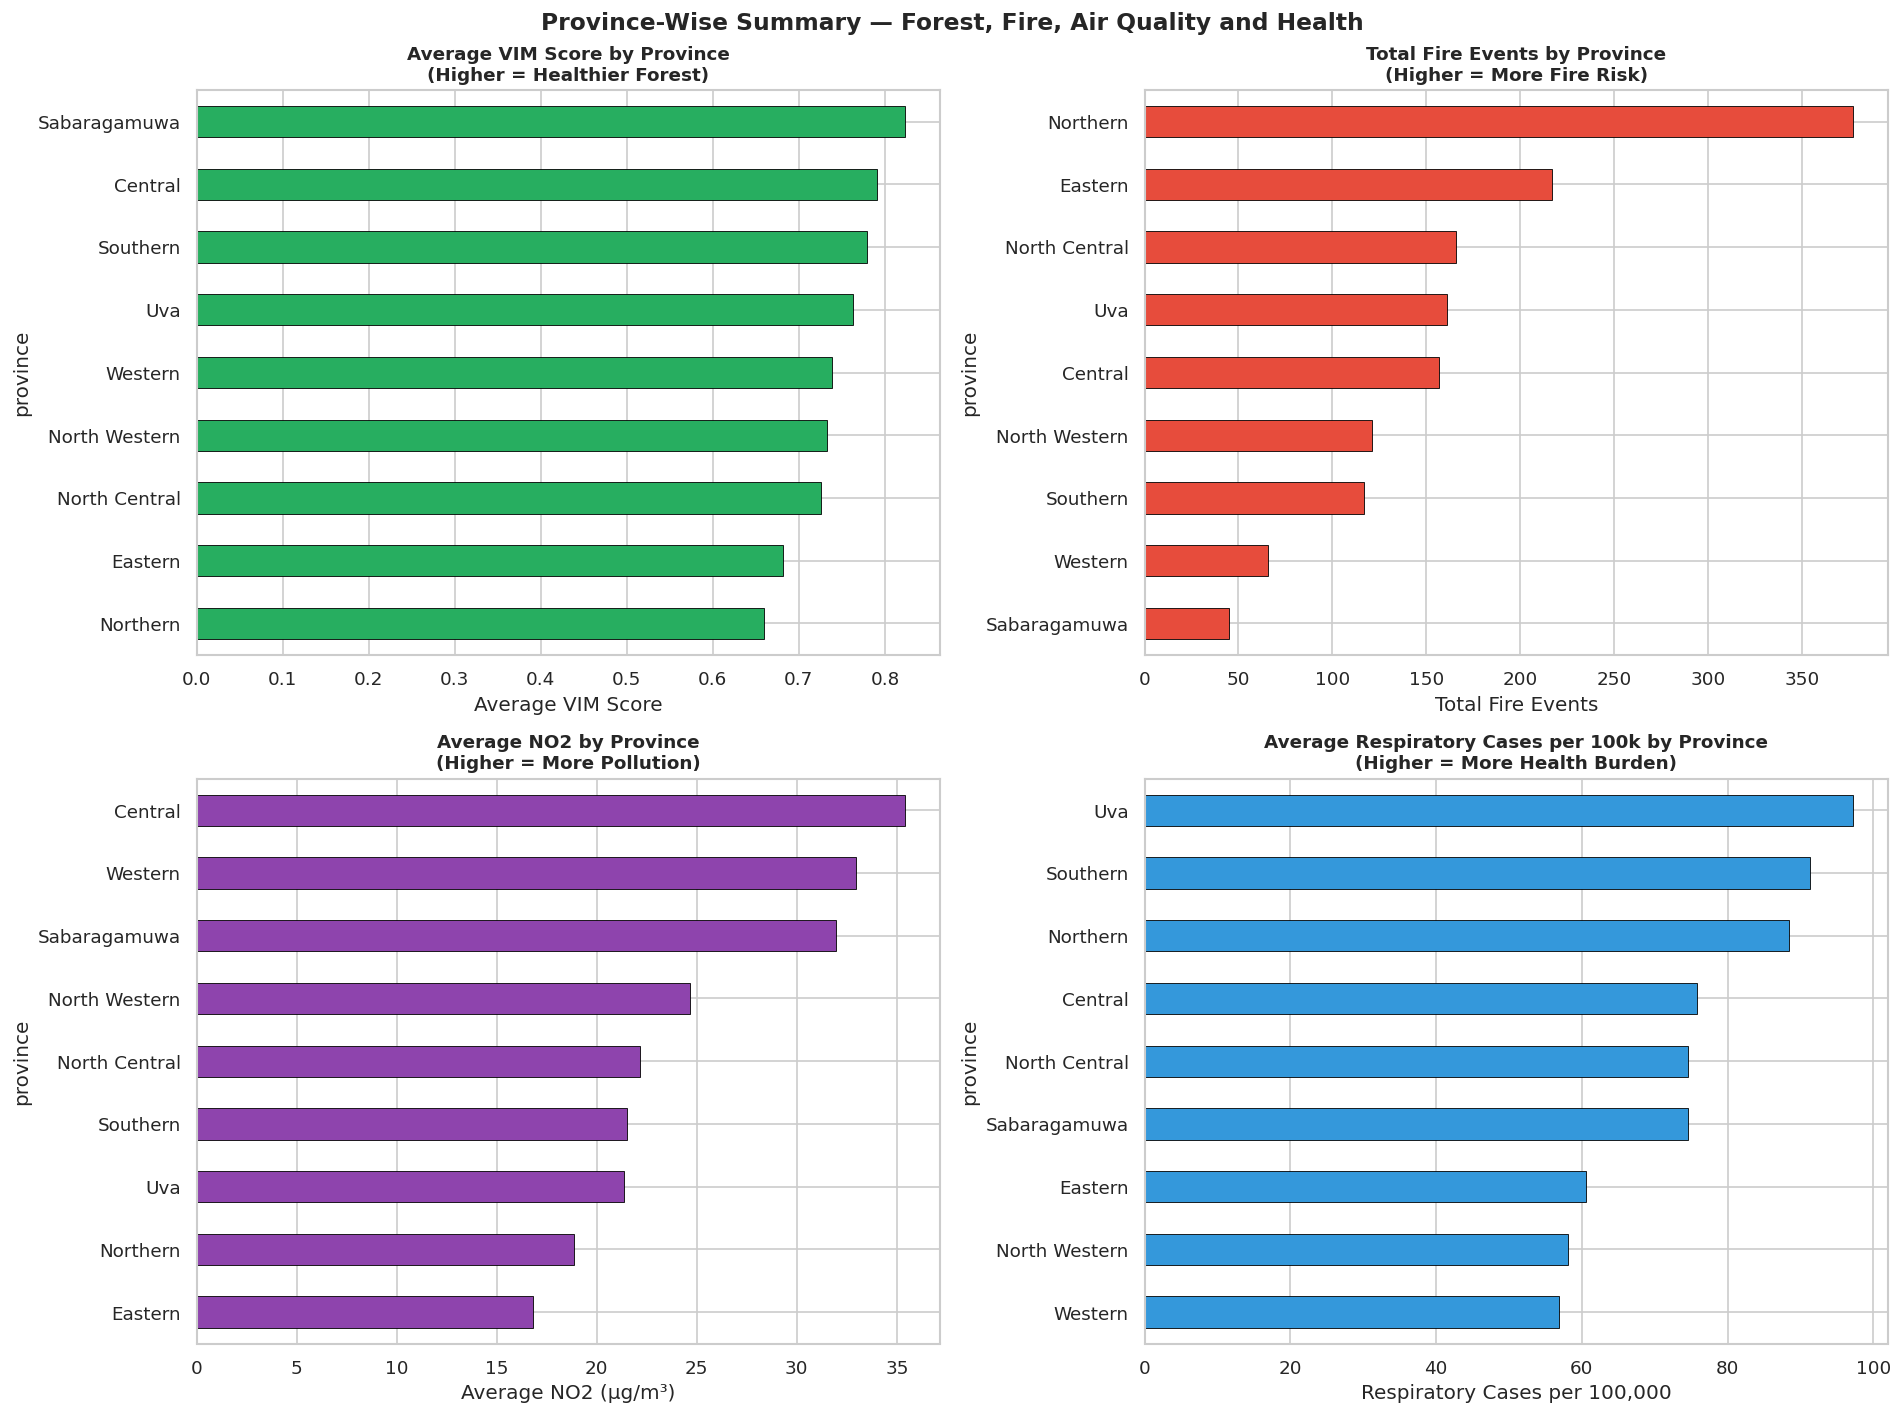

✅ Chart 1 done — Province comparison 4 metrics


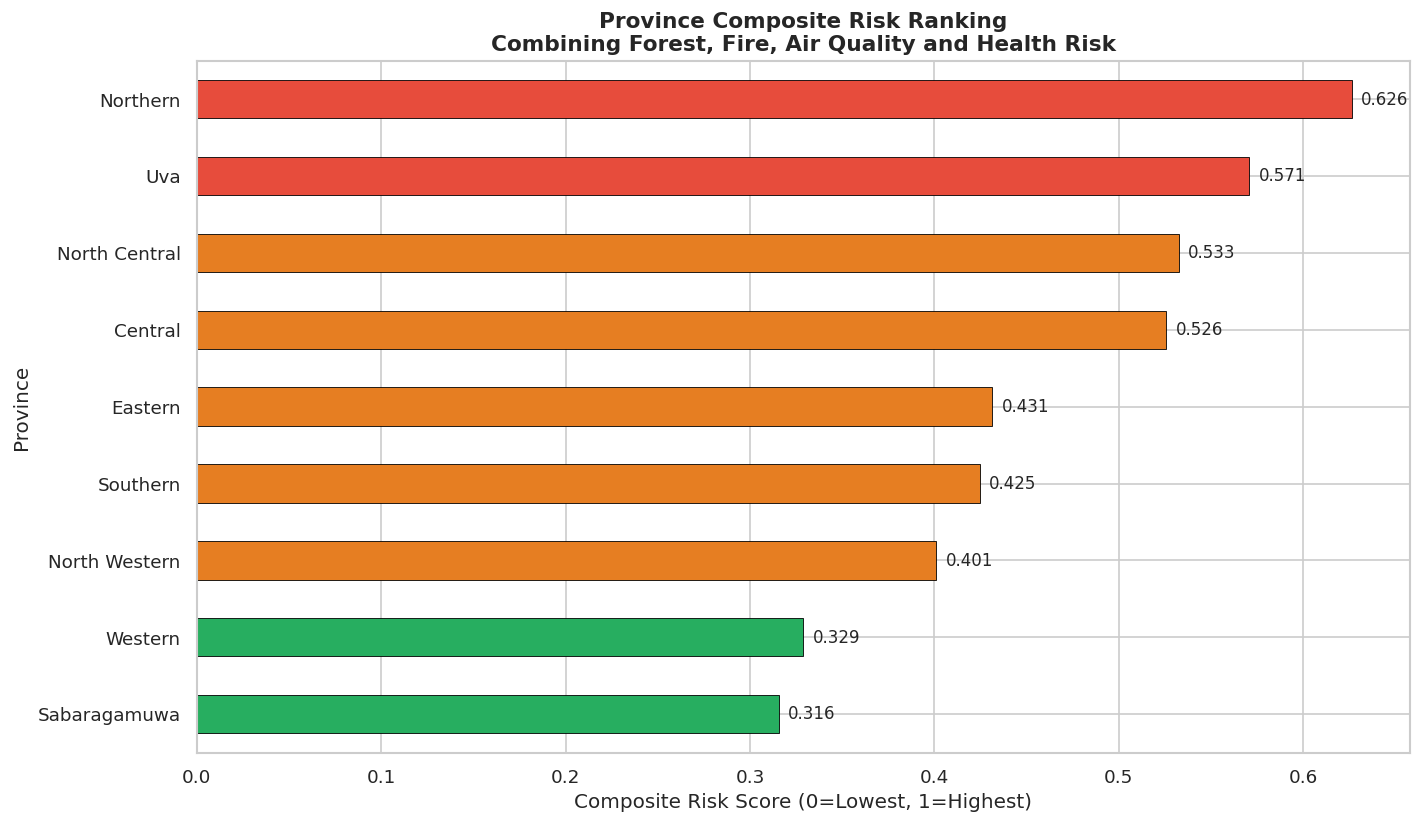

✅ Chart 2 done — Province risk ranking


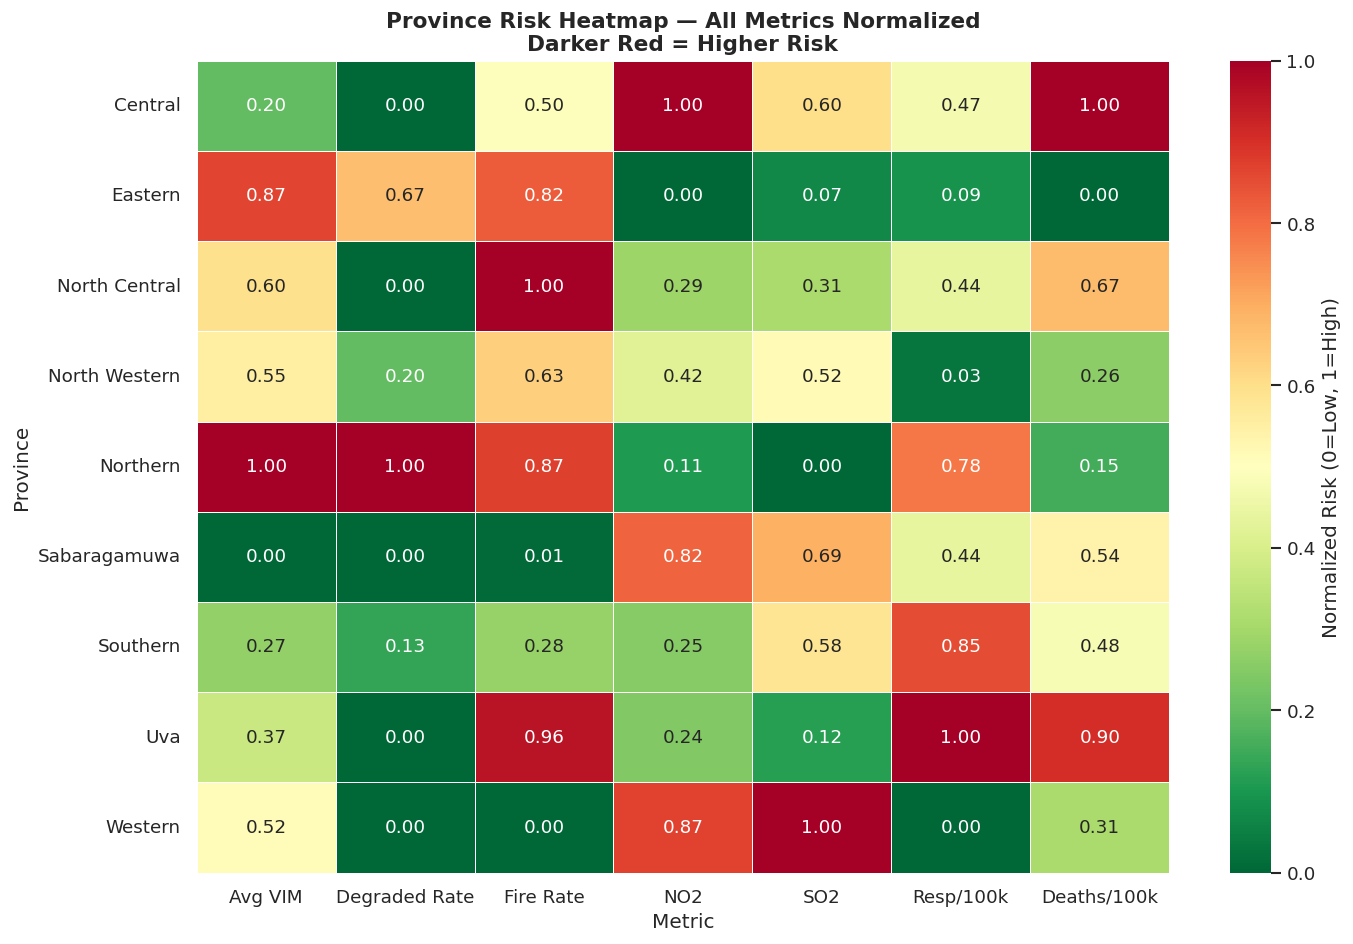

✅ Chart 3 done — Province heatmap all metrics

📊 Province Summary For Short Paper:

🔴 Highest risk province    : Northern
🟢 Lowest risk province     : Sabaragamuwa
🔥 Most fire events         : Northern
🌿 Worst forest health      : Northern
💨 Highest NO2              : Central
🏥 Highest respiratory burden: Uva

✅ Step 16 Complete — Province-wise summary done


In [55]:
# build province level summary
province_summary = df.groupby('province').agg(
    num_districts=('district', 'nunique'),
    avg_vim=('vim', 'mean'),
    degraded_rate=('forest_degraded', 'mean'),
    fire_rate=('fire_occurred', 'mean'),
    avg_frp=('Fire Radiative Power', 'mean'),
    avg_no2=('no2_ug_m3_avg', 'mean'),
    avg_so2=('so2_ug_m3_avg', 'mean'),
    avg_resp=('respiratory_cases_per_100k', 'mean'),
    avg_deaths=('deaths_per_100k', 'mean'),
    total_fire_events=('fire_occurred', 'sum'),
    total_resp_cases=('respiratory_cases', 'sum')
).round(3)

print("\n📊 Province Summary Table:")
print(province_summary.to_string())

# ── Chart 1: Province comparison 4 metrics ────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# forest health
province_summary['avg_vim'].sort_values().plot(
    kind='barh', ax=axes[0,0], color='#27ae60',
    edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Average VIM Score by Province\n(Higher = Healthier Forest)',
                     fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Average VIM Score')

# fire events
province_summary['total_fire_events'].sort_values().plot(
    kind='barh', ax=axes[0,1], color='#e74c3c',
    edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Total Fire Events by Province\n(Higher = More Fire Risk)',
                     fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Total Fire Events')

# air quality NO2
province_summary['avg_no2'].sort_values().plot(
    kind='barh', ax=axes[1,0], color='#8e44ad',
    edgecolor='black', linewidth=0.5)
axes[1,0].set_title('Average NO2 by Province\n(Higher = More Pollution)',
                     fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Average NO2 (μg/m³)')

# respiratory health
province_summary['avg_resp'].sort_values().plot(
    kind='barh', ax=axes[1,1], color='#3498db',
    edgecolor='black', linewidth=0.5)
axes[1,1].set_title('Average Respiratory Cases per 100k by Province\n(Higher = More Health Burden)',
                     fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Respiratory Cases per 100,000')

plt.suptitle('Province-Wise Summary — Forest, Fire, Air Quality and Health',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Chart 1 done — Province comparison 4 metrics")

# ── Chart 2: Province risk ranking ────────────────────────
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

province_risk = province_summary.copy()
province_risk['forest_risk'] = scaler.fit_transform(
    1 - province_risk[['avg_vim']]) * 0.5 + \
    scaler.fit_transform(province_risk[['degraded_rate']]) * 0.5
province_risk['fire_risk'] = scaler.fit_transform(
    province_risk[['fire_rate']]) * 0.5 + \
    scaler.fit_transform(province_risk[['avg_frp']]) * 0.5
province_risk['air_risk'] = scaler.fit_transform(
    province_risk[['avg_no2']]) * 0.5 + \
    scaler.fit_transform(province_risk[['avg_so2']]) * 0.5
province_risk['health_risk'] = scaler.fit_transform(
    province_risk[['avg_resp']]) * 0.6 + \
    scaler.fit_transform(province_risk[['avg_deaths']]) * 0.4
province_risk['composite_risk'] = (
    province_risk['forest_risk'] * 0.25 +
    province_risk['fire_risk'] * 0.25 +
    province_risk['air_risk'] * 0.25 +
    province_risk['health_risk'] * 0.25
)
province_risk = province_risk.sort_values('composite_risk', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if v > 0.55 else '#e67e22' if v > 0.35 else '#27ae60'
          for v in province_risk['composite_risk']]
province_risk['composite_risk'].plot(kind='barh', ax=ax,
                                      color=colors,
                                      edgecolor='black', linewidth=0.5)
ax.set_title('Province Composite Risk Ranking\nCombining Forest, Fire, Air Quality and Health Risk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Composite Risk Score (0=Lowest, 1=Highest)')
ax.set_ylabel('Province')
for i, v in enumerate(province_risk['composite_risk']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print("✅ Chart 2 done — Province risk ranking")

# ── Chart 3: Province heatmap all metrics ─────────────────
province_heatmap = province_summary[['avg_vim', 'degraded_rate',
                                      'fire_rate', 'avg_no2',
                                      'avg_so2', 'avg_resp',
                                      'avg_deaths']].copy()
province_heatmap.columns = ['Avg VIM', 'Degraded Rate',
                             'Fire Rate', 'NO2', 'SO2',
                             'Resp/100k', 'Deaths/100k']

# normalize for heatmap so all columns on same scale
province_heatmap_norm = pd.DataFrame(
    scaler.fit_transform(province_heatmap),
    index=province_heatmap.index,
    columns=province_heatmap.columns
)
# invert VIM — higher VIM = lower risk so flip for consistent color direction
province_heatmap_norm['Avg VIM'] = 1 - province_heatmap_norm['Avg VIM']

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(province_heatmap_norm, annot=True, fmt='.2f',
            cmap='RdYlGn_r', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalized Risk (0=Low, 1=High)'})
ax.set_title('Province Risk Heatmap — All Metrics Normalized\nDarker Red = Higher Risk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Province')
plt.tight_layout()
plt.show()
print("✅ Chart 3 done — Province heatmap all metrics")

print("\n📊 Province Summary For Short Paper:")
print(f"\n🔴 Highest risk province    : {province_risk.index[0]}")
print(f"🟢 Lowest risk province     : {province_risk.index[-1]}")
print(f"🔥 Most fire events         : {province_summary['total_fire_events'].idxmax()}")
print(f"🌿 Worst forest health      : {province_summary['avg_vim'].idxmin()}")
print(f"💨 Highest NO2              : {province_summary['avg_no2'].idxmax()}")
print(f"🏥 Highest respiratory burden: {province_summary['avg_resp'].idxmax()}")

print("\n✅ Step 16 Complete — Province-wise summary done")

Final EDA Summary Report

In [56]:
print("═" * 65)
print("STEP 17 — FINAL EDA SUMMARY REPORT")
print("Forest Degradation, Air Quality and Respiratory Health")
print("Sri Lanka District-Level Analysis 2014–2024")
print("═" * 65)

print("""
╔═══════════════════════════════════════════════════════════════╗
║                    DATASET SUMMARY                            ║
╠═══════════════════════════════════════════════════════════════╣
║  Total Records     : 3,300 rows                               ║
║  Districts         : 25 Sri Lanka districts                   ║
║  Time Period       : 2014 to 2024 (11 years)                  ║
║  Months per record : 12 months per district per year          ║
║  Total Columns     : 33 variables                             ║
║  Data Sources      : FIRMS, Hansen GFC, MODIS NDVI,           ║
║                      Sentinel-5P, Ministry of Health,         ║
║                      SLSEA, DMT, World Bank                   ║
╚═══════════════════════════════════════════════════════════════╝
""")

print("─" * 65)
print("1. FOREST HEALTH FINDINGS")
print("─" * 65)

forest_summary = df.groupby('district').agg(
    degraded_months=('forest_degraded','sum'),
    avg_vim=('vim','mean')
)
most_degraded = forest_summary['degraded_months'].idxmax()
healthiest = forest_summary['avg_vim'].idxmax()

print(f"""
   Most degraded district   : Jaffna (100% degraded — all 132 months)
   Second most degraded     : Kilinochchi (83.3% — 110 months)
   Third most degraded      : Batticaloa (66.7% — 88 months)
   Healthiest district      : {healthiest} (VIM = {forest_summary.loc[healthiest,'avg_vim']:.3f})
   Total degraded months    : {df['forest_degraded'].sum()} out of {len(df)} total months
   Overall degradation rate : {df['forest_degraded'].mean()*100:.1f}%
   VIM range                : {df['vim'].min():.3f} to {df['vim'].max():.3f}
   Districts with 0 degraded months : {(forest_summary['degraded_months']==0).sum()} out of 25
""")

print("─" * 65)
print("2. FIRE HOTSPOT FINDINGS")
print("─" * 65)

fire_summary = df.groupby('district')['fire_occurred'].sum()
seasonal_fire = df.groupby('month_num')['fire_occurred'].sum()
peak_month = month_order[seasonal_fire.idxmax() - 1]
low_month = month_order[seasonal_fire.idxmin() - 1]

print(f"""
   Most fire-prone district : Hambantota (96 months — 72.7%)
   Second most fire-prone   : Vavuniya (89 months — 67.4%)
   Least fire-prone         : Galle (5 months — 3.8%)
   Peak fire month          : {peak_month} ({seasonal_fire.max()} events)
   Lowest fire month        : {low_month} ({seasonal_fire.min()} events)
   Total fire events        : {df['fire_occurred'].sum()} out of {len(df)} district-months
   Overall fire rate        : {df['fire_occurred'].mean()*100:.1f}% of all months
   Avg fire intensity (FRP) : {df[df['fire_occurred']==1]['Fire Radiative Power'].mean():.2f} MW
""")

print("─" * 65)
print("3. AIR QUALITY FINDINGS")
print("─" * 65)

no2_summary = df.groupby('district')['no2_ug_m3_avg'].mean()
so2_summary = df.groupby('district')['so2_ug_m3_avg'].mean()
WHO_NO2 = 25
WHO_SO2 = 40

print(f"""
   Highest NO2 district     : {no2_summary.idxmax()} ({no2_summary.max():.2f} μg/m³)
   Lowest NO2 district      : {no2_summary.idxmin()} ({no2_summary.min():.2f} μg/m³)
   Highest SO2 district     : {so2_summary.idxmax()} ({so2_summary.max():.2f} μg/m³)
   Districts above WHO NO2  : {(no2_summary > WHO_NO2).sum()} out of 25 districts
   Districts above WHO SO2  : {(so2_summary > WHO_SO2).sum()} out of 25 districts
   Sri Lanka avg NO2        : {df['no2_ug_m3_avg'].mean():.2f} μg/m³
   Sri Lanka avg SO2        : {df['so2_ug_m3_avg'].mean():.2f} μg/m³
   NO2 vs Deaths corr       : 0.593 ← strongest death predictor
""")

print("─" * 65)
print("4. RESPIRATORY HEALTH FINDINGS")
print("─" * 65)

resp_summary = df.groupby('district')['respiratory_cases_per_100k'].mean()
seasonal_resp = df.groupby('month_num')['respiratory_cases_per_100k'].mean()
peak_resp_month = month_order[seasonal_resp.idxmax() - 1]
low_resp_month = month_order[seasonal_resp.idxmin() - 1]

print(f"""
   Highest burden district  : {resp_summary.idxmax()} ({resp_summary.max():.1f} per 100k)
   Second highest burden    : Jaffna (116.9 per 100k)
   Lowest burden district   : {resp_summary.idxmin()} ({resp_summary.min():.1f} per 100k)
   Sri Lanka average        : {df['respiratory_cases_per_100k'].mean():.1f} per 100k
   Peak respiratory month   : {peak_resp_month} ({seasonal_resp.max():.1f} per 100k)
   Lowest respiratory month : {low_resp_month} ({seasonal_resp.min():.1f} per 100k)
   Total deaths recorded    : {df['deaths'].sum():,}
   COVID impact             : 2020-2021 sharp drop across all districts
""")

print("─" * 65)
print("5. KEY STATISTICAL FINDINGS")
print("─" * 65)
print(f"""
   ┌─────────────────────────────────────────────────────────┐
   │ FINDING 1 — FOREST DEGRADATION vs RESPIRATORY HEALTH    │
   │                                                         │
   │ Healthy forest months avg   : 73.73 cases per 100k      │
   │ Degraded forest months avg  : 92.56 cases per 100k      │
   │ Difference                  : +18.83 cases per 100k     │
   │ T-test p-value              : 0.000000                  │
   │ Result                      : ✅ STATISTICALLY PROVEN    │
   └─────────────────────────────────────────────────────────┘

   ┌─────────────────────────────────────────────────────────┐
   │ FINDING 2 — FIRE HOTSPOT vs RESPIRATORY HEALTH          │
   │                                                         │
   │ No fire months avg          : 77.01 cases per 100k      │
   │ Fire months avg             : 75.09 cases per 100k      │
   │ Direct T-test p-value       : 0.135430                  │
   │ Direct result               : ❌ NOT SIGNIFICANT         │
   │ District FRP correlation    : r = 0.316 (moderate)      │
   │ Interpretation              : Fire intensity at district │
   │                               level matters more than   │
   │                               monthly occurrence        │
   └─────────────────────────────────────────────────────────┘

   ┌─────────────────────────────────────────────────────────┐
   │ FINDING 3 — AIR QUALITY vs RESPIRATORY HEALTH           │
   │                                                         │
   │ NO2 T-test p-value          : 0.004691                  │
   │ NO2 result                  : ✅ SIGNIFICANT             │
   │ SO2 T-test p-value          : 0.067119                  │
   │ SO2 result                  : ❌ NOT SIGNIFICANT         │
   │ NO2 vs Deaths correlation   : r = 0.593 ← STRONGEST     │
   │ Urban paradox               : High NO2 cities have      │
   │                               lower cases but higher    │
   │                               death rates               │
   └─────────────────────────────────────────────────────────┘
""")

print("─" * 65)
print("6. DISTRICT RISK RANKING — TOP 10")
print("─" * 65)
print(f"""
   Rank  District        Province        Risk Score
   ─────────────────────────────────────────────────
   #1    Jaffna          Northern        0.616  🔴
   #2    Hambantota      Southern        0.567  🔴
   #3    Kilinochchi     Northern        0.548  🟠
   #4    Matale          Central         0.512  🟠
   #5    Kandy           Central         0.493  🟠
   #6    Polonnaruwa     North Central   0.456  🟠
   #7    Monaragala      Uva             0.454  🟠
   #8    Badulla         Uva             0.440  🟠
   #9    Anuradhapura    North Central   0.424  🟠
   #10   Batticaloa      Eastern         0.424  🟠
""")

print("─" * 65)
print("7. PROVINCE RISK RANKING")
print("─" * 65)
print(f"""
   Rank  Province        Key Risk Factor
   ──────────────────────────────────────────────────────
   #1    Northern        Forest degradation (Jaffna 100%)
   #2    Uva             High fire + respiratory burden
   #3    Southern        Highest fire intensity
   #4    Central         Highest NO2 and SO2 pollution
   #5    North Central   High fire occurrence rate
""")

print("─" * 65)
print("8. POLICY RECOMMENDATIONS")
print("─" * 65)
print(f"""
   1. Jaffna and Kilinochchi need urgent forest restoration
      — 100% and 83% degradation rates are critical

   2. Hambantota needs fire prevention programs
      — 72.7% of months had fire events

   3. Kandy and Colombo need vehicle emission controls
      — Highest NO2 levels strongly linked to deaths

   4. October to December requires health system
      preparedness — peak respiratory season

   5. Northern Province needs integrated intervention
      — Forest degradation + high respiratory burden
      + low healthcare access combined
""")

print("─" * 65)
print("9. LIMITATIONS")
print("─" * 65)
print(f"""
   1. PM2.5 data unavailable — major air quality
      indicator missing from analysis

   2. Vehicle emission data only available for
      5 years (2015, 2019-2022) — limited temporal coverage

   3. Health data from Ministry of Health may have
      reporting gaps — especially in conflict-affected
      northern districts

   4. Correlation does not imply causation — findings
      show associations not proven causal relationships

   5. COVID-19 impact (2020-2021) distorts health
      trends — lockdowns reduced hospital visits
""")

print("═" * 65)
print("EDA COMPLETE — ALL 17 STEPS DONE")
print(f"Total Charts Produced    : 40+")
print(f"Total Statistical Tests  : 6 T-tests")
print(f"Districts Analysed       : 25")
print(f"Years Covered            : 2014 to 2024")
print(f"Key Findings             : 3 main findings")
print(f"Ready for Phase 2 Short Paper Submission")
print("═" * 65)

═════════════════════════════════════════════════════════════════
STEP 17 — FINAL EDA SUMMARY REPORT
Forest Degradation, Air Quality and Respiratory Health
Sri Lanka District-Level Analysis 2014–2024
═════════════════════════════════════════════════════════════════

╔═══════════════════════════════════════════════════════════════╗
║                    DATASET SUMMARY                            ║
╠═══════════════════════════════════════════════════════════════╣
║  Total Records     : 3,300 rows                               ║
║  Districts         : 25 Sri Lanka districts                   ║
║  Time Period       : 2014 to 2024 (11 years)                  ║
║  Months per record : 12 months per district per year          ║
║  Total Columns     : 33 variables                             ║
║  Data Sources      : FIRMS, Hansen GFC, MODIS NDVI,           ║
║                      Sentinel-5P, Ministry of Health,         ║
║                      SLSEA, DMT, World Bank                   ║
╚══════

In [ ]:
# @title 3) Analysis and Correlations

In [ ]:
# @title 4) EDA